# Scientific Workflow for Extracting Viscosity from Rotational Drag vs Gap Height Data

**Purpose** — Rigorous, publication-quality rheological analysis of rotational drag
($T/\Omega$) as a function of cone–plate / parallel-gap separation $h$.

**Theoretical context.** For a Newtonian fluid in a narrow gap, the resisting torque on a
rotating disk scales approximately as

$$\frac{T}{\Omega} \;=\; \frac{A}{h} + B,$$

with $A \propto \mu R^4$ (viscosity $\mu$, plate radius $R$) and $B$ a baseline / parasitic
drag term. Real measurements deviate from this pure $1/h$ law due to:

- finite-size / edge effects,
- slip, wall roughness, compliance, steric layers,
- gap-zero uncertainty (the absolute contact point is not exactly known),
- shear-thinning / yield-stress / viscoelastic behaviour.

This notebook implements a full modular pipeline:

1. data import & preprocessing
2. log–log scaling diagnosis
3. candidate physical models (hyperbolic, regularized, generalized power, saturation)
4. direct physical-space nonlinear fits
5. robust / weighted / orthogonal-distance fits
6. residual diagnostics
7. model comparison (AIC, BIC, CV)
8. low-gap sensitivity (point-removal stability)
9. uncertainty quantification (bootstrap, optional MCMC)
10. final scientific interpretation
11. publication-quality figures
12. optional advanced regime analysis

All steps are wrapped in reusable helper functions and produce exportable
CSV / SVG / PNG artefacts.


## Figure Index

All figures are **6 × 6 inches**, one plot per figure (no subplots). Use these labels to refer to specific plots:

| Label | Description | Code cell / section |
|-------|-------------|---------------------|
| **Plot 1** | Raw T/Ω vs h — all samples | §1 data import |
| **Plot 2** | Raw T/Ω vs h — focus sample | §1 data import |
| **Plot 3** | Log–log scaling on linear axes | §2 `plot_loglog_analysis` |
| **Plot 4** | Local scaling exponent vs h | §2 `plot_loglog_analysis` |
| **Plot 5** | Scaling exponent vs baseline offset B | §2 B-scan |
| **Plot 6** | Direct physical-space fits — all models | §4 direct fitting |
| **Plot 7** | Robust / weighted fits comparison | §5 robust fitting |
| **Plots 8–11** | Residual diagnostics: (8) vs h · (9) histogram · (10) QQ · (11) ACF | §6 residuals |
| **Plots 12–15** | Sensitivity of A per model (one per model) | §8 sensitivity |
| **Plots 16–18** | Sensitivity of h0 / n (regularized & gen_power) | §8 sensitivity |
| **Plots 19+** | Bootstrap parameter histograms (one per parameter) | §9 bootstrap |
| **Plot (19+k)** | Bootstrap prediction band | §9 bootstrap |
| **Plot A** | Publication — data + best fit with 95% CI | §11 publication |
| **Plot B** | Publication — residuals | §11 publication |
| **Plot C** | Spline reference vs physical model | §12 advanced |
| **Plot D** | Regime map (local scaling exponent) | §12 advanced |
| **Plot E** | Fitted A vs nominal viscosity | §12 calibration curve |
| **Plot F** | h0 vs nominal viscosity | §12 gap-zero offset |
| **Plots G1, G2, ...** | Normalized drag per sample (one per sample) | normalized drag section |
| **Plot H1** | Overlay of all normalized master curves | §13 master curve |
| **Plot H2** | Mean master curve with 95% CI band | §13 master curve |
| **Plot H3** | Universal master curve with all global model fits | §13 publication |
| **Plot H4** | Residuals of global master-curve fits | §13 publication |
| **Plot H5** | Geometric length scale h_c across viscosities | §13 h_c analysis |
| **Plot H6** | Master residuals vs h | §13 residual diagnostics |
| **Plot H7** | Master residuals vs fitted | §13 residual diagnostics |
| **Plot H8** | Master residuals histogram | §13 residual diagnostics |
| **Plot H9** | Master residuals QQ plot | §13 residual diagnostics |
| **Plots I1, I2, ...** | D(h) per RPM — one per polymer fluid | §14.5a |
| **Plot J** | Amplitude flow curve A(γ̇) | §14.5b |
| **Plot K** | Calibrated flow curves η_app(γ̇) | §14.5c |
| **Plot L** | Parity μ_app vs μ_true | §14.5d |
| **Plot M** | Master rheogram — shear stress vs shear rate | §14.8 |


## 0. Environment & global configuration

Imports, plot style, output directories.

In [1]:
from __future__ import annotations

import os
import json
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import ListedColormap, to_rgba
from cycler import cycler
from scipy import optimize, stats, odr
from sklearn.model_selection import KFold
import statsmodels.api as sm

try:
    import lmfit  # optional but preferred for richer fits
    HAS_LMFIT = True
except Exception:
    HAS_LMFIT = False

try:
    import emcee  # optional Bayesian
    HAS_EMCEE = True
except Exception:
    HAS_EMCEE = False

warnings.filterwarnings("ignore", category=RuntimeWarning)

GOOGLE_COLORS = ["#4285F4", "#DB4437", "#F4B400", "#0F9D58"]
FIG_SIZE_STD = (10.0, 6.0)

# Publication-quality plot defaults
rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": None,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.6,
    "figure.figsize": FIG_SIZE_STD,
    "axes.prop_cycle": cycler(color=GOOGLE_COLORS),
})

PALETTE = ListedColormap(GOOGLE_COLORS, name="google_palette")

FIG_DIR = Path("figures_rheology"); FIG_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("outputs_rheology"); OUT_DIR.mkdir(exist_ok=True)


def _apply_google_palette(fig):
    """Force data-bearing artists to Google colors while leaving text/axes styling intact."""
    color_idx = 0

    def next_color():
        nonlocal color_idx
        c = GOOGLE_COLORS[color_idx % len(GOOGLE_COLORS)]
        color_idx += 1
        return c

    for ax in fig.axes:
        for line in ax.lines:
            # Keep explicitly labeled 1/h reference lines in yellow.
            label = str(line.get_label()).lower()
            if "ideal 1/h slope" in label:
                line.set_color(GOOGLE_COLORS[2])
                continue
            line.set_color(next_color())

        for coll in ax.collections:
            if hasattr(coll, "get_offsets"):
                c = to_rgba(next_color())
                try:
                    coll.set_facecolor(c)
                    coll.set_edgecolor(c)
                except Exception:
                    pass

        for patch in ax.patches:
            c = to_rgba(next_color())
            try:
                patch.set_facecolor(c)
                patch.set_edgecolor("#3C4043")
            except Exception:
                pass


def save_fig(fig, name: str):
    fig.set_size_inches(*FIG_SIZE_STD, forward=True)
    _apply_google_palette(fig)
    for ext in ("png", "svg"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches=None)
    return fig

print(f"lmfit available : {HAS_LMFIT}")
print(f"emcee available : {HAS_EMCEE}")
print(f"Figures dir     : {FIG_DIR.resolve()}")
print(f"Outputs dir     : {OUT_DIR.resolve()}")
print(f"Google palette  : {GOOGLE_COLORS}")
print(f"Figure size     : {FIG_SIZE_STD}")

lmfit available : False
emcee available : False
Figures dir     : C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\results\Auto-runs\figures_rheology
Outputs dir     : C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\results\Auto-runs\outputs_rheology
Google palette  : ['#4285F4', '#DB4437', '#F4B400', '#0F9D58']
Figure size     : (10.0, 6.0)


In [2]:
# Exported figure size: 6 × 6 inches per panel (all figures are single-panel).
FIG_SUBPLOT_SIZE = (6.0, 6.0)  # width, height (inches) — applies to both display and export

# Figure exports that should be stripped of titles.
FIG6_TITLELESS_EXPORTS = {
    "02_loglog_focus_logspace",
    "02_loglog_focus_local_slope",
    "02b_slope_vs_B",
    "04_direct_fits",
    "13_master_overlay",
    "13_master_mean",
}


def _infer_subplot_grid(fig):
    nrows = 1
    ncols = 1
    usable_axes = [ax for ax in fig.axes if ax.get_visible()]

    for ax in usable_axes:
        try:
            spec = ax.get_subplotspec()
        except Exception:
            continue
        nrows = max(nrows, spec.rowspan.stop)
        ncols = max(ncols, spec.colspan.stop)

    return nrows, ncols


def _strip_titles(fig):
    for ax in fig.axes:
        ax.set_title("")
    if getattr(fig, "_suptitle", None) is not None:
        fig._suptitle.set_text("")


def save_fig(fig, name: str):
    nrows, ncols = _infer_subplot_grid(fig)
    fig.set_size_inches(FIG_SUBPLOT_SIZE[0] * ncols, FIG_SUBPLOT_SIZE[1] * nrows, forward=True)

    if name in FIG6_TITLELESS_EXPORTS:
        _strip_titles(fig)

    _apply_google_palette(fig)
    for ext in ("png", "svg"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches=None)
    return fig


print(f"Export size per panel: {FIG_SUBPLOT_SIZE[0]:.2f} x {FIG_SUBPLOT_SIZE[1]:.2f} in  (all figures are single-panel → 6 x 6)")
print(f"Titleless exports: {sorted(FIG6_TITLELESS_EXPORTS)}")


Export size per panel: 6.00 x 6.00 in  (all figures are single-panel → 6 x 6)
Titleless exports: ['02_loglog_focus_local_slope', '02_loglog_focus_logspace', '02b_slope_vs_B', '04_direct_fits', '13_master_mean', '13_master_overlay']


## USER INPUT SECTION

Define the dataset path, units, and the columns that map to the canonical variables
`h` (gap height) and `T_over_RPM` (= $T/\Omega$).

The provided dataset `height_normalized.csv` is in **wide form**: one `Height` column plus
many viscosity-sample columns named like `12.5kcp_14.576_torque_%_rpm_3.5`. Each sample
column holds the torque-per-RPM (in %/RPM units) at the corresponding gap height.

We therefore reshape it into a tidy long form with one row per `(sample, h)` pair.
You may also point `DATA_PATH` to your own CSV and override `H_COL` / `Y_COL` / `RPM_COL`
if your file already has columns in canonical form.


In [3]:
# ---- USER-CONFIGURABLE BLOCK -----------------------------------------------
DATA_PATH = Path("height_normalized.csv")     # <- change to your file

# Canonical columns (used when the file is already tidy):
H_COL   = "h_mm"          # gap height
Y_COL   = "T_over_RPM"    # torque / RPM
RPM_COL = "RPM"           # optional
T_COL   = "Torque"        # optional

# Units
H_UNIT = "mm"                  # 'mm' or 'um'
Y_UNIT = "% / RPM"             # arbitrary string; for axis labels only

# If True we reshape the wide `height_normalized.csv` into long form.
WIDE_FORMAT = True

# Which sample(s) to analyze in detail. Use None to analyse ALL samples in a loop
# at the end, or a string like '12.5kcp' to analyse a specific viscosity grade.
# FOCUS_SAMPLE = "12.5kcp"
FOCUS_SAMPLE = "90kcp"
# ----------------------------------------------------------------------------


## 1. Data import and preprocessing

**Why this matters.** $T/\Omega$ vs $h$ encodes the viscosity through the slope of the
hyperbolic divergence as $h\to 0$. Small-gap data points are simultaneously the most
informative and the most error-prone: a 10 µm uncertainty on a 50 µm gap produces a
20 % uncertainty on $1/h$. We therefore:

- import the CSV defensively,
- standardize units to mm,
- drop NaN / non-positive heights,
- sort by `h`,
- optionally average replicate heights.

Helper functions: `validate_columns`, `load_data`, `preprocess_data`, `wide_to_long`.


In [4]:
def validate_columns(df: pd.DataFrame, required: Sequence[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}. Available: {list(df.columns)}")

def wide_to_long(df: pd.DataFrame, h_col: str = "Height") -> pd.DataFrame:
    """Reshape the project-specific wide CSV to tidy long form.

    Column names like '12.5kcp_14.576_torque_%_rpm_3.5' are parsed into
    sample label, nominal torque %, and RPM.
    """
    validate_columns(df, [h_col])
    long_rows = []
    for col in df.columns:
        if col == h_col:
            continue
        # Parse: '<label>kcp_<torque%>_torque_%_rpm_<rpm>'
        parts = col.split("_")
        try:
            label = parts[0]                          # '12.5kcp'
            torque_pct = float(parts[1])              # nominal torque %
            rpm = float(parts[-1])                    # rpm at hit-point
        except Exception:
            label, torque_pct, rpm = col, np.nan, np.nan
        sub = pd.DataFrame({
            "sample": label,
            "h_mm": df[h_col].values,
            "T_over_RPM": df[col].values,
            "RPM_nominal": rpm,
            "Torque_pct_hit": torque_pct,
        })
        long_rows.append(sub)
    return pd.concat(long_rows, ignore_index=True)

def load_data(path: Path | str, wide: bool = WIDE_FORMAT) -> pd.DataFrame:
    df = pd.read_csv(path)
    if wide:
        df = wide_to_long(df, h_col=df.columns[0])
    return df

def preprocess_data(df: pd.DataFrame,
                    h_col: str = "h_mm",
                    y_col: str = "T_over_RPM",
                    h_unit: str = "mm",
                    drop_zero_h: bool = False) -> pd.DataFrame:
    """Standardize units (→ mm), clean NaN / non-finite, sort, deduplicate."""
    validate_columns(df, [h_col, y_col])
    df = df.copy()
    if h_unit == "um":
        df[h_col] = df[h_col] / 1000.0
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[h_col, y_col])
    if drop_zero_h:
        df = df[df[h_col] > 0]
    else:
        # avoid log(0) downstream by clipping a tiny epsilon for log analyses only
        df = df[df[h_col] >= 0]
    df = df.sort_values(h_col).reset_index(drop=True)
    return df

# --- Run import ----------------------------------------------------------
raw = load_data(DATA_PATH, wide=WIDE_FORMAT)
print(f"Loaded {len(raw):,} rows, samples = {raw['sample'].nunique()}")
display(raw.head())

# Tidy + units
tidy = preprocess_data(raw, h_col="h_mm", y_col="T_over_RPM", h_unit=H_UNIT, drop_zero_h=True)
print(f"After preprocessing: {len(tidy):,} rows across {tidy['sample'].nunique()} samples")


Loaded 713 rows, samples = 23


,sample,h_mm,T_over_RPM,RPM_nominal,Torque_pct_hit
0,1kcp,0.00,1.535177,47.0,1.073
1,1kcp,0.02,1.393901,47.0,1.073
2,1kcp,0.04,1.318369,47.0,1.073
3,1kcp,0.06,1.256525,47.0,1.073
4,1kcp,0.08,1.196525,47.0,1.073


After preprocessing: 425 rows across 23 samples


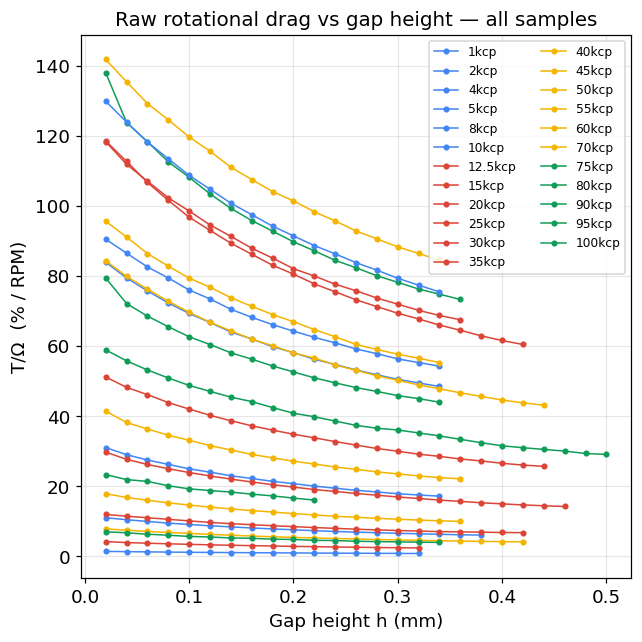

Focus sample = 90kcp (17 points)


,sample,h_mm,T_over_RPM,RPM_nominal,Torque_pct_hit
0,90kcp,0.02,129.853333,0.5,102.466
1,90kcp,0.04,123.913333,0.5,102.466
2,90kcp,0.06,118.226667,0.5,102.466
3,90kcp,0.08,113.440000,0.5,102.466
4,90kcp,0.10,108.706667,0.5,102.466


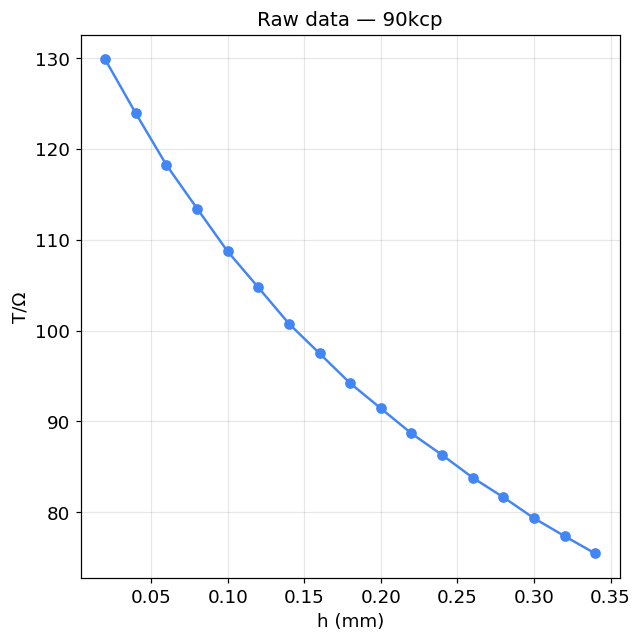

In [5]:
# --- Plot 1: Raw rotational drag vs gap height — all samples ---
fig, ax = plt.subplots(figsize=(6, 6))
samples = sorted(tidy["sample"].unique(), key=lambda s: float(s.replace("kcp", "")))
colors = PALETTE(np.linspace(0, 0.95, len(samples)))
for c, s in zip(colors, samples):
    sub = tidy[tidy["sample"] == s]
    ax.plot(sub["h_mm"], sub["T_over_RPM"], "o-", ms=3, lw=1, color=c, label=s)
ax.set_xlabel("Gap height h (mm)")
ax.set_ylabel(f"T/Ω  ({Y_UNIT})")
ax.set_title("Raw rotational drag vs gap height — all samples")
ax.legend(ncol=2, fontsize=8, loc="upper right")
plt.tight_layout()
save_fig(fig, "01_raw_all_samples"); plt.show()

# Focused sample
focus = tidy[tidy["sample"] == FOCUS_SAMPLE].reset_index(drop=True)
print(f"Focus sample = {FOCUS_SAMPLE} ({len(focus)} points)")
display(focus.head())

# --- Plot 2: Raw data — focus sample ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(focus["h_mm"], focus["T_over_RPM"], "o-", color="C0")
ax.set_xlabel("h (mm)"); ax.set_ylabel("T/Ω")
ax.set_title(f"Raw data — {FOCUS_SAMPLE}")
plt.tight_layout()
save_fig(fig, "01_raw_focus"); plt.show()


## 2. Initial scaling diagnosis (log–log analysis)

If $T/\Omega \sim h^{-n}$ then $\log(T/\Omega) = -n\log h + \text{const}$.
A global log–log linear fit gives one exponent $n$; a **local** moving-window slope or
numerical derivative reveals whether the apparent exponent **changes** with $h$ — a
hallmark of regularization (finite $h_0$), slip layers, or shear-thinning crossover.

Helpers: `fit_loglog_scaling`, `compute_local_slope`, `plot_loglog_analysis`.


C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3532970312.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x_labels, fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3532970312.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(y_labels, fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3532970312.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([f"{x:.1f}" for x in ax2.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3532970312.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f"{y:.1f}" for y in ax2.get_

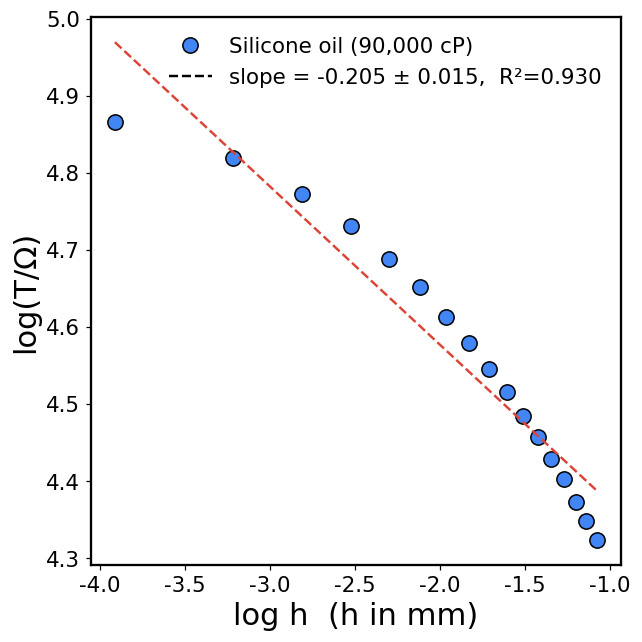

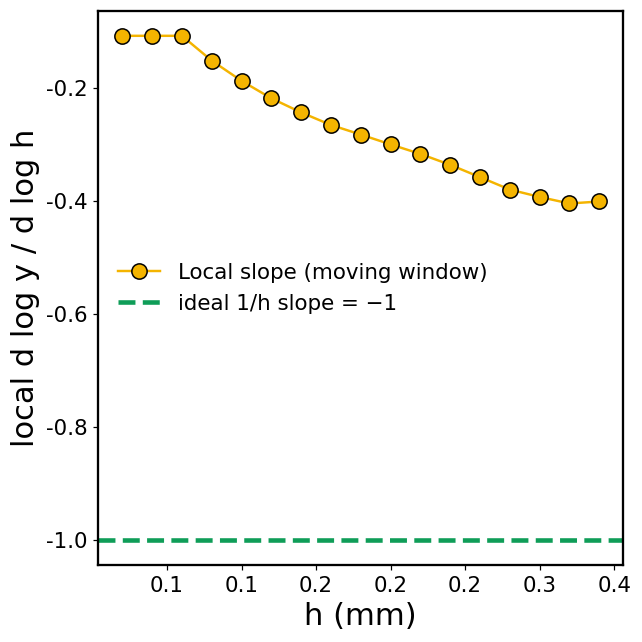

Global scaling exponent  : -0.2053  (95% CI -0.234, -0.177)
R²                       : 0.9299
→ |slope| < 1: divergence is *weaker* than pure 1/h ⇒ likely regularization (finite h0) or slip.


In [6]:
def fit_loglog_scaling(h, y):
    """Linear regression on log(y) = a*log(h) + b. Returns slope, intercept, stderr, R²."""
    h = np.asarray(h, float); y = np.asarray(y, float)
    m = (h > 0) & (y > 0)
    x, z = np.log(h[m]), np.log(y[m])
    res = stats.linregress(x, z)
    return {
        "slope": res.slope, "intercept": res.intercept,
        "stderr_slope": res.stderr, "r2": res.rvalue ** 2,
        "ci95_slope": (res.slope - 1.96 * res.stderr, res.slope + 1.96 * res.stderr),
    }

def compute_local_slope(h, y, window: int = 5):
    """Moving-window OLS slope in log–log space. Window in number of points."""
    h = np.asarray(h, float); y = np.asarray(y, float)
    m = (h > 0) & (y > 0)
    h, y = h[m], y[m]
    n = len(h)
    slopes = np.full(n, np.nan)
    for i in range(n):
        lo = max(0, i - window // 2); hi = min(n, lo + window)
        if hi - lo < 3: continue
        s = stats.linregress(np.log(h[lo:hi]), np.log(y[lo:hi])).slope
        slopes[i] = s
    return h, slopes

def plot_loglog_analysis(h, y, label="data"):
    res = fit_loglog_scaling(h, y)
    h_l, slopes = compute_local_slope(h, y, window=5)

    # Mask positive values for log transform
    h_arr = np.asarray(h, float); y_arr = np.asarray(y, float)
    m = (h_arr > 0) & (y_arr > 0)
    log_h = np.log(h_arr[m]); log_y = np.log(y_arr[m])

    # --- Plot 3: Log–log scaling (linear axes) ---
    fig1, ax1 = plt.subplots(figsize=(6, 6))
    ax1.plot(log_h, log_y, "o", markersize=10, markeredgecolor='k', label='Silicone oil (90,000 cP)')
    xx = np.linspace(log_h.min(), log_h.max(), 100)
    yy = res["intercept"] + res["slope"] * xx
    ax1.plot(xx, yy, "--", color="k",
             label=f"slope = {res['slope']:.3f} ± {res['stderr_slope']:.3f},  R²={res['r2']:.3f}")
    ax1.set_xlabel("log h  (h in mm)", fontsize=20); ax1.set_ylabel("log(T/Ω)", fontsize=20)
    # Create 1-decimal string labels
    x_ticks = ax1.get_xticks()
    y_ticks = ax1.get_yticks()
    x_labels = [f"{x:.1f}" for x in x_ticks]
    y_labels = [f"{y:.1f}" for y in y_ticks]

    # Set the labels and font sizes
    ax1.set_xticklabels(x_labels, fontsize=14)
    ax1.set_yticklabels(y_labels, fontsize=14)
    ax1.legend(fontsize=14, frameon=False, loc="upper right")
    ax1.grid(False)
    # Choose your desired border thickness
    border_thickness = 1.5

    # Loop through all 4 borders (top, bottom, left, right) and increase width
    for spine in ax1.spines.values():
        spine.set_linewidth(border_thickness)
    plt.tight_layout()

    # --- Plot 4: Local scaling exponent ---
    fig2, ax2 = plt.subplots(figsize=(6, 6))
    ax2.plot(h_l, slopes, "o-", color=GOOGLE_COLORS[2], markersize=10, markeredgecolor='k', label='Local slope (moving window)')
    ax2.axhline(-1, color=GOOGLE_COLORS[3], ls="--", linewidth=3, label="ideal 1/h slope = −1")
    ax2.set_xlabel("h (mm)", fontsize=20); ax2.set_ylabel("local d log y / d log h", fontsize=20)
    ax2.set_xticklabels([f"{x:.1f}" for x in ax2.get_xticks()], fontsize=14)
    ax2.set_yticklabels([f"{y:.1f}" for y in ax2.get_yticks()], fontsize=14)
    ax2.legend(fontsize=14, frameon=False, loc="center left")
    ax2.grid(False)
    for spine in ax2.spines.values():
        spine.set_linewidth(border_thickness)
    plt.tight_layout()

    return fig1, fig2, res

fig1, fig2, ll = plot_loglog_analysis(focus["h_mm"].values, focus["T_over_RPM"].values, label=FOCUS_SAMPLE)
save_fig(fig1, "02_loglog_focus_logspace"); plt.show()
save_fig(fig2, "02_loglog_focus_local_slope"); plt.show()

print(f"Global scaling exponent  : {ll['slope']:.4f}  (95% CI {ll['ci95_slope'][0]:.3f}, {ll['ci95_slope'][1]:.3f})")
print(f"R²                       : {ll['r2']:.4f}")
if ll["slope"] > -0.7:
    print("→ |slope| < 1: divergence is *weaker* than pure 1/h ⇒ likely regularization (finite h0) or slip.")
elif ll["slope"] < -1.3:
    print("→ |slope| > 1: divergence stronger than 1/h ⇒ possible squeeze-film / lubrication regime.")
else:
    print("→ slope ≈ −1: behaviour consistent with classical 1/h hyperbolic drag.")


C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\4020119280.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.0f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\4020119280.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.1f}" for y in ax.get_yticks()], fontsize=14)


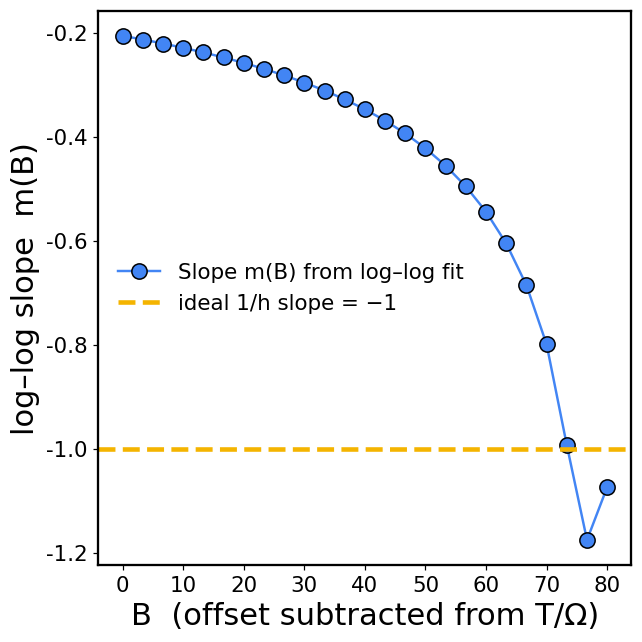

,B,slope,n_points
0,0.000000,-0.205336,17
1,3.333333,-0.212480,17
2,6.666667,-0.220150,17
3,10.000000,-0.228406,17
4,13.333333,-0.237320,17
5,16.666667,-0.246976,17
6,20.000000,-0.257474,17
7,23.333333,-0.268931,17
8,26.666667,-0.281491,17
9,30.000000,-0.295325,17


B giving slope closest to −1 : B = 73.333  (slope = -0.993)


In [7]:
# Scan offset B: subtract a constant baseline from T/RPM and refit the log-log slope.
# For each B in B_values:
#   y = T/RPM - B
#   keep only points where y > 0
#   fit log(y) = m * log(h) + c  →  store slope m(B)
# Then plot m(B) vs B.

h_vals = focus["h_mm"].values
T_over_RPM = focus["T_over_RPM"].values

B_values = np.linspace(0, 80, 25)
slopes_B = np.full(B_values.size, np.nan)
n_pts_B = np.zeros(B_values.size, dtype=int)

for i, B in enumerate(B_values):
    y = T_over_RPM - B
    mask = (y > 0) & (h_vals > 0)
    n_pts_B[i] = int(mask.sum())
    if mask.sum() < 3:
        continue
    res = stats.linregress(np.log(h_vals[mask]), np.log(y[mask]))
    slopes_B[i] = res.slope

# --- Plot 5: Scaling exponent vs baseline offset B ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(B_values, slopes_B, "o-", color=GOOGLE_COLORS[0], markersize=10, markeredgecolor='k', label='Slope m(B) from log–log fit')
ax.axhline(-1, color=GOOGLE_COLORS[2], ls="--", linewidth=3, label="ideal 1/h slope = −1")
ax.set_xlabel("B  (offset subtracted from T/Ω)", fontsize=20)
ax.set_ylabel("log–log slope  m(B)", fontsize=20)
ax.legend(fontsize=14, frameon=False, loc="center left")
ax.set_xticklabels([f"{x:.0f}" for x in ax.get_xticks()], fontsize=14)
ax.set_yticklabels([f"{y:.1f}" for y in ax.get_yticks()], fontsize=14)
ax.grid(False)
border_thickness = 1.5
for spine in ax.spines.values():
    spine.set_linewidth(border_thickness)
plt.tight_layout()
save_fig(fig, "02b_slope_vs_B"); plt.show()

sweep_B = pd.DataFrame({"B": B_values, "slope": slopes_B, "n_points": n_pts_B})
display(sweep_B)

# Find B that yields slope closest to −1
valid = np.isfinite(slopes_B)
if valid.any():
    idx = np.argmin(np.abs(slopes_B[valid] - (-1.0)))
    B_best = B_values[valid][idx]
    print(f"B giving slope closest to −1 : B = {B_best:.3f}  (slope = {slopes_B[valid][idx]:.3f})")


## 3. Physical model definitions

We compare four candidate models with progressively richer structure:

| Model | Form | Parameters | Comment |
|---|---|---|---|
| **Hyperbolic** | $A/h + B$ | $A, B$ | classical Newtonian limit |
| **Regularized hyperbola** | $A/(h+h_0) + B$ | $A, h_0, B$ | $h_0$ absorbs zero-gap offset / slip layer |
| **Generalized power** | $A/(h+h_0)^n + B$ | $A, h_0, n, B$ | flexible exponent — captures squeeze-film or sub-hyperbolic regimes |
| **Saturation** | $A\,(1 - e^{-h_c/h}) + B$ | $A, h_c, B$ | bounded near $h\to 0$ |

Physical meaning:
- $A$ ∝ effective viscosity × geometry factor.
- $h_0$ ≈ effective contact offset (slip length + asperity height + gap-zero error).
- $n$ deviation from 1 indicates non-classical lubrication or shear-thinning.
- $B$ baseline / parasitic drag (bearings, air).


In [8]:
def hyperbolic_model(h, A, B):
    return A / np.asarray(h) + B

def regularized_model(h, A, h0, B):
    return A / (np.asarray(h) + h0) + B

def generalized_powerlaw_model(h, A, h0, n, B):
    return A / (np.asarray(h) + h0) ** n + B

def saturation_model(h, A, hc, B):
    h = np.asarray(h, float)
    with np.errstate(divide="ignore"):
        return A * (1.0 - np.exp(-hc / np.where(h > 0, h, np.nan))) + B

MODELS: Dict[str, dict] = {
    "hyperbolic":   dict(func=hyperbolic_model,
                         p0=lambda h, y: [y.max() * h.min(), y.min()],
                         bounds=([0, -np.inf], [np.inf, np.inf]),
                         pnames=["A", "B"]),
    "regularized":  dict(func=regularized_model,
                         p0=lambda h, y: [y.max() * h.min(), 0.01, y.min()],
                         bounds=([0, 0, -np.inf], [np.inf, h.max() if False else np.inf, np.inf]),
                         pnames=["A", "h0", "B"]),
    "gen_power":    dict(func=generalized_powerlaw_model,
                         p0=lambda h, y: [y.max() * h.min(), 0.01, 1.0, y.min()],
                         bounds=([0, 0, 0.2, -np.inf], [np.inf, np.inf, 3.0, np.inf]),
                         pnames=["A", "h0", "n", "B"]),
    "saturation":   dict(func=saturation_model,
                         p0=lambda h, y: [y.max(), 0.05, y.min()],
                         bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]),
                         pnames=["A", "hc", "B"]),
}
print("Defined models:", list(MODELS))


Defined models: ['hyperbolic', 'regularized', 'gen_power', 'saturation']


## 4. Direct physical-space fitting

Fitting in the **original** $(h, T/\Omega)$ space — not in log or reciprocal space —
preserves the Gaussian error structure of the measurement and avoids transforming
heteroscedastic noise into a biased estimator. We use `scipy.optimize.curve_fit`
(Levenberg–Marquardt with bounds) with sensible initial guesses and bounds.

Helpers: `fit_model`, `predict_model`, `summarize_fit`.


C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\592146226.py:65: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax.plot(h_f, y_f, "ko", label="data", ms=10, color=GOOGLE_COLORS[0], markeredgecolor='k')
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\592146226.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\592146226.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)


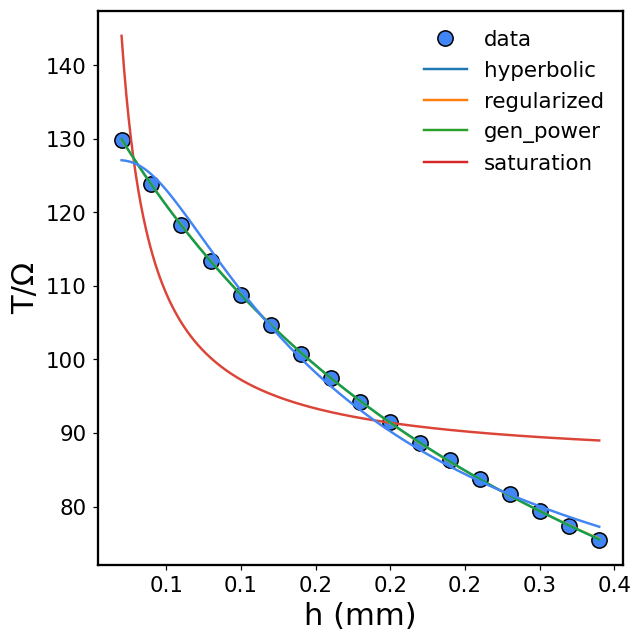


>>> hyperbolic  (success=True)


,param,value,stderr,ci95_lo,ci95_hi
0,A,1.169399,0.210360,0.757094,1.581704
1,B,85.539382,3.214451,79.239058,91.839707



>>> regularized  (success=True)


,param,value,stderr,ci95_lo,ci95_hi
0,A,40.611458,0.897545,38.852270,42.370645
1,h0,0.334767,0.005209,0.324556,0.344977
2,B,15.417202,0.922711,13.608688,17.225716



>>> gen_power  (success=True)


,param,value,stderr,ci95_lo,ci95_hi
0,A,62.551870,24.192436,15.134695,109.969045
1,h0,0.242071,0.057272,0.129817,0.354325
2,n,0.609053,0.242439,0.133872,1.084233
3,B,-11.438048,27.470991,-65.281189,42.405094



>>> saturation  (success=True)


,param,value,stderr,ci95_lo,ci95_hi
0,A,76.714160,2.067587,72.661690,80.766630
1,hc,0.146269,0.008635,0.129344,0.163194
2,B,50.428023,2.349879,45.822261,55.033785


In [9]:
@dataclass
class FitResult:
    name: str
    popt: np.ndarray
    pcov: np.ndarray
    pnames: List[str]
    func: Callable
    h: np.ndarray
    y: np.ndarray
    sigma: Optional[np.ndarray] = None
    method: str = "lm"
    success: bool = True
    message: str = ""

    @property
    def perr(self) -> np.ndarray:
        return np.sqrt(np.diag(self.pcov)) if self.pcov is not None else np.full_like(self.popt, np.nan)

    def predict(self, h):
        return self.func(np.asarray(h), *self.popt)

    @property
    def residuals(self):
        return self.y - self.predict(self.h)

    def as_series(self):
        return pd.Series({**{n: v for n, v in zip(self.pnames, self.popt)},
                          **{f"{n}_se": s for n, s in zip(self.pnames, self.perr)},
                          "method": self.method})

def fit_model(name: str, h, y, sigma=None, p0=None, bounds=None, method: str = "trf") -> FitResult:
    spec = MODELS[name]
    h = np.asarray(h, float); y = np.asarray(y, float)
    if p0 is None: p0 = spec["p0"](h, y)
    if bounds is None: bounds = spec["bounds"]
    try:
        popt, pcov = optimize.curve_fit(spec["func"], h, y, p0=p0, sigma=sigma,
                                        absolute_sigma=sigma is not None,
                                        bounds=bounds, method=method, maxfev=20000)
        ok, msg = True, "ok"
    except Exception as e:
        popt = np.array(p0, float); pcov = np.full((len(p0), len(p0)), np.nan); ok, msg = False, str(e)
    return FitResult(name=name, popt=popt, pcov=pcov, pnames=spec["pnames"],
                     func=spec["func"], h=h, y=y, sigma=sigma, method=method,
                     success=ok, message=msg)

def predict_model(fr: FitResult, h):
    return fr.predict(h)

def summarize_fit(fr: FitResult) -> pd.DataFrame:
    rows = []
    for n, v, s in zip(fr.pnames, fr.popt, fr.perr):
        rows.append({"param": n, "value": v, "stderr": s,
                     "ci95_lo": v - 1.96 * s, "ci95_hi": v + 1.96 * s})
    return pd.DataFrame(rows)

# Fit all models on the focus sample
h_f = focus["h_mm"].values
y_f = focus["T_over_RPM"].values

fits: Dict[str, FitResult] = {name: fit_model(name, h_f, y_f) for name in MODELS}

# --- Plot 6: Direct physical-space fits — all models overlay ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(h_f, y_f, "ko", label="data", ms=10, color=GOOGLE_COLORS[0], markeredgecolor='k')
hh = np.linspace(h_f.min(), h_f.max(), 400)
for (name, fr), c in zip(fits.items(), plt.get_cmap("tab10").colors):
    if fr.success:
        ax.plot(hh, fr.predict(hh), label=name, color=c)
ax.set_xlabel("h (mm)", fontsize=20); ax.set_ylabel("T/Ω", fontsize=20)
ax.legend(fontsize=14, frameon=False, loc="upper right")
ax.grid(False)
ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)
border_thickness = 1.5
for spine in ax.spines.values():
    spine.set_linewidth(border_thickness)
plt.tight_layout()
save_fig(fig, "04_direct_fits"); plt.show()

for name, fr in fits.items():
    print(f"\n>>> {name}  (success={fr.success})")
    display(summarize_fit(fr))


## 5. Robust and weighted fitting

Small-$h$ points carry huge leverage because $T/\Omega$ is enormous there.
Ordinary least squares (OLS) is dominated by them and is also sensitive to outliers.
We therefore offer three alternatives:

- **Weighted least squares** with user weights $w(h)$ (e.g. $w = h^2$ to *reduce* small-gap
  leverage, or inverse-variance weighting if replicates are available).
- **Robust fit** using a Huber loss via `scipy.optimize.least_squares(loss='huber')`.
- **Orthogonal Distance Regression (ODR)** when *both* $h$ and $y$ have meaningful noise.

Helpers: `weighted_fit`, `robust_fit`, `odr_fit`.


,A,h0,n,B,A_se,h0_se,n_se,B_se,method
OLS,62.55187,0.242071,0.609053,-11.438048,24.192436,0.057272,0.242439,27.470991,trf
WLS(h²),193.660314,0.14097,0.2,-148.723217,9797.098309,2.586155,9.849458,9966.220056,trf
Huber,62.551798,0.242071,0.609053,-11.437966,24.192936,0.057274,0.242445,27.471569,robust-huber
ODR,111.897314,0.177933,0.342032,-64.652383,431.570363,0.312652,1.278367,451.646801,odr


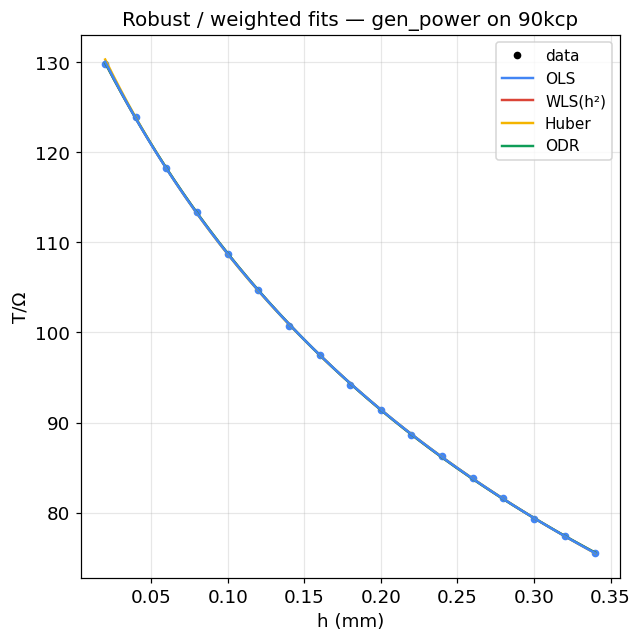

In [10]:
def weighted_fit(name: str, h, y, weight_fn: Callable[[np.ndarray], np.ndarray]) -> FitResult:
    w = np.asarray(weight_fn(np.asarray(h, float)), float)
    sigma = 1.0 / np.sqrt(np.clip(w, 1e-12, None))
    return fit_model(name, h, y, sigma=sigma)

def robust_fit(name: str, h, y, loss: str = "huber", f_scale: float = 1.0) -> FitResult:
    spec = MODELS[name]
    h = np.asarray(h, float); y = np.asarray(y, float)
    p0 = spec["p0"](h, y); lo, hi = spec["bounds"]
    def resid(p): return spec["func"](h, *p) - y
    try:
        res = optimize.least_squares(resid, p0, bounds=(lo, hi),
                                     loss=loss, f_scale=f_scale, max_nfev=20000)
        popt = res.x
        # crude covariance from Jacobian
        J = res.jac
        dof = max(len(y) - len(popt), 1)
        rss = np.sum(res.fun ** 2)
        pcov = np.linalg.pinv(J.T @ J) * (rss / dof)
        ok, msg = res.success, res.message
    except Exception as e:
        popt = np.array(p0); pcov = np.full((len(p0), len(p0)), np.nan); ok, msg = False, str(e)
    return FitResult(name=name, popt=popt, pcov=pcov, pnames=spec["pnames"],
                     func=spec["func"], h=h, y=y, method=f"robust-{loss}",
                     success=ok, message=msg)

def odr_fit(name: str, h, y, sx: float = 0.005, sy: Optional[float] = None) -> FitResult:
    """Orthogonal Distance Regression. sx = std on h (mm), sy = std on y."""
    spec = MODELS[name]
    h = np.asarray(h, float); y = np.asarray(y, float)
    if sy is None: sy = 0.02 * np.std(y) + 1e-9
    def f(B, x): return spec["func"](x, *B)
    model = odr.Model(f)
    data = odr.RealData(h, y, sx=sx, sy=sy)
    p0 = spec["p0"](h, y)
    out = odr.ODR(data, model, beta0=p0, maxit=200).run()
    return FitResult(name=name, popt=out.beta, pcov=out.cov_beta,
                     pnames=spec["pnames"], func=spec["func"], h=h, y=y,
                     method="odr", success=True, message=out.stopreason[0] if out.stopreason else "")

# Demo: gen_power model with three strategies
demo_name = "gen_power"
fit_ols   = fit_model(demo_name, h_f, y_f)
fit_wls   = weighted_fit(demo_name, h_f, y_f, weight_fn=lambda h: h ** 2)   # de-weight small h
fit_rob   = robust_fit(demo_name, h_f, y_f, loss="huber", f_scale=np.std(y_f) * 0.5)
fit_odr   = odr_fit(demo_name, h_f, y_f, sx=0.005)

robust_table = pd.DataFrame({k: v.as_series() for k, v in
                             {"OLS": fit_ols, "WLS(h²)": fit_wls,
                              "Huber": fit_rob, "ODR": fit_odr}.items()}).T
display(robust_table)

# --- Plot 7: Robust / weighted fits comparison ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(h_f, y_f, "ko", ms=4, label="data")
hh = np.linspace(h_f.min(), h_f.max(), 400)
for nm, fr, c in zip(["OLS", "WLS(h²)", "Huber", "ODR"],
                     [fit_ols, fit_wls, fit_rob, fit_odr],
                     ["C0", "C1", "C2", "C3"]):
    ax.plot(hh, fr.predict(hh), color=c, label=nm)
ax.set_xlabel("h (mm)"); ax.set_ylabel("T/Ω")
ax.set_title(f"Robust / weighted fits — {demo_name} on {FOCUS_SAMPLE}")
ax.legend()
plt.tight_layout()
save_fig(fig, "05_robust_weighted"); plt.show()


## 6. Residual analysis

A *good* model has residuals that are (i) zero-mean, (ii) homoscedastic, (iii)
independent of $h$, (iv) approximately Gaussian. We plot:

- residuals vs $h$
- residual histogram
- QQ plot
- residual autocorrelation
- standardized residuals (|z| > 2 flagged)

Helpers: `compute_residuals`, `plot_residuals`, `residual_statistics`.


C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3841234987.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.2f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3841234987.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.2f}" for y in ax.get_yticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3841234987.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.2f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3841234987.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocato

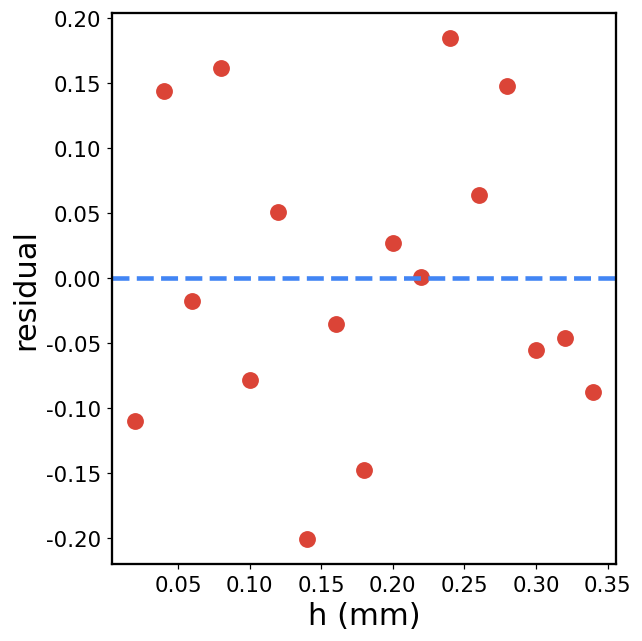

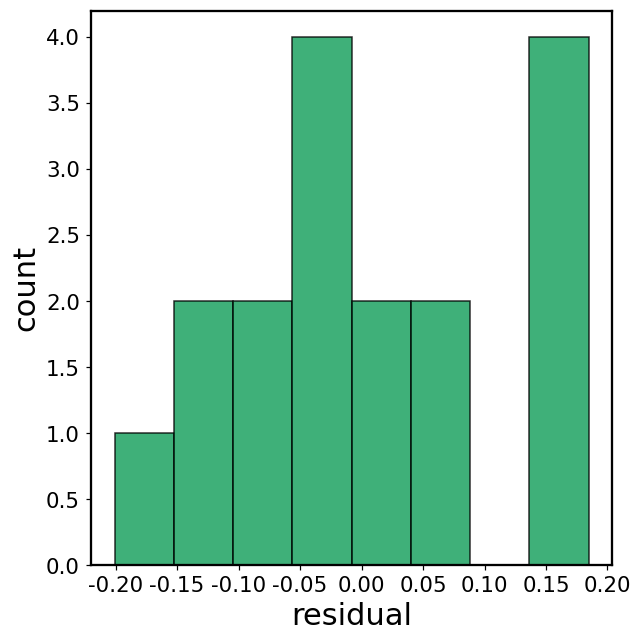

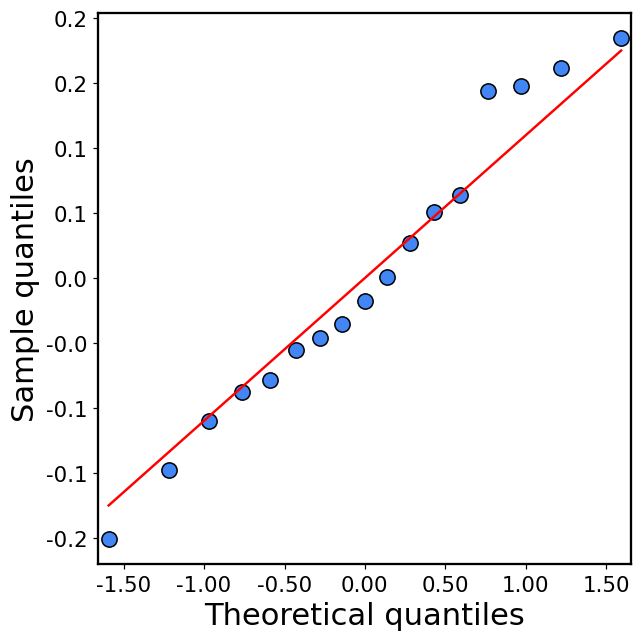

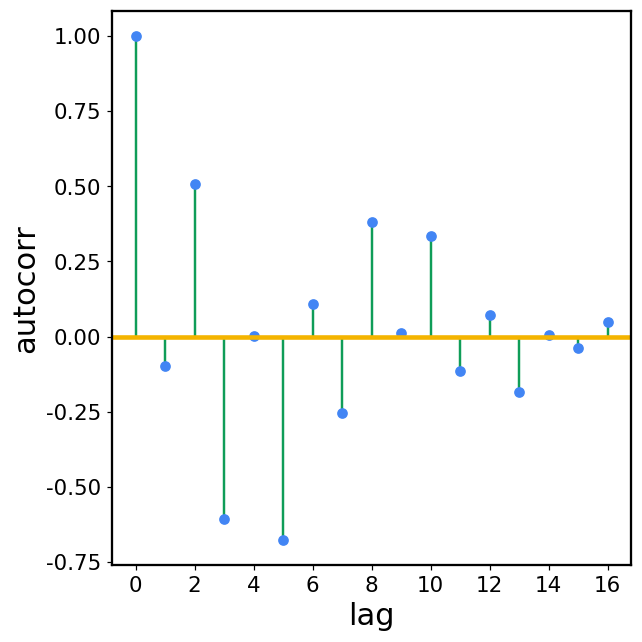

,mean,std,skew,kurtosis,shapiro_W,shapiro_p
hyperbolic,-4.572104e-09,9.617776,-0.047656,-1.399014,0.927730,0.199383
regularized,5.704404e-10,0.120786,0.141691,-0.931521,0.979609,0.953465
gen_power,-6.796801e-11,0.113204,0.132033,-0.922303,0.962928,0.686993
saturation,-7.218190e-09,1.316446,0.101306,-0.612530,0.959947,0.630476


In [11]:
def compute_residuals(fr: FitResult):
    r = fr.residuals
    return r, r / (np.std(r) + 1e-12)

def residual_statistics(r: np.ndarray) -> dict:
    sh = stats.shapiro(r) if 3 <= len(r) <= 5000 else (np.nan, np.nan)
    return {
        "mean": float(np.mean(r)),
        "std": float(np.std(r, ddof=1)),
        "skew": float(stats.skew(r)),
        "kurtosis": float(stats.kurtosis(r)),
        "shapiro_W": float(sh[0]) if sh[0] is not np.nan else np.nan,
        "shapiro_p": float(sh[1]) if sh[1] is not np.nan else np.nan,
    }

def plot_residuals(fr: FitResult, title_prefix: str = ""):
    h = fr.h; r, rz = compute_residuals(fr)

    # --- Plot 8: Residuals vs h ---
    fig1, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(h, r, c="C0", s=100); ax.axhline(0, color="k", ls='--',lw=3)
    ax.set_xlabel("h (mm)", fontsize=20); ax.set_ylabel("residual", fontsize=20)
    ax.grid(False)
    ax.set_xticklabels([f"{x:.2f}" for x in ax.get_xticks()], fontsize=14)
    ax.set_yticklabels([f"{y:.2f}" for y in ax.get_yticks()], fontsize=14)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    plt.tight_layout()

    # --- Plot 9: Residuals histogram ---
    fig2, ax = plt.subplots(figsize=(6, 6))
    ax.hist(r, bins=min(20, max(5, len(r) // 2)), color="C3", alpha=0.8, edgecolor="k")
    ax.set_xlabel("residual", fontsize=20); ax.set_ylabel("count", fontsize=20)
    ax.grid(False)
    ax.set_xticklabels([f"{x:.2f}" for x in ax.get_xticks()], fontsize=14)
    ax.set_yticklabels([f"{y:.1f}" for y in ax.get_yticks()], fontsize=14)
    for spine in ax.spines.values():    
        spine.set_linewidth(1.5)
    plt.tight_layout()

    # --- Plot 10: Residuals QQ plot ---
    fig3, ax = plt.subplots(figsize=(6, 6))
    sm.qqplot(r, line="s", ax=ax, color="C3", markeredgecolor='k', markersize=10)
    ax.set_xlabel("Theoretical quantiles", fontsize=20); ax.set_ylabel("Sample quantiles", fontsize=20)
    ax.grid(False)
    ax.set_xticklabels([f"{x:.2f}" for x in ax.get_xticks()], fontsize=14)
    ax.set_yticklabels([f"{y:.1f}" for y in ax.get_yticks()], fontsize=14)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    plt.tight_layout()

    # --- Plot 11: Residuals ACF ---
    fig4, ax = plt.subplots(figsize=(6, 6))
    lags = min(20, len(r) - 1)
    ac = sm.tsa.acf(r, nlags=lags, fft=False)
    ax.stem(range(lags + 1), ac, linefmt="C3-", markerfmt="C0o", basefmt=" ")
    ax.axhline(0, color="C2", lw=3)
    ax.set_xlabel("lag", fontsize=20); ax.set_ylabel("autocorr", fontsize=20)
    ax.set_xticklabels([f"{x:.0f}" for x in ax.get_xticks()], fontsize=14)
    ax.set_yticklabels([f"{y:.2f}" for y in ax.get_yticks()], fontsize=14)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.grid(False)
    plt.tight_layout()

    return fig1, fig2, fig3, fig4

best_guess = fits["gen_power"] if fits["gen_power"].success else fits["regularized"]
figs = plot_residuals(best_guess, title_prefix=best_guess.name)
for i, fig in enumerate(figs):
    save_fig(fig, f"06_residuals_best_{i+1}"); plt.show()

stats_tbl = pd.DataFrame({name: residual_statistics(fr.residuals) for name, fr in fits.items() if fr.success}).T
display(stats_tbl)

# Automatic narrative
r = best_guess.residuals
if np.any(np.abs(r[:3]) > 3 * np.std(r)):
    print("⚠ Large residuals at the smallest gaps — model may underfit the divergence region.")
if abs(stats.skew(r)) > 1:
    print("⚠ Strongly skewed residuals — consider robust loss or different model.")
if np.corrcoef(best_guess.h, r)[0, 1] ** 2 > 0.2:
    print("⚠ Residuals correlate with h — systematic curvature unmodeled.")


## 7. Model comparison

$R^2$ rewards complexity. We use information criteria and cross-validation as well:

- **RMSE / MAE**: scale-aware error,
- **R² / adjusted R²**: fraction of variance explained,
- **AIC / BIC**: penalised likelihood,
- **K-fold CV RMSE**: out-of-sample predictive accuracy.

Helpers: `compute_metrics`, `compare_models`.


In [12]:
def compute_metrics(fr: FitResult, k_folds: int = 5) -> dict:
    y = fr.y; h = fr.h; n = len(y); k = len(fr.popt)
    yhat = fr.predict(h); r = y - yhat
    rss = float(np.sum(r ** 2)); tss = float(np.sum((y - y.mean()) ** 2))
    rmse = float(np.sqrt(rss / n)); mae = float(np.mean(np.abs(r)))
    r2 = 1 - rss / tss if tss > 0 else np.nan
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(n - k - 1, 1)
    sigma2 = rss / n
    aic = n * np.log(sigma2 + 1e-30) + 2 * k
    bic = n * np.log(sigma2 + 1e-30) + k * np.log(n)

    # K-fold CV
    cv_errs = []
    if n >= k_folds + len(fr.popt) + 1:
        kf = KFold(n_splits=k_folds, shuffle=True, random_state=0)
        for tr, te in kf.split(h):
            try:
                fr_cv = fit_model(fr.name, h[tr], y[tr])
                cv_errs.append(np.sqrt(np.mean((y[te] - fr_cv.predict(h[te])) ** 2)))
            except Exception:
                pass
    cv_rmse = float(np.mean(cv_errs)) if cv_errs else np.nan

    return {"n": n, "k": k, "RMSE": rmse, "MAE": mae, "R2": r2,
            "adjR2": adj_r2, "AIC": aic, "BIC": bic, "CV_RMSE": cv_rmse}

def compare_models(fits_dict: Dict[str, FitResult]) -> pd.DataFrame:
    rows = {name: compute_metrics(fr) for name, fr in fits_dict.items() if fr.success}
    df = pd.DataFrame(rows).T
    df = df.sort_values("AIC")
    df["ΔAIC"] = df["AIC"] - df["AIC"].min()
    df["ΔBIC"] = df["BIC"] - df["BIC"].min()
    return df

comparison = compare_models(fits)
display(comparison.round(4))

best_pred  = comparison["CV_RMSE"].idxmin() if comparison["CV_RMSE"].notna().any() else comparison["RMSE"].idxmin()
best_aic   = comparison["AIC"].idxmin()
print(f"Best predictive (CV-RMSE) : {best_pred}")
print(f"Best AIC (parsimony)      : {best_aic}")


,n,k,RMSE,MAE,R2,adjR2,AIC,BIC,CV_RMSE,ΔAIC,ΔBIC
gen_power,17.0,4.0,0.1098,0.0918,1.0000,0.9999,-67.1016,-63.7688,0.1660,0.0000,0.6292
regularized,17.0,3.0,0.1172,0.1015,0.9999,0.9999,-66.8976,-64.3980,0.1374,0.2040,0.0000
saturation,17.0,3.0,1.2771,1.0849,0.9939,0.9925,14.3172,16.8168,1.8740,81.4188,81.2148
hyperbolic,17.0,2.0,9.3306,8.2642,0.6732,0.6265,79.9322,81.5987,14.3080,147.0339,145.9967


Best predictive (CV-RMSE) : regularized
Best AIC (parsimony)      : gen_power


## 8. Low-gap sensitivity analysis

The model parameters — especially $A$ and the inferred viscosity — should be
**stable** when the smallest-gap points are removed. If the answer swings wildly,
the result is dominated by ill-conditioned near-contact data and a regularized
model with $h_0$ is required.


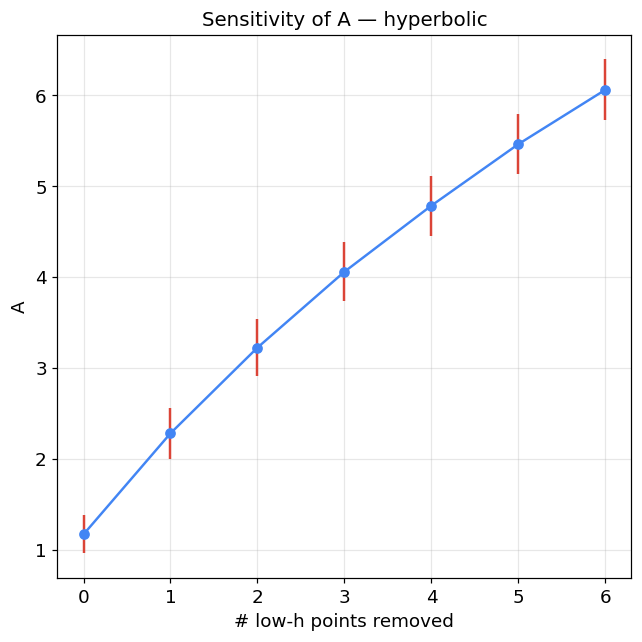

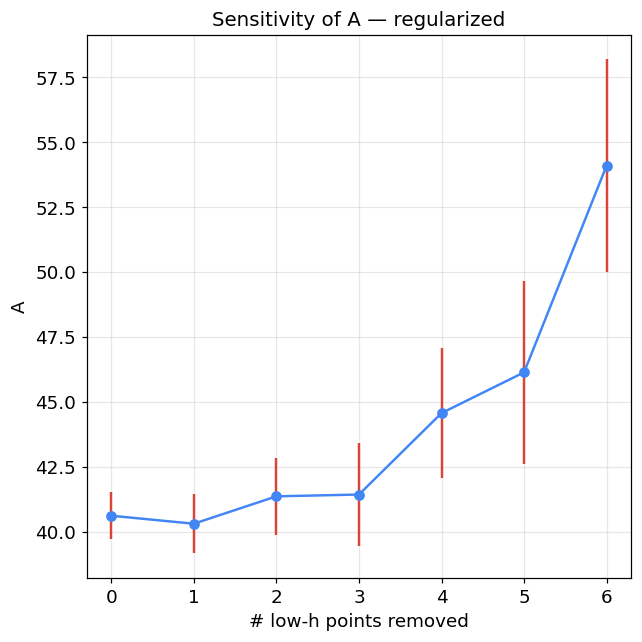

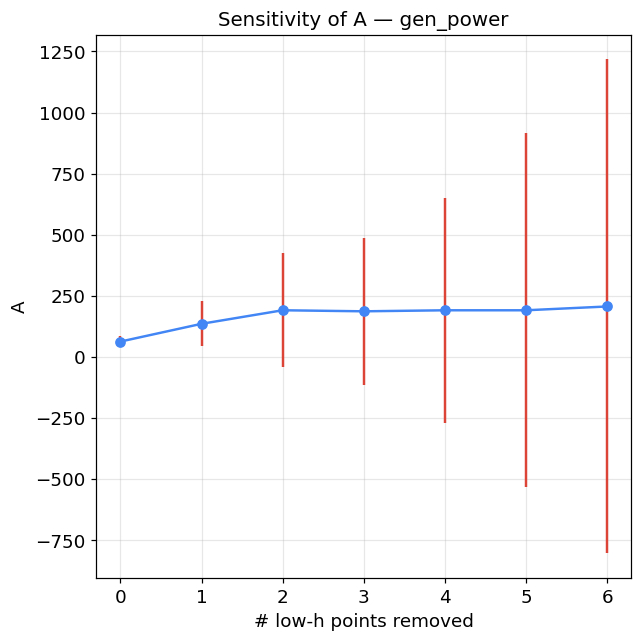

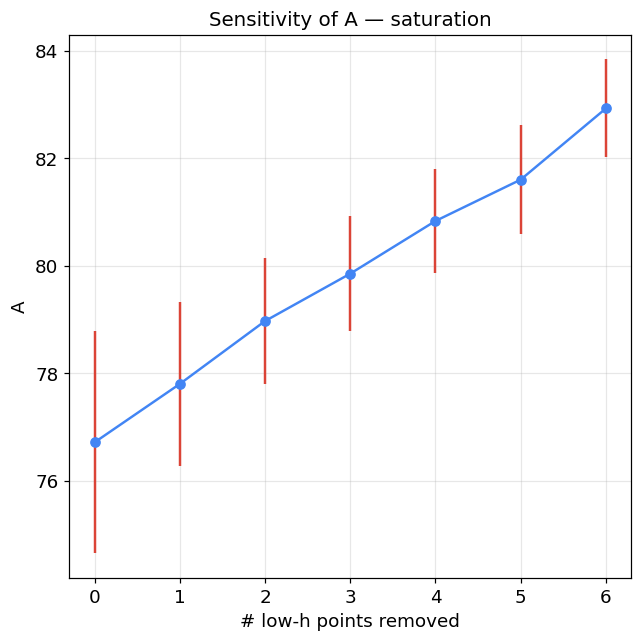

C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\1833957558.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.0f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\1833957558.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.2f}" for y in ax.get_yticks()], fontsize=14)


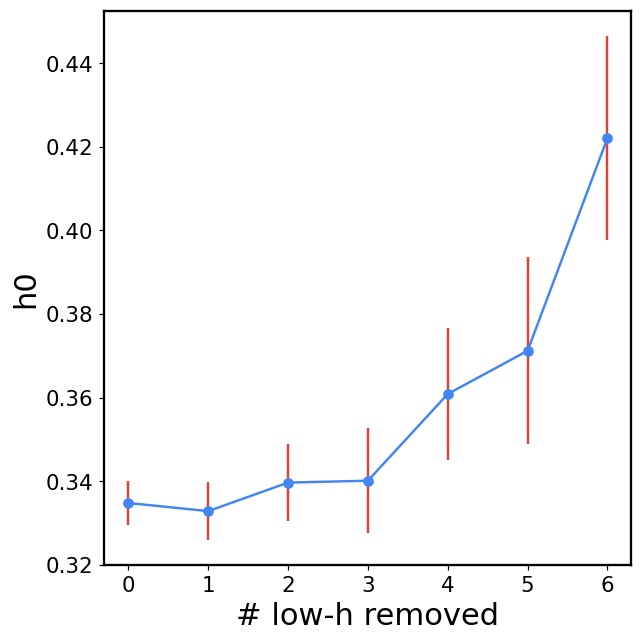

C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\1833957558.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.0f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\1833957558.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.2f}" for y in ax.get_yticks()], fontsize=14)


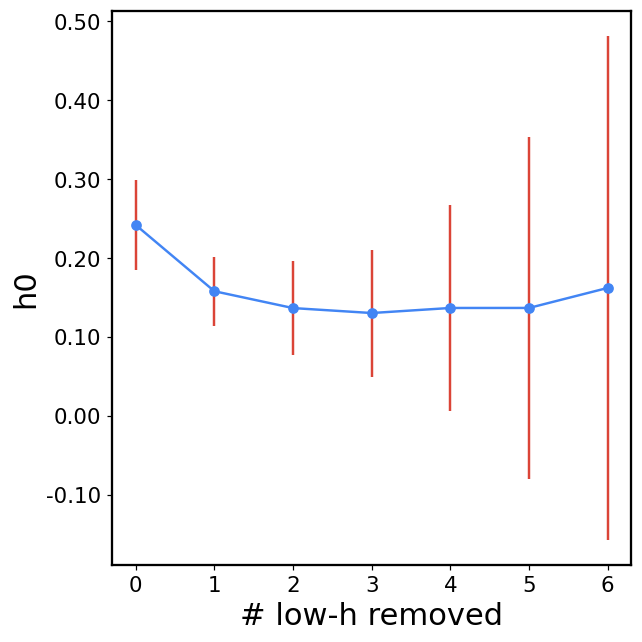

C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\1833957558.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.0f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\1833957558.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.2f}" for y in ax.get_yticks()], fontsize=14)


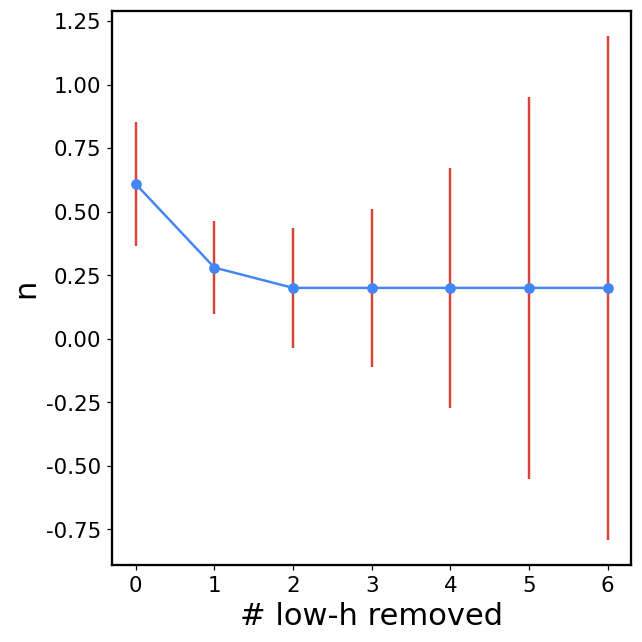

hyperbolic      CV(A) over removals = 0.454
regularized     CV(A) over removals = 0.112
gen_power       CV(A) over removals = 0.306
saturation      CV(A) over removals = 0.027


In [13]:
def remove_low_gap_points(h, y, k: int) -> Tuple[np.ndarray, np.ndarray]:
    order = np.argsort(h)
    keep = order[k:]
    return np.asarray(h)[keep], np.asarray(y)[keep]

def sensitivity_analysis(h, y, model_name: str, max_remove: int = 6) -> pd.DataFrame:
    rows = []
    for k in range(0, max_remove + 1):
        hk, yk = remove_low_gap_points(h, y, k)
        if len(hk) < len(MODELS[model_name]["pnames"]) + 1:
            break
        fr = fit_model(model_name, hk, yk)
        row = {"removed": k, "n_used": len(hk)}
        for n, v, s in zip(fr.pnames, fr.popt, fr.perr):
            row[n] = v; row[f"{n}_se"] = s
        rows.append(row)
    return pd.DataFrame(rows)

sens_tables = {name: sensitivity_analysis(h_f, y_f, name) for name in MODELS}

# --- Plots 12–15: Sensitivity of A per model (one figure per model) ---
for plot_num, (name, tbl) in enumerate(sens_tables.items(), start=12):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.errorbar(tbl["removed"], tbl["A"], yerr=tbl["A_se"], fmt="o-", color="C0")
    ax.set_title(f"Sensitivity of A — {name}")
    ax.set_xlabel("# low-h points removed"); ax.set_ylabel("A")
    plt.tight_layout()
    save_fig(fig, f"08_sensitivity_A_{name}"); plt.show()

# --- Plots 16–18: Sensitivity of h0 / n for regularized and gen_power ---
plot_num = 16
for name in ["regularized", "gen_power"]:
    tbl = sens_tables[name]
    cols = [c for c in ["h0", "n"] if c in tbl.columns]
    for c in cols:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.errorbar(tbl["removed"], tbl[c], yerr=tbl[f"{c}_se"], fmt="o-")
        ax.set_xlabel("# low-h removed", fontsize=20); ax.set_ylabel(c, fontsize=20)
        ax.set_xticklabels([f"{x:.0f}" for x in ax.get_xticks()], fontsize=14)
        ax.set_yticklabels([f"{y:.2f}" for y in ax.get_yticks()], fontsize=14)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        plt.tight_layout()
        save_fig(fig, f"08_sensitivity_{name}_{c}"); plt.show()
        plot_num += 1

for name, tbl in sens_tables.items():
    cv_A = tbl["A"].std() / abs(tbl["A"].mean() + 1e-12)
    print(f"{name:<14s}  CV(A) over removals = {cv_A:.3f}")


## 9. Uncertainty quantification — bootstrap (and optional MCMC)

Bootstrap resamples the data (rows) with replacement, refits, and aggregates the
parameter distributions. This is robust to model misspecification of the noise
structure. Optional MCMC (via `emcee`) is included as a Bayesian alternative when
the package is available.


Bootstrap on 'gen_power'  (n=400 successful resamples)


,median,ci95_lo,ci95_hi,std
A,66.682505,34.069412,193.535830,48.880525
h0,0.232348,0.135261,0.503909,0.097299
n,0.571671,0.200000,1.801601,0.421329
B,-16.101840,-148.608192,36.516974,52.989111


C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\521471594.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\521471594.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)


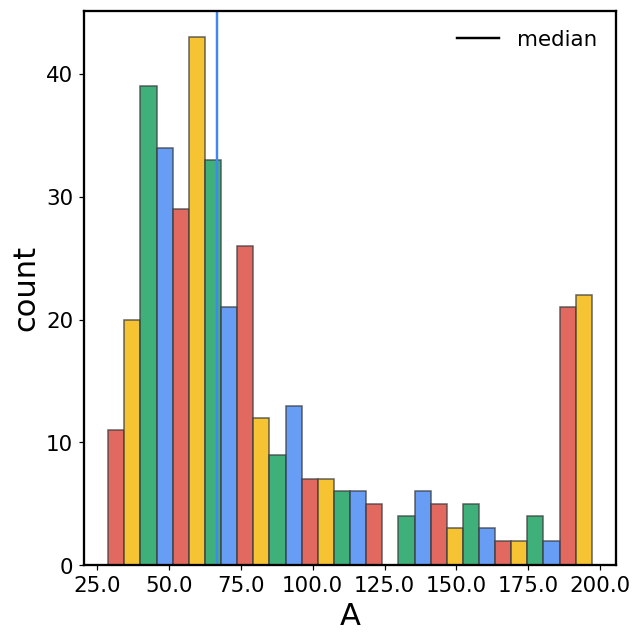

C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\521471594.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\521471594.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)


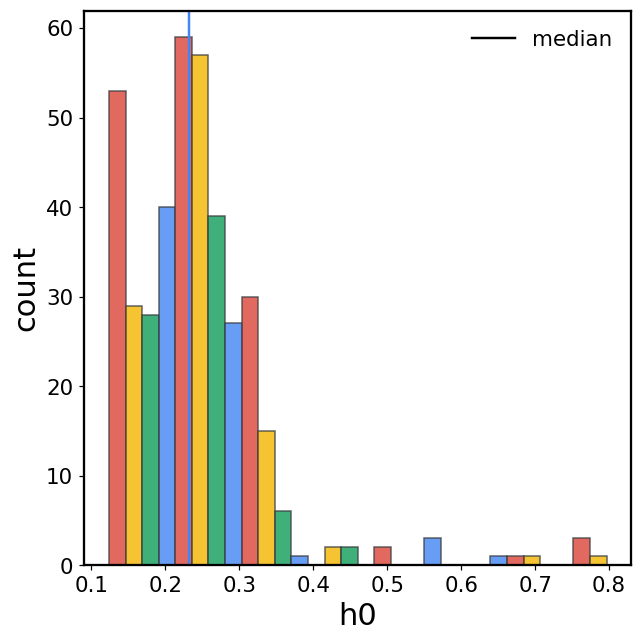

C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\521471594.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\521471594.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)


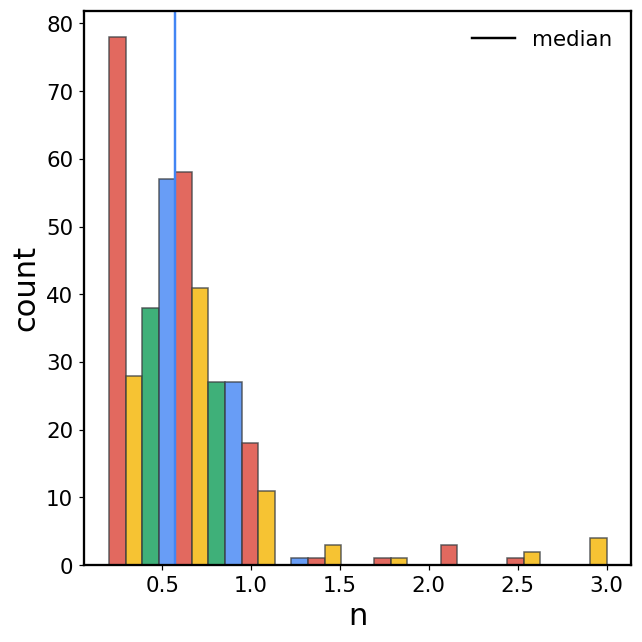

C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\521471594.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\521471594.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)


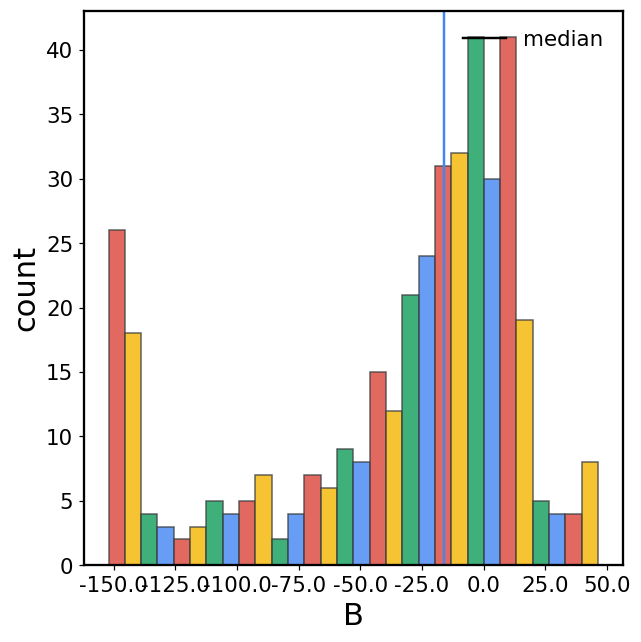

C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\521471594.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\521471594.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)


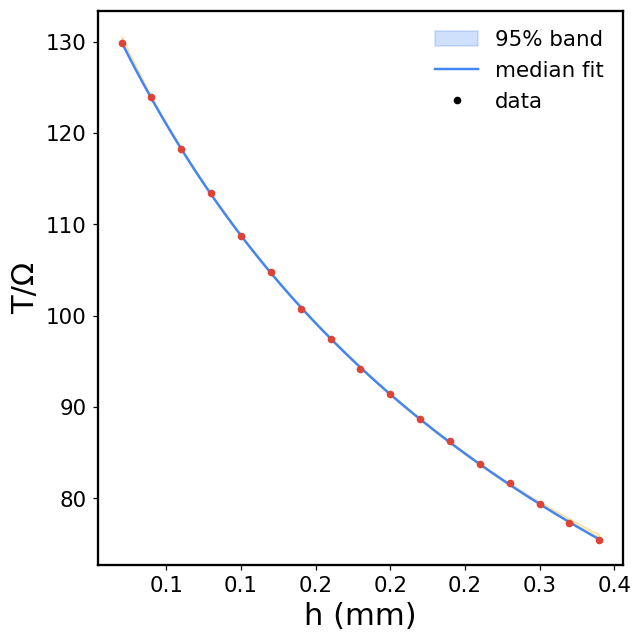

(Bootstrap band is Plot 23)


In [14]:
def bootstrap_fit(model_name: str, h, y, n_boot: int = 500,
                  random_state: int = 0) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    h = np.asarray(h); y = np.asarray(y); n = len(h)
    rows = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            fr = fit_model(model_name, h[idx], y[idx])
            if fr.success:
                rows.append(dict(zip(fr.pnames, fr.popt)))
        except Exception:
            continue
    return pd.DataFrame(rows)

def parameter_confidence_intervals(boot_df: pd.DataFrame, level: float = 0.95) -> pd.DataFrame:
    lo, hi = (1 - level) / 2, 1 - (1 - level) / 2
    return pd.DataFrame({
        "median": boot_df.median(),
        f"ci{int(level*100)}_lo": boot_df.quantile(lo),
        f"ci{int(level*100)}_hi": boot_df.quantile(hi),
        "std": boot_df.std(),
    })

boot_name = best_aic  # use the parsimoniously best model
boot = bootstrap_fit(boot_name, h_f, y_f, n_boot=400)
ci   = parameter_confidence_intervals(boot)
print(f"Bootstrap on '{boot_name}'  (n={len(boot)} successful resamples)")
display(ci)

# --- Plots 19+: Bootstrap parameter distributions (one figure per parameter) ---
for plot_num, col in enumerate(boot.columns, start=19):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.hist(boot[col], bins=30, color="C0", alpha=0.8, edgecolor="k")
    ax.axvline(ci.loc[col, "median"], color="k", label="median")
    ax.set_xlabel(col, fontsize=20); ax.set_ylabel("count", fontsize=20)
    ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
    ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.legend(fontsize=14, frameon=False, loc="upper right")
    plt.tight_layout()
    save_fig(fig, f"09_bootstrap_hist_{col}"); plt.show()

# Predictive confidence band
hh = np.linspace(h_f.min(), h_f.max(), 300)
preds = np.array([MODELS[boot_name]["func"](hh, *row) for row in boot.values])
band_lo, band_hi = np.percentile(preds, [2.5, 97.5], axis=0)
median = np.percentile(preds, 50, axis=0)

# --- Plot (19 + n_params): Bootstrap prediction band ---
_boot_band_plot_num = 19 + boot.shape[1]
fig, ax = plt.subplots(figsize=(6, 6))
ax.fill_between(hh, band_lo, band_hi, alpha=0.25, color="C0", label="95% band")
ax.plot(hh, median, "C0", label="median fit")
ax.plot(h_f, y_f, "ko", ms=4, label="data")
ax.set_xlabel("h (mm)", fontsize=20); ax.set_ylabel("T/Ω", fontsize=20)
ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)
ax.grid(False)
ax.legend(fontsize=14, frameon=False, loc="upper right")
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
plt.tight_layout()
save_fig(fig, "09_bootstrap_band"); plt.show()
print(f"(Bootstrap band is Plot {_boot_band_plot_num})")


In [15]:
# --- Optional Bayesian MCMC (only runs if emcee is installed) --------------
if HAS_EMCEE:
    import emcee
    def log_prob(theta, h, y, model):
        if np.any(np.array(theta[:-1]) <= 0):  # positivity for first params
            return -np.inf
        sigma = max(theta[-1], 1e-6)
        try:
            pred = model(h, *theta[:-1])
        except Exception:
            return -np.inf
        return -0.5 * np.sum(((y - pred) / sigma) ** 2 + np.log(2 * np.pi * sigma ** 2))

    spec = MODELS[boot_name]
    p0 = list(spec["p0"](h_f, y_f)) + [np.std(y_f) * 0.1]
    nwalk, ndim = 32, len(p0)
    pos = p0 + 1e-3 * np.random.randn(nwalk, ndim) * (np.abs(p0) + 1e-6)
    sampler = emcee.EnsembleSampler(nwalk, ndim, log_prob, args=(h_f, y_f, spec["func"]))
    sampler.run_mcmc(pos, 1500, progress=False)
    chain = sampler.get_chain(discard=500, flat=True)
    mcmc_df = pd.DataFrame(chain, columns=spec["pnames"] + ["sigma"])
    display(parameter_confidence_intervals(mcmc_df))
else:
    print("emcee not installed — skipping MCMC. (pip install emcee to enable.)")


emcee not installed — skipping MCMC. (pip install emcee to enable.)


## 10. Final scientific interpretation

Parameter interpretation (with the recommended model):

- **$A$** is proportional to the apparent viscosity through the geometry constant.
  Comparing $A$ across samples gives a direct viscosity ranking.
- **$h_0$** is the effective gap-zero offset. A non-zero $h_0$ ($\sim 10\text{–}100\,\mu m$)
  is the fingerprint of slip / asperity / compliance.
- **$n$** ≠ 1 in the generalized model signals departure from classical Newtonian
  lubrication. $n<1$ is typical of shear-thinning; $n>1$ of squeeze-film effects.
- **$B$** is the parasitic baseline (bearings, air drag, instrument offset).

Plausible physical mechanisms behind a non-ideal $h_0$/$n$:
slip at the solid–fluid interface, surface roughness (asperity contact),
plate compliance under torque, steric / depletion layers of polymer chains,
viscoelastic stress build-up.


In [16]:
# Build a publication-ready summary table for the focus sample
def build_summary(fits_dict, comparison, boot_df, model_name) -> pd.DataFrame:
    fr = fits_dict[model_name]
    base = summarize_fit(fr).set_index("param")
    metrics = pd.Series(compute_metrics(fr), name="metric")
    boot_ci = parameter_confidence_intervals(boot_df) if boot_df is not None else None
    return base, metrics, boot_ci

base_tbl, metrics_tbl, boot_ci = build_summary(fits, comparison, boot, best_aic)
print(f"### Recommended model: {best_aic}\n")
display(base_tbl)
print("\nGoodness of fit:"); display(metrics_tbl.to_frame())
if boot_ci is not None:
    print("\nBootstrap 95% CIs:"); display(boot_ci)

# Export
base_tbl.to_csv(OUT_DIR / f"params_{FOCUS_SAMPLE}_{best_aic}.csv")
metrics_tbl.to_csv(OUT_DIR / f"metrics_{FOCUS_SAMPLE}_{best_aic}.csv")
if boot_ci is not None:
    boot_ci.to_csv(OUT_DIR / f"bootstrap_{FOCUS_SAMPLE}_{best_aic}.csv")
comparison.to_csv(OUT_DIR / f"model_comparison_{FOCUS_SAMPLE}.csv")
print(f"\nExports written to {OUT_DIR.resolve()}")

# Narrative
narr = []
A = fits[best_aic].popt[0]
narr.append(f"On sample {FOCUS_SAMPLE}, the best model is **{best_aic}** "
            f"(ΔAIC over runner-up = {comparison['ΔAIC'].iloc[1]:.2f}).")
if "h0" in fits[best_aic].pnames:
    h0 = fits[best_aic].popt[fits[best_aic].pnames.index("h0")]
    narr.append(f"The regularization length h0 ≈ {h0*1000:.1f} µm is non-negligible, "
                "consistent with a finite slip / compliance / gap-zero offset.")
if "n" in fits[best_aic].pnames:
    n = fits[best_aic].popt[fits[best_aic].pnames.index("n")]
    narr.append(f"The exponent n ≈ {n:.2f} {'departs from' if abs(n-1)>0.1 else 'is consistent with'} "
                f"classical 1/h lubrication.")
narr.append(f"Coefficient A ≈ {A:.3g} encodes the apparent viscosity through the geometry constant.")
print("\n".join(narr))


### Recommended model: gen_power



,value,stderr,ci95_lo,ci95_hi
param,,,,
A,62.551870,24.192436,15.134695,109.969045
h0,0.242071,0.057272,0.129817,0.354325
n,0.609053,0.242439,0.133872,1.084233
B,-11.438048,27.470991,-65.281189,42.405094



Goodness of fit:


,metric
n,17.000000
k,4.000000
RMSE,0.109824
MAE,0.091759
R2,0.999955
adjR2,0.999940
AIC,-67.101648
BIC,-63.768795
CV_RMSE,0.166033



Bootstrap 95% CIs:


,median,ci95_lo,ci95_hi,std
A,66.682505,34.069412,193.535830,48.880525
h0,0.232348,0.135261,0.503909,0.097299
n,0.571671,0.200000,1.801601,0.421329
B,-16.101840,-148.608192,36.516974,52.989111



Exports written to C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\results\Auto-runs\outputs_rheology
On sample 90kcp, the best model is **gen_power** (ΔAIC over runner-up = 0.20).
The regularization length h0 ≈ 242.1 µm is non-negligible, consistent with a finite slip / compliance / gap-zero offset.
The exponent n ≈ 0.61 departs from classical 1/h lubrication.
Coefficient A ≈ 62.6 encodes the apparent viscosity through the geometry constant.


## 11. Publication-quality figure
A clean two-panel figure: (left) data + best fit with 95 % band; (right) residuals.


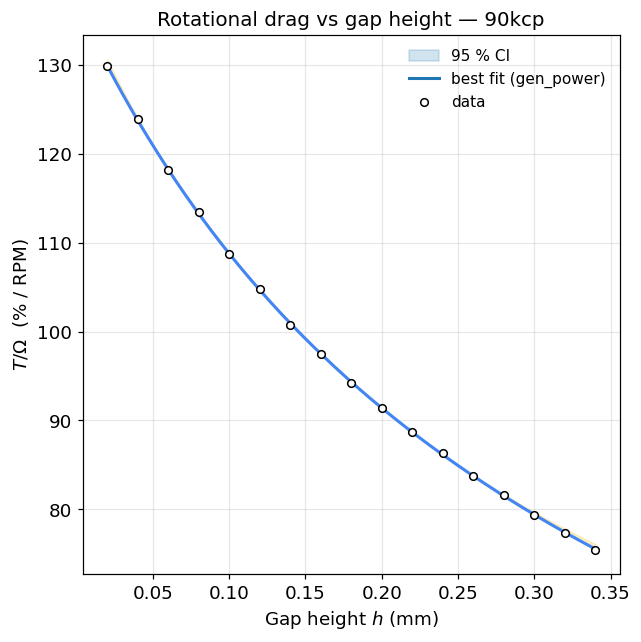

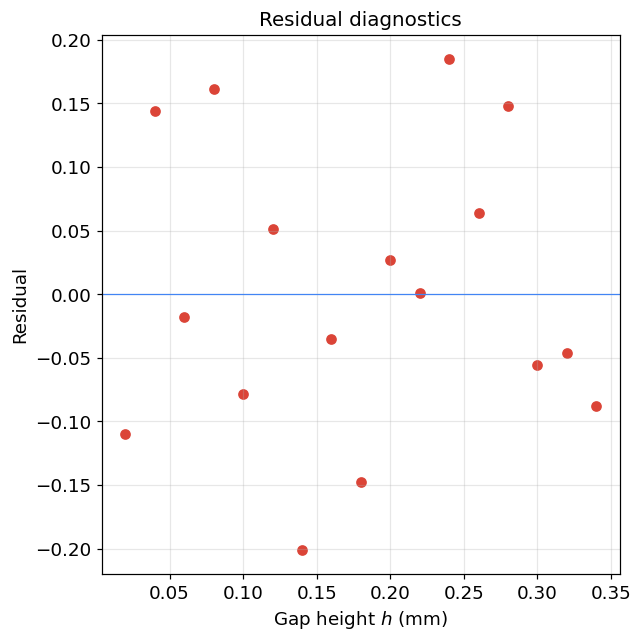

In [17]:
# --- Plot A: Publication — data + best fit with 95% CI band ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.fill_between(hh, band_lo, band_hi, alpha=0.20, color="#1f77b4", label="95 % CI")
ax.plot(hh, median, color="#1f77b4", lw=2, label=f"best fit ({boot_name})")
ax.plot(h_f, y_f, "o", ms=5, mfc="white", mec="k", label="data")
ax.set_xlabel("Gap height $h$ (mm)")
ax.set_ylabel(r"$T/\Omega$  ({})".format(Y_UNIT))
ax.set_title(f"Rotational drag vs gap height — {FOCUS_SAMPLE}")
ax.legend(frameon=False)
plt.tight_layout()
save_fig(fig, "11_publication_fit")
plt.show()

# --- Plot B: Publication — residual diagnostics ---
fig, ax = plt.subplots(figsize=(6, 6))
r = fits[boot_name].residuals
ax.axhline(0, color="k", lw=0.8)
ax.scatter(h_f, r, color="#1f77b4", edgecolor="k")
ax.set_xlabel("Gap height $h$ (mm)")
ax.set_ylabel("Residual")
ax.set_title("Residual diagnostics")
plt.tight_layout()
save_fig(fig, "11_publication_residuals")
plt.show()


## 12. Optional advanced analyses

- **Spline fit** as a non-parametric reference for the trend.
- **Automatic regime segmentation** via local-slope change-points.
- **Multi-sample sweep**: fit the recommended model to every sample in the dataset
  and tabulate $A$, $h_0$, $n$ → viscosity ranking.


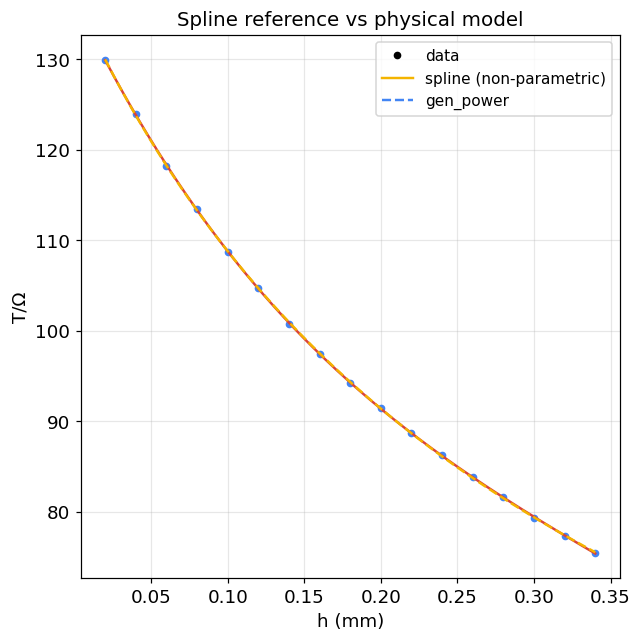

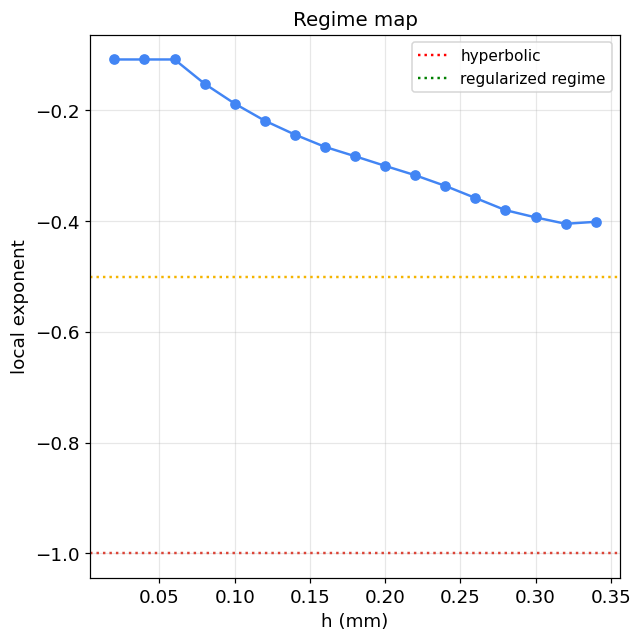

In [18]:
from scipy.interpolate import UnivariateSpline

def spline_fit(h, y, s=None):
    order = np.argsort(h); h, y = np.asarray(h)[order], np.asarray(y)[order]
    spl = UnivariateSpline(h, y, k=4, s=s if s is not None else len(h) * np.var(y) * 0.001)
    return spl

spl = spline_fit(h_f, y_f)
hh = np.linspace(h_f.min(), h_f.max(), 400)

# --- Plot C: Spline reference vs physical model ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(h_f, y_f, "ko", ms=4, label="data")
ax.plot(hh, spl(hh), "C2", label="spline (non-parametric)")
ax.plot(hh, fits[boot_name].predict(hh), "C0--", label=f"{boot_name}")
ax.set_xlabel("h (mm)"); ax.set_ylabel("T/Ω")
ax.set_title("Spline reference vs physical model")
ax.legend()
plt.tight_layout()
save_fig(fig, "12_spline_vs_model"); plt.show()

# Regime segmentation: local slope crossing of -0.5 and -1
h_l, slopes = compute_local_slope(h_f, y_f, window=5)

# --- Plot D: Regime map (local scaling exponent) ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(h_l, slopes, "o-"); ax.axhline(-1, ls=":", color="r", label="hyperbolic")
ax.axhline(-0.5, ls=":", color="g", label="regularized regime")
ax.set_xlabel("h (mm)"); ax.set_ylabel("local exponent")
ax.set_title("Regime map")
ax.legend()
plt.tight_layout()
save_fig(fig, "12_regime_map"); plt.show()


,sample,n_pts,model,success,RMSE,R2,AIC,A,A_se,h0,h0_se,n,n_se,B,B_se,visc_kcp
0,1kcp,16,gen_power,True,0.001622,0.999918,-197.580354,2.118328,2.068896,0.134589,0.039354,0.200000,0.183303,-1.683986,2.107356,1.0
1,2kcp,16,gen_power,True,0.009471,0.999690,-141.104300,5.675913,9.036820,0.111415,0.056123,0.200000,0.292906,-4.341286,9.216230,2.0
2,4kcp,21,gen_power,True,0.009787,0.999922,-186.321897,2.553898,1.723773,0.764743,0.260143,3.000000,1.106969,2.548345,0.270484,4.0
3,5kcp,17,gen_power,True,0.037418,0.998384,-103.710805,1.218597,3.061954,0.630317,1.167591,2.999813,6.025981,2.601790,1.255835,5.0
4,8kcp,19,gen_power,True,0.011271,0.999942,-162.450534,2.505921,1.293019,0.689103,0.215609,3.000000,1.016182,3.974514,0.330991,8.0
5,10kcp,21,gen_power,True,0.053977,0.998859,-114.606452,2.847495,5.838267,0.707333,0.828486,3.000000,3.766495,4.633062,1.243686,10.0
6,12.5kcp,18,gen_power,True,0.032081,0.999813,-115.822083,3.726508,1.511599,0.283849,0.110281,1.109378,0.545610,3.831233,2.167168,12.5
7,15kcp,11,gen_power,True,0.153982,0.995110,-33.160222,28.462614,406.528558,0.115390,0.446130,0.200000,2.573873,-19.222211,415.706323,15.0
8,20kcp,17,gen_power,True,0.055255,0.999819,-90.457079,15.619535,9.894076,0.136263,0.044614,0.443744,0.246694,-4.649932,10.702268,20.0
9,25kcp,23,gen_power,True,0.076352,0.999704,-110.330519,17.682225,8.681729,0.136265,0.037685,0.402140,0.182724,-7.713753,9.211188,25.0


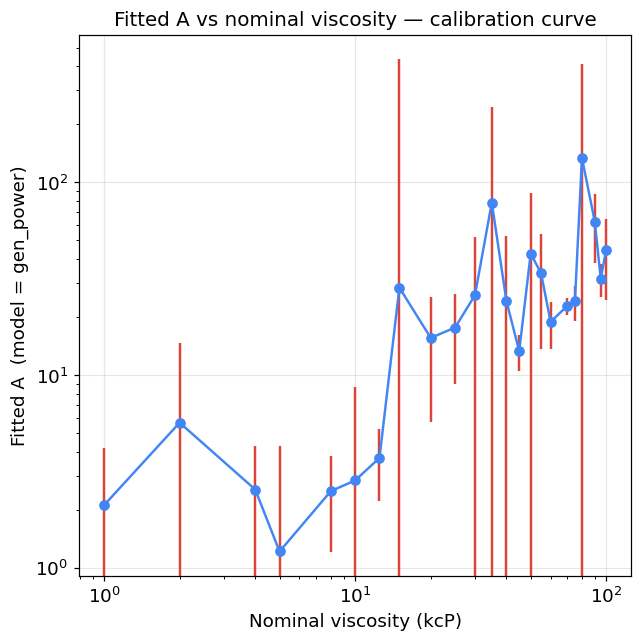

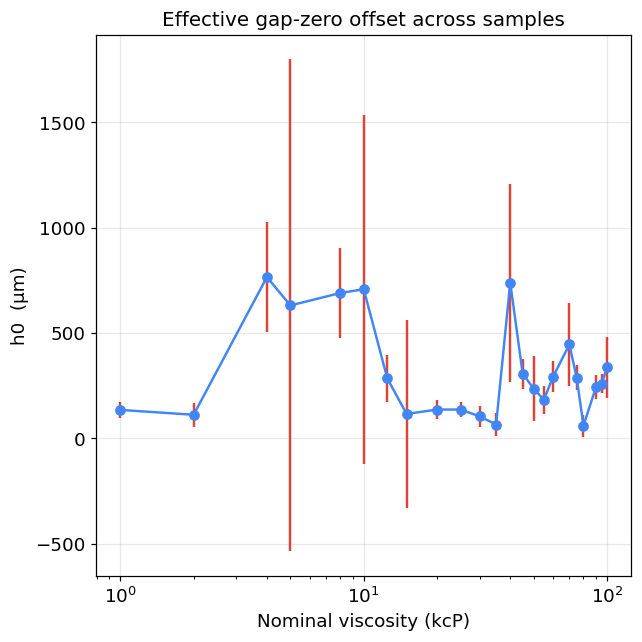

In [19]:
# Multi-sample sweep
def fit_all_samples(tidy_df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    out = []
    for s, sub in tidy_df.groupby("sample"):
        sub = sub.dropna(subset=["h_mm", "T_over_RPM"])
        if len(sub) < len(MODELS[model_name]["pnames"]) + 1:
            continue
        fr = fit_model(model_name, sub["h_mm"].values, sub["T_over_RPM"].values)
        m = compute_metrics(fr)
        row = {"sample": s, "n_pts": len(sub), "model": model_name,
               "success": fr.success, "RMSE": m["RMSE"], "R2": m["R2"], "AIC": m["AIC"]}
        for n, v, se in zip(fr.pnames, fr.popt, fr.perr):
            row[n] = v; row[f"{n}_se"] = se
        out.append(row)
    df = pd.DataFrame(out)
    # numeric viscosity for sorting
    df["visc_kcp"] = df["sample"].str.replace("kcp", "", regex=False).astype(float)
    return df.sort_values("visc_kcp").reset_index(drop=True)

sweep = fit_all_samples(tidy, best_aic)
display(sweep.head(10))
sweep.to_csv(OUT_DIR / f"sweep_{best_aic}.csv", index=False)

# --- Plot E: Fitted A vs nominal viscosity — calibration curve ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(sweep["visc_kcp"], sweep["A"], yerr=sweep["A_se"], fmt="o-")
ax.set_xlabel("Nominal viscosity (kcP)")
ax.set_ylabel(f"Fitted A  (model = {best_aic})")
ax.set_title("Fitted A vs nominal viscosity — calibration curve")
ax.set_xscale("log"); ax.set_yscale("log")
plt.tight_layout()
save_fig(fig, "12_A_vs_viscosity"); plt.show()

# --- Plot F: Effective gap-zero offset across samples ---
if "h0" in sweep.columns:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.errorbar(sweep["visc_kcp"], sweep["h0"] * 1000, yerr=sweep["h0_se"] * 1000, fmt="o-", color="C3")
    ax.set_xlabel("Nominal viscosity (kcP)"); ax.set_ylabel("h0  (µm)")
    ax.set_title("Effective gap-zero offset across samples")
    ax.set_xscale("log")
    plt.tight_layout()
    save_fig(fig, "12_h0_vs_viscosity"); plt.show()


## Conclusion & key scientific reminders

1. Pure $1/h$ divergence is rarely physically valid right up to contact.
2. Regularized hyperbolic / generalized-power models with a non-zero $h_0$ are usually
   more physically meaningful.
3. Gap-height uncertainty dominates at small $h$ — use ODR or weight $h^2$ if in doubt.
4. Residual diagnostics are mandatory — high $R^2$ alone does **not** validate a fit.
5. Stability under removal of low-gap points is the cleanest test of model robustness.
6. Always fit in physical space, not in log/inverse space.
7. Cross-validation and AIC/BIC together protect against overfitting.

All exported tables and figures are in `outputs_rheology/` and `figures_rheology/`.


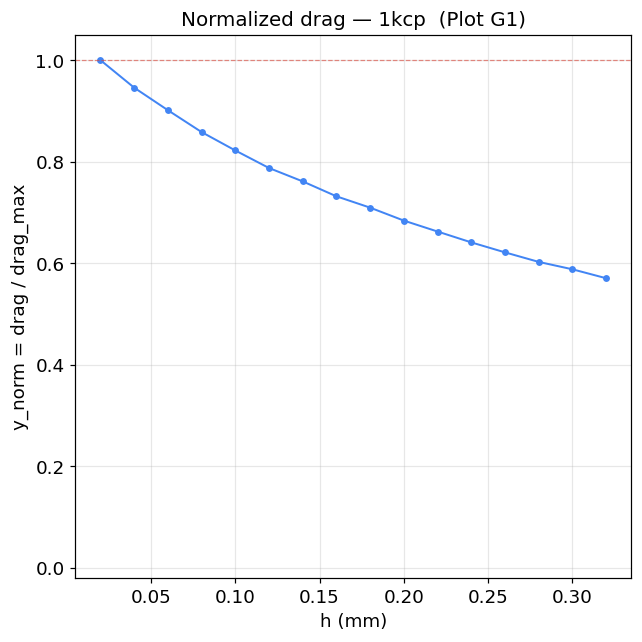

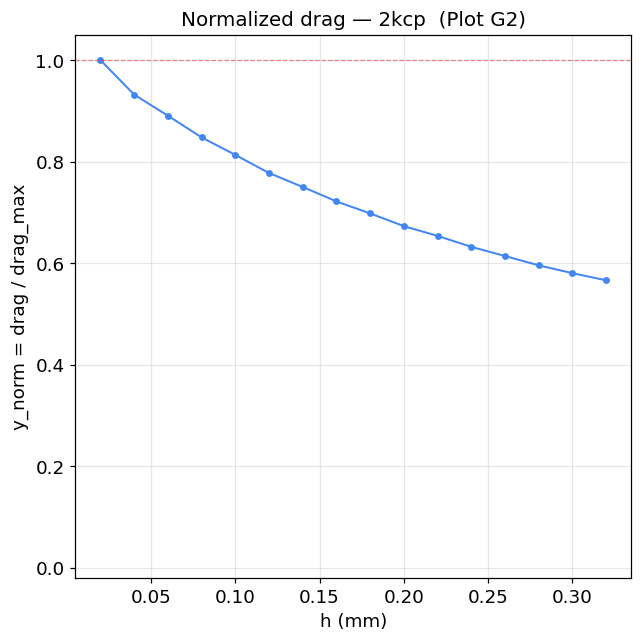

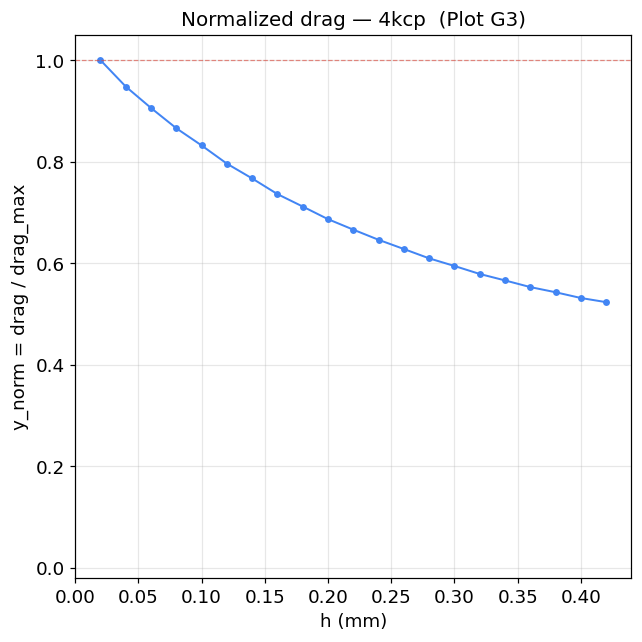

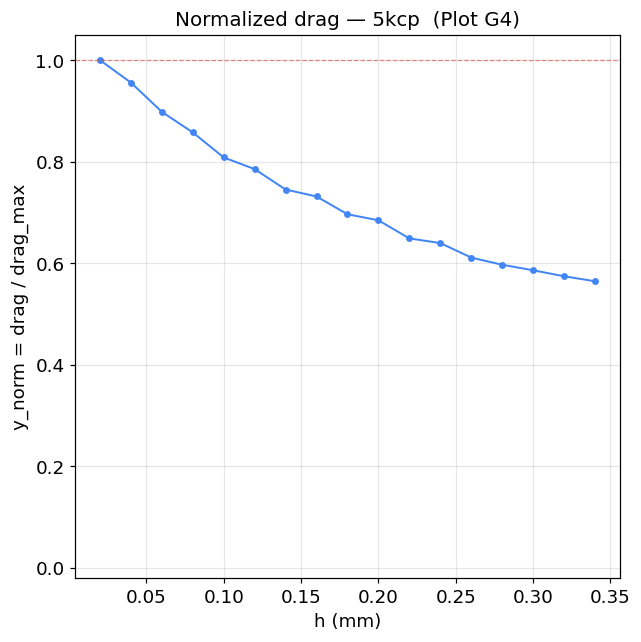

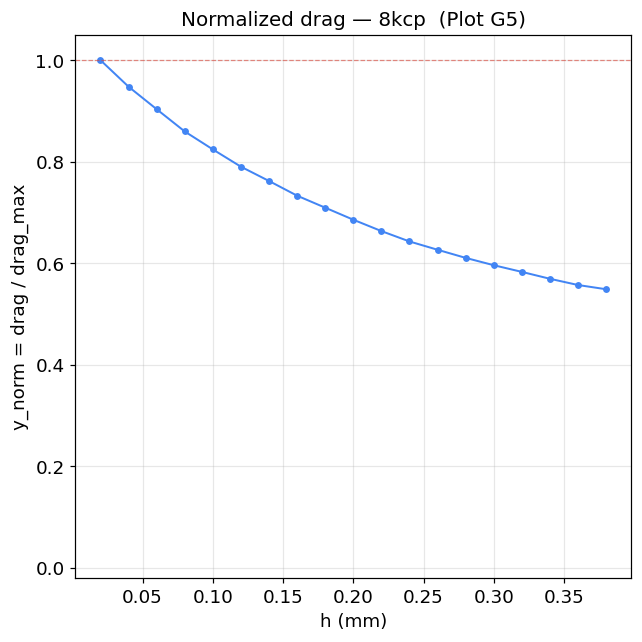

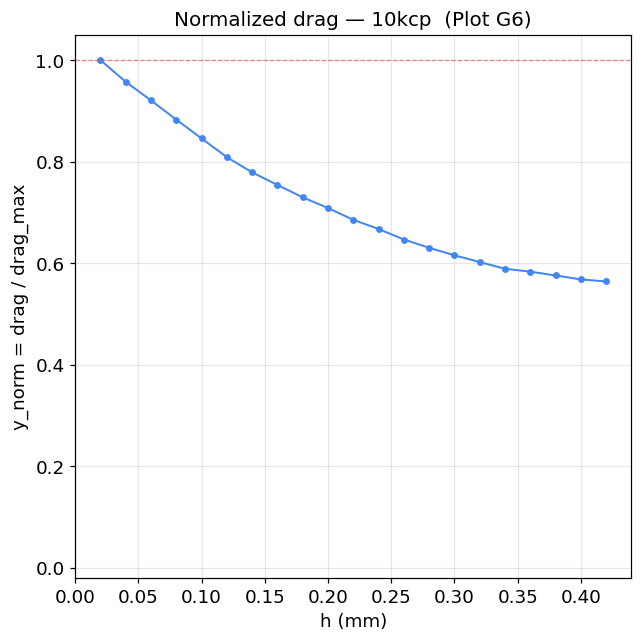

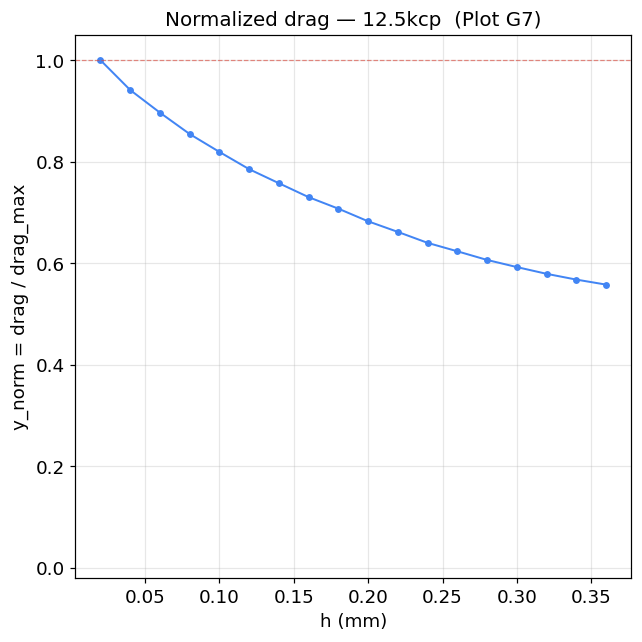

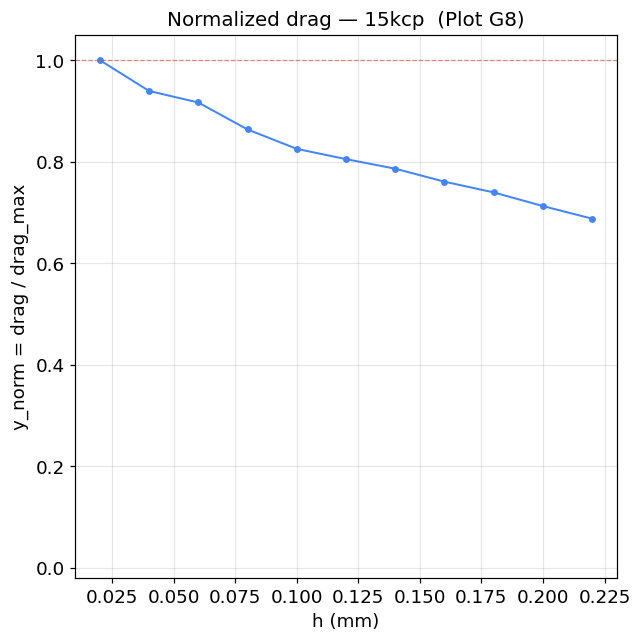

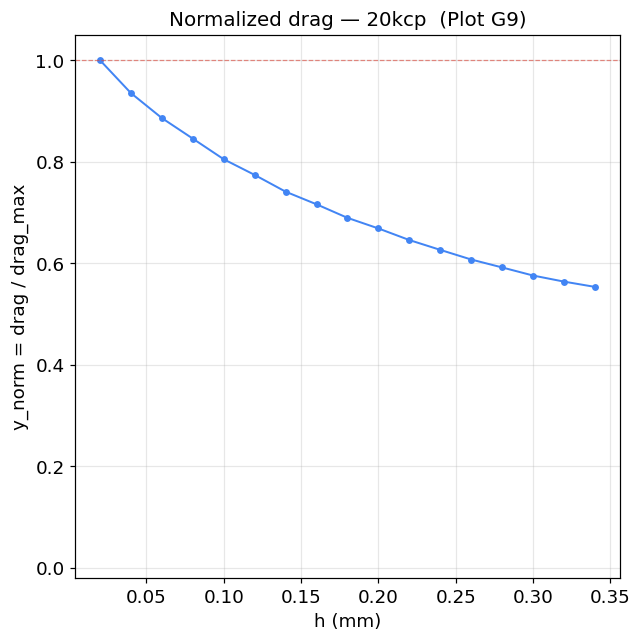

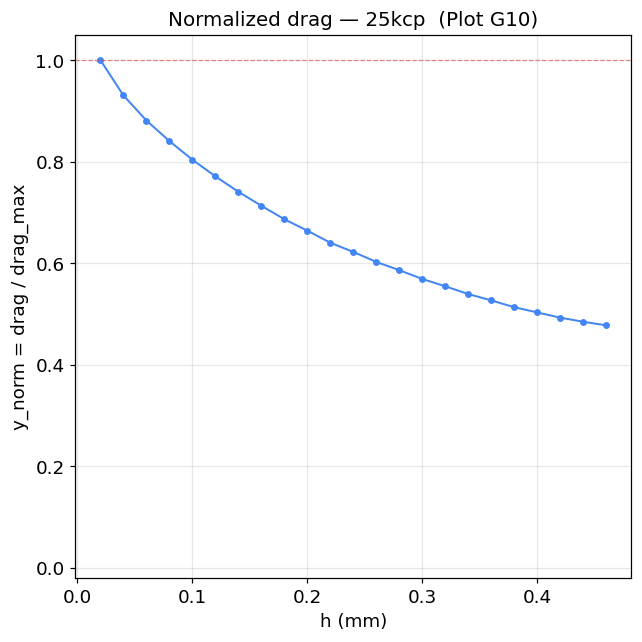

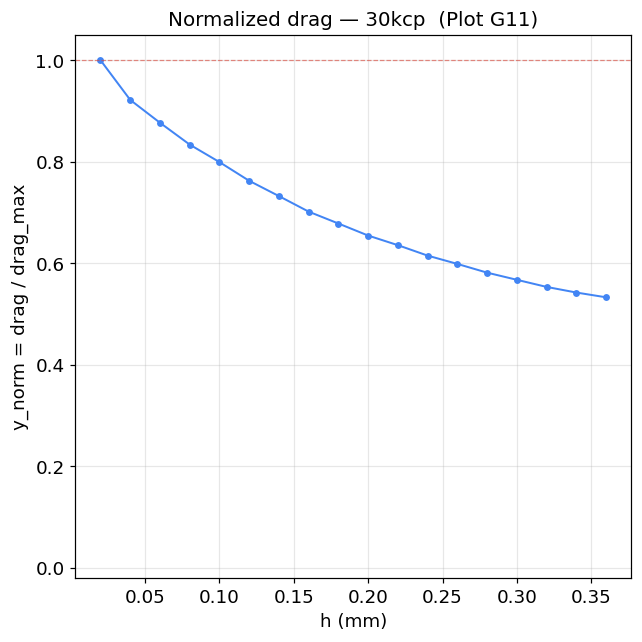

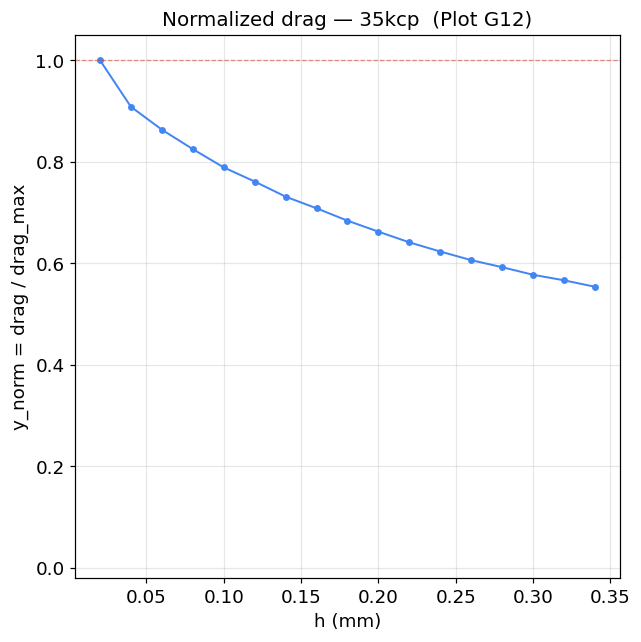

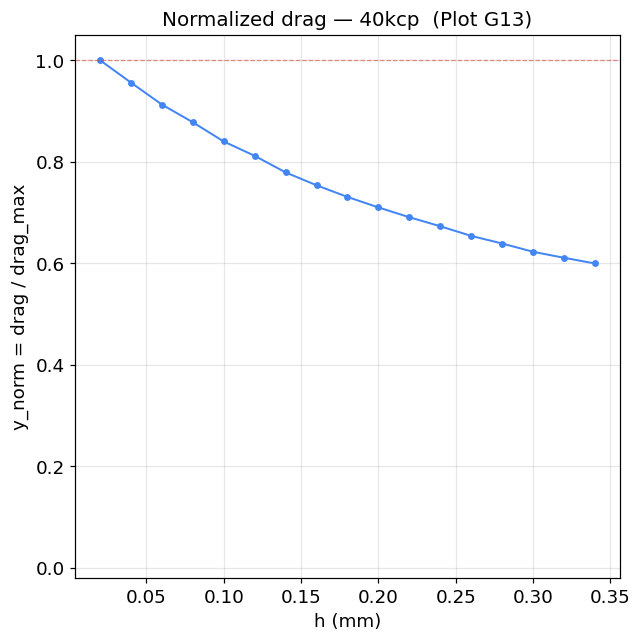

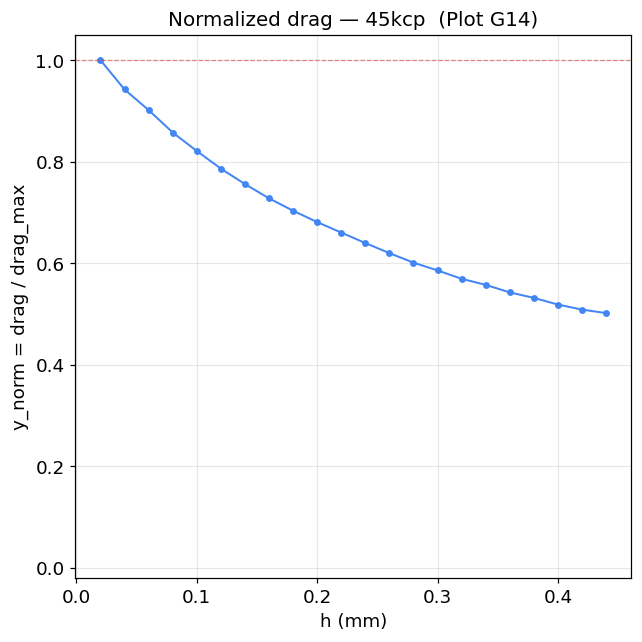

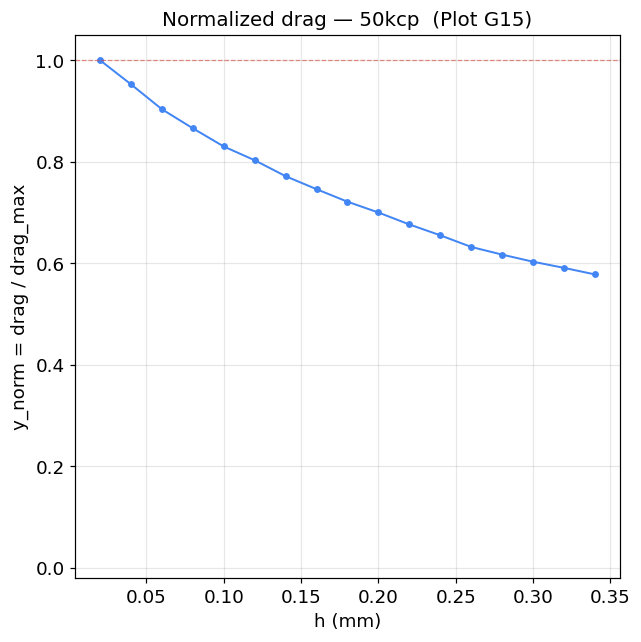

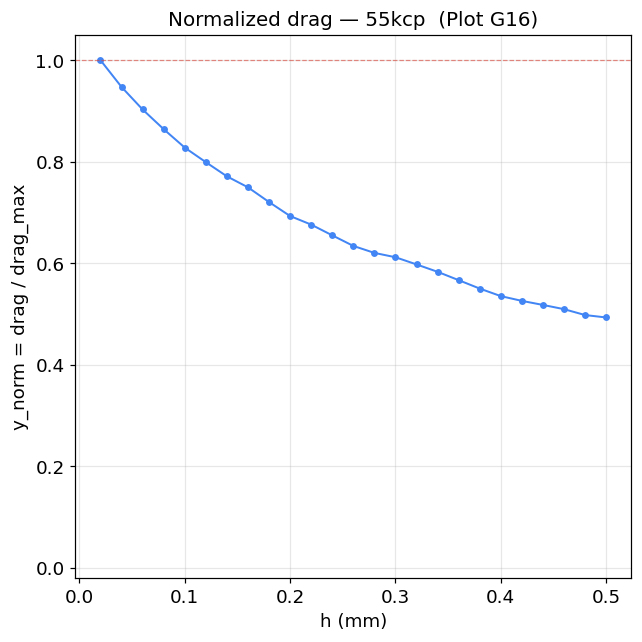

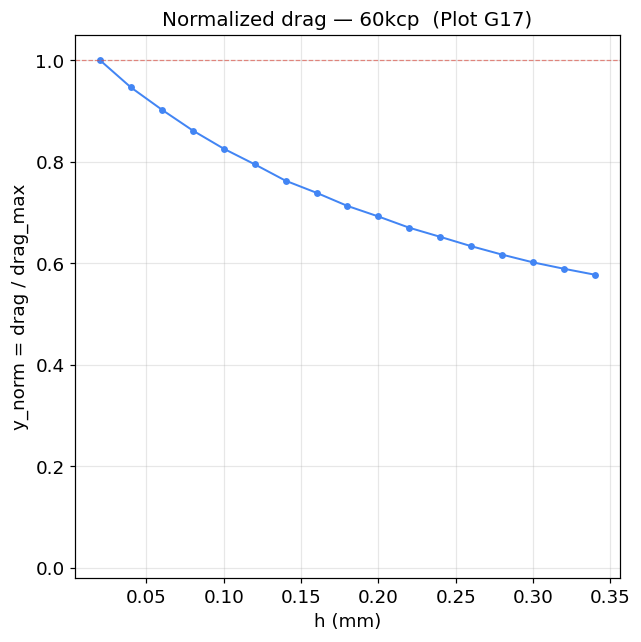

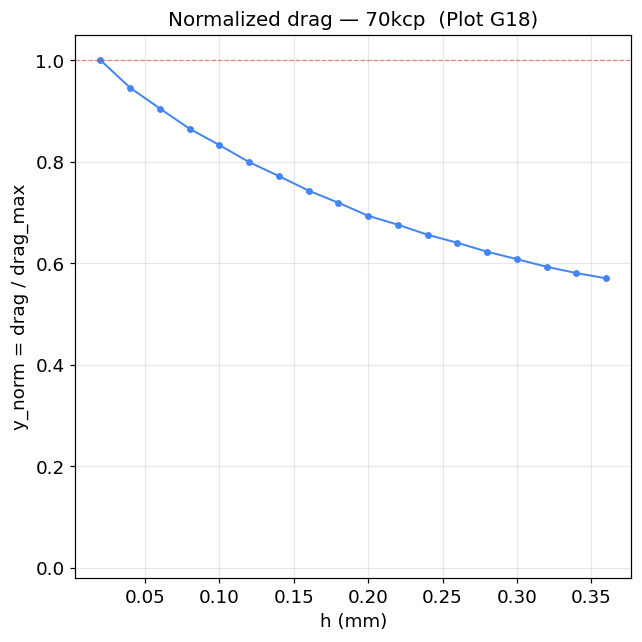

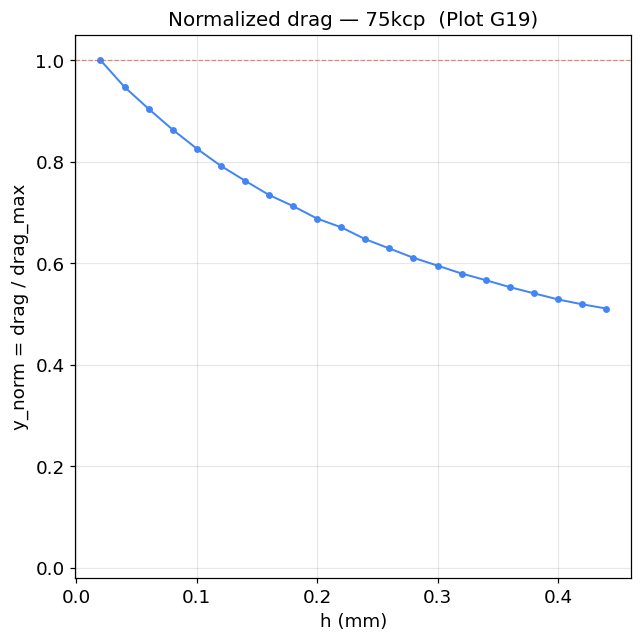

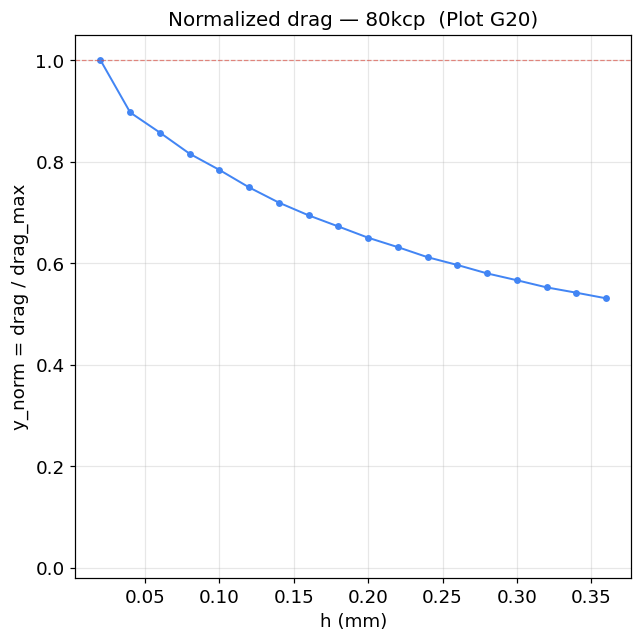

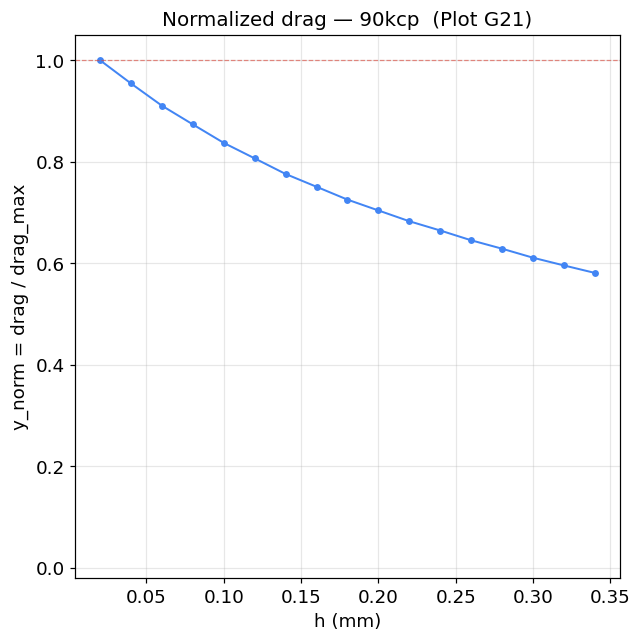

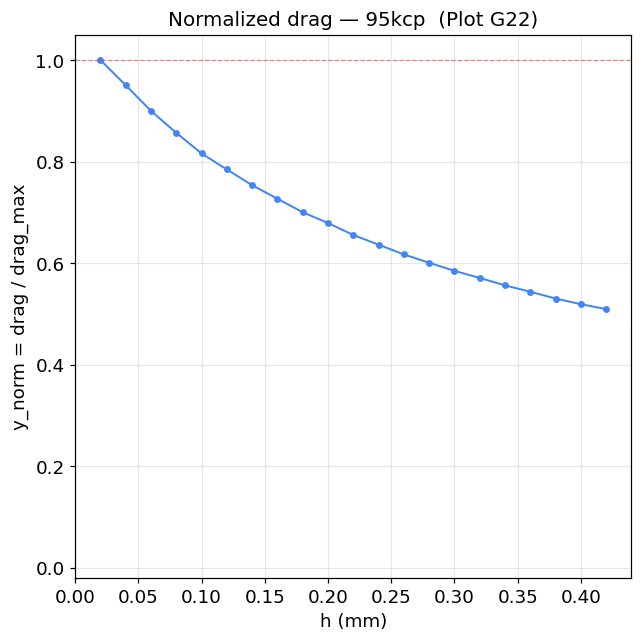

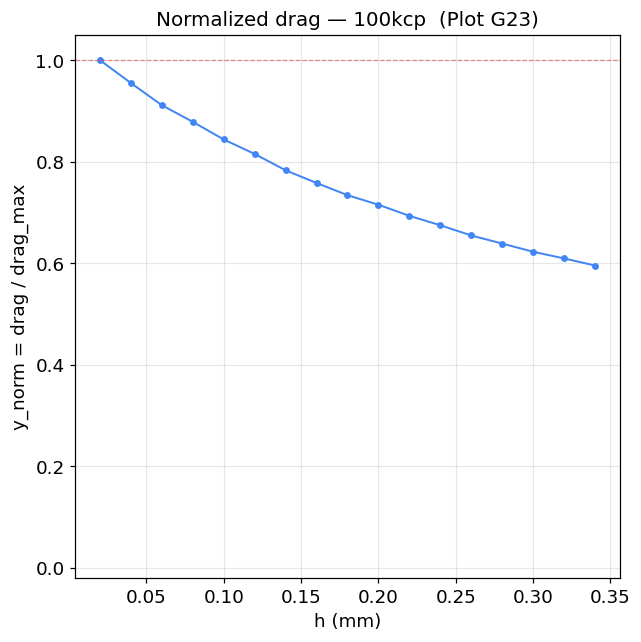

Per-sample normalization summary:


,n_points,h_min_mm,h_max_mm,h_at_drag_max_mm,drag_min,drag_max,drag_mean,y_norm_min,y_norm_mean
sample,,,,,,,,,
1kcp,16,0.02,0.32,0.02,0.7954,1.3939,1.0358,0.5706,0.7431
2kcp,16,0.02,0.32,0.02,2.3760,4.1942,3.0799,0.5665,0.7343
4kcp,21,0.02,0.42,0.02,4.1029,7.8371,5.4830,0.5235,0.6996
5kcp,17,0.02,0.34,0.02,3.9578,7.0089,5.1069,0.5647,0.7286
8kcp,19,0.02,0.38,0.02,6.0429,11.0083,7.8882,0.5489,0.7166
10kcp,21,0.02,0.42,0.02,6.7412,11.9448,8.5992,0.5644,0.7199
12.5kcp,18,0.02,0.36,0.02,9.9581,17.8448,12.8929,0.5580,0.7225
15kcp,11,0.02,0.22,0.02,16.0295,23.3051,19.1467,0.6878,0.8216
20kcp,17,0.02,0.34,0.02,17.1635,31.0063,22.2993,0.5535,0.7192


Saved → outputs_rheology\normalized_drag_summary.csv


In [20]:
# --- Normalized drag per sample — one figure per sample ---
# Plots are labeled G1, G2, ... (one per sample)

samples_sorted = sorted(
    tidy["sample"].unique(),
    key=lambda s: float(str(s).replace("kcp", "")) if str(s).replace("kcp", "").replace(".", "", 1).isdigit() else float("inf"),
)
n = len(samples_sorted)
colors = PALETTE(np.linspace(0, 0.95, n))

summary_rows = []
for i, s in enumerate(samples_sorted):
    sub = tidy[tidy["sample"] == s].sort_values("h_mm").reset_index(drop=True)
    drag = sub["T_over_RPM"].to_numpy()
    h_vals = sub["h_mm"].to_numpy()
    drag_max = float(np.nanmax(drag)) if len(drag) else np.nan
    y_norm = drag / drag_max if drag_max and np.isfinite(drag_max) else drag * np.nan

    # --- Plot G{i+1}: Normalized drag — sample {s} ---
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(h_vals, y_norm, "o-", ms=3.5, lw=1.3, color=colors[i])
    ax.set_title(f"Normalized drag — {s}  (Plot G{i+1})")
    ax.set_xlabel("h (mm)")
    ax.set_ylabel("y_norm = drag / drag_max")
    ax.set_ylim(-0.02, 1.05)
    ax.axhline(1.0, color="grey", lw=0.8, ls="--", alpha=0.6)
    plt.tight_layout()
    save_fig(fig, f"normalized_drag_{s}"); plt.show()

    idx_max = int(np.nanargmax(drag)) if len(drag) else -1
    summary_rows.append({
        "sample": s,
        "n_points": int(len(sub)),
        "h_min_mm": float(np.nanmin(h_vals)) if len(h_vals) else np.nan,
        "h_max_mm": float(np.nanmax(h_vals)) if len(h_vals) else np.nan,
        "h_at_drag_max_mm": float(h_vals[idx_max]) if idx_max >= 0 else np.nan,
        "drag_min": float(np.nanmin(drag)) if len(drag) else np.nan,
        "drag_max": drag_max,
        "drag_mean": float(np.nanmean(drag)) if len(drag) else np.nan,
        "y_norm_min": float(np.nanmin(y_norm)) if len(y_norm) else np.nan,
        "y_norm_mean": float(np.nanmean(y_norm)) if len(y_norm) else np.nan,
    })

# Comparison table
comparison_norm = pd.DataFrame(summary_rows).set_index("sample")
comparison_norm = comparison_norm.round(4)
print("Per-sample normalization summary:")
display(comparison_norm)
comparison_norm.to_csv(OUT_DIR / "normalized_drag_summary.csv")
print(f"Saved → {OUT_DIR / 'normalized_drag_summary.csv'}")


## 13. Universal Master Curve Analysis

Hypothesis: rotational drag factorizes as
$$T(h, \mu) \;=\; A(\mu)\,F(h),$$
so that the **shape** $F(h)$ is set by geometry/contact mechanics and the **amplitude**
$A(\mu)$ carries all the viscosity dependence. If this holds, normalizing every dataset
by its own maximum,
$$y_{\text{norm}}(h) \;=\; \frac{T/\Omega}{\max(T/\Omega)},$$
should collapse all curves onto a single master curve $\tilde F(h) = F(h)/\max F$.

We:

1. overlay all normalized curves on one figure,
2. interpolate each onto a common $h$ grid and compute the **mean ± 95 % band**,
3. fit the mean master curve to three candidate forms — power law $C\,h^{-n}$,
   regularized hyperbola $C/(h+h_c)$, and generalized $C/(h+h_c)^n$,
4. fit **globally** to *all* normalized data simultaneously (joint estimate of $n, h_c$),
5. compare models via RMSE / AIC / BIC and residual diagnostics,
6. evaluate whether $h_c$ is a viscosity-independent geometric length scale by
   contrasting the global $h_c$ with the per-sample $h_c$ values.


C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3820119190.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3820119190.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.1f}" for y in ax.get_yticks()], fontsize=14)


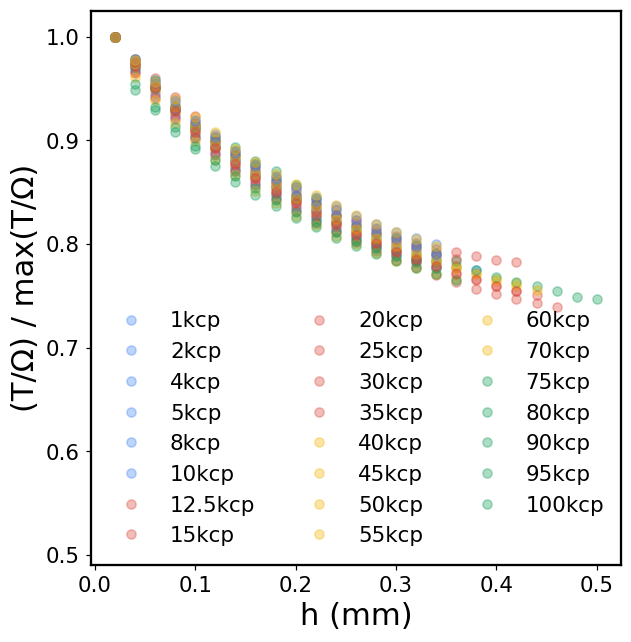

C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3820119190.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\3820119190.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.1f}" for y in ax.get_yticks()], fontsize=14)


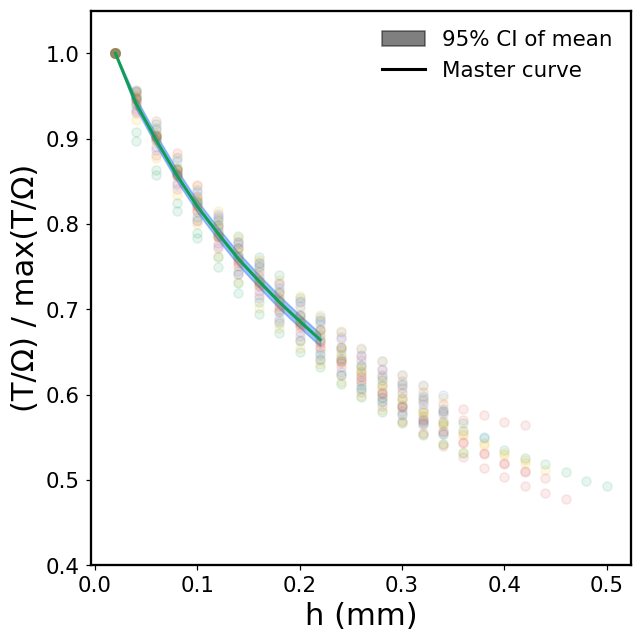

Samples used in collapse : 23
Common h-grid range      : [0.020, 0.220] mm  (200 points)
Collapse quality (mean CV across samples) : 0.021
Collapse quality (max  CV across samples) : 0.027


In [21]:
# --- Build per-sample normalized curves and the common-grid master curve ---
from scipy.interpolate import interp1d

samples_master = sorted(
    tidy["sample"].unique(),
    key=lambda s: float(str(s).replace("kcp", "")) if str(s).replace("kcp", "").replace(".", "", 1).isdigit() else float("inf"),
)

norm_curves = {}   # sample -> (h, y_norm, A_mu = drag_max)
for s in samples_master:
    sub = tidy[tidy["sample"] == s].sort_values("h_mm").reset_index(drop=True)
    h_s = sub["h_mm"].to_numpy(float)
    d_s = sub["T_over_RPM"].to_numpy(float)
    m = np.isfinite(h_s) & np.isfinite(d_s) & (h_s > 0)
    h_s, d_s = h_s[m], d_s[m]
    if len(h_s) < 3:
        continue
    A_mu = float(np.nanmax(d_s))
    norm_curves[s] = (h_s, d_s / A_mu, A_mu)

# Common h-grid over the intersected support so every curve can be interpolated
h_lo = max(np.min(v[0]) for v in norm_curves.values())
h_hi = min(np.max(v[0]) for v in norm_curves.values())
h_grid = np.linspace(h_lo, h_hi, 200)

interp_mat = np.full((len(norm_curves), h_grid.size), np.nan)
labels = list(norm_curves.keys())
for i, s in enumerate(labels):
    h_s, y_s, _ = norm_curves[s]
    f = interp1d(h_s, y_s, kind="linear", bounds_error=False, fill_value=np.nan)
    interp_mat[i] = f(h_grid)

mean_curve = np.nanmean(interp_mat, axis=0)
std_curve  = np.nanstd(interp_mat, axis=0, ddof=1)
n_per_h    = np.sum(np.isfinite(interp_mat), axis=0)
sem_curve  = std_curve / np.sqrt(np.clip(n_per_h, 1, None))
ci95_lo = mean_curve - 1.96 * sem_curve
ci95_hi = mean_curve + 1.96 * sem_curve

# Curve-collapse quality: pointwise CV across samples
cv_pointwise = std_curve / np.where(np.abs(mean_curve) > 1e-12, np.abs(mean_curve), np.nan)
collapse_cv_mean = float(np.nanmean(cv_pointwise))
collapse_cv_max  = float(np.nanmax(cv_pointwise))

colors = PALETTE(np.linspace(0, 0.95, len(labels)))

# --- Plot H1: Overlay of all normalized curves ---
fig, ax = plt.subplots(figsize=(6, 6))
for c, s in zip(colors, labels):
    h_s, y_s, _ = norm_curves[s]
    ax.plot(h_s, y_s, "o-", ms=6, lw=0, color=c, label=s, alpha=0.35)
ax.set_xlabel("h (mm)", fontsize=20); ax.set_ylabel("(T/Ω) / max(T/Ω)", fontsize=20)
ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
ax.set_yticklabels([f"{y:.1f}" for y in ax.get_yticks()], fontsize=14)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.legend(ncol=3, fontsize=14, loc="lower left", frameon=False)
ax.set_ylim(-0.02, 1.05)
ax.grid(False)
plt.tight_layout()
save_fig(fig, "13_master_overlay"); plt.show()

# --- Plot H2: Mean master curve with 95% CI band ---
fig, ax = plt.subplots(figsize=(6, 6))
for c, s in zip(colors, labels):
    h_s, y_s, _ = norm_curves[s]
    ax.plot(h_s, y_s, "o", ms=6, color=c, alpha=0.1)
ax.fill_between(h_grid, ci95_lo, ci95_hi, color="k", alpha=0.5, label="95% CI of mean")
ax.plot(h_grid, mean_curve, "k-", lw=2, label="Master curve")
ax.set_xlabel("h (mm)", fontsize=20); ax.set_ylabel("(T/Ω) / max(T/Ω)", fontsize=20)
ax.legend(loc="upper right", frameon=False)
ax.set_ylim(0.4, 1.05)
ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
ax.set_yticklabels([f"{y:.1f}" for y in ax.get_yticks()], fontsize=14)
ax.legend(loc="upper right", frameon=False, fontsize=14)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.grid(False)
plt.tight_layout()
save_fig(fig, "13_master_mean"); plt.show()

print(f"Samples used in collapse : {len(labels)}")
print(f"Common h-grid range      : [{h_lo:.3f}, {h_hi:.3f}] mm  ({h_grid.size} points)")
print(f"Collapse quality (mean CV across samples) : {collapse_cv_mean:.3f}")
print(f"Collapse quality (max  CV across samples) : {collapse_cv_max:.3f}")


In [22]:
# --- Global fit of F(h) to all normalized data simultaneously --------------
# Models for the master curve shape F(h) (normalized, dimensionless):
def F_power(h, C, n):           return C * np.asarray(h, float) ** (-n)
def F_reghyp(h, C, hc):         return C / (np.asarray(h, float) + hc)
def F_genreg(h, C, hc, n):      return C / (np.asarray(h, float) + hc) ** n

MASTER_MODELS = {
    "power":          dict(func=F_power,   p0=[1.0, 1.0],          bounds=([1e-6, 0.1],          [1e6, 5.0])),
    "regularized":    dict(func=F_reghyp,  p0=[1.0, 0.05],         bounds=([1e-6, 1e-6],         [1e6, 10.0])),
    "gen_regularized":dict(func=F_genreg,  p0=[1.0, 0.05, 1.0],    bounds=([1e-6, 1e-6, 0.1],    [1e6, 10.0, 5.0])),
}
MASTER_PNAMES = {"power": ["C", "n"], "regularized": ["C", "h_c"], "gen_regularized": ["C", "h_c", "n"]}

# Pool all (h, y_norm) pairs from every sample for a true global fit
h_all = np.concatenate([v[0] for v in norm_curves.values()])
y_all = np.concatenate([v[1] for v in norm_curves.values()])
sample_all = np.concatenate([np.full(v[0].size, s) for s, v in norm_curves.items()])
ord_ = np.argsort(h_all)
h_all, y_all, sample_all = h_all[ord_], y_all[ord_], sample_all[ord_]
print(f"Global fit pool: {len(h_all)} points from {len(norm_curves)} samples")

def fit_master(name, h, y):
    spec = MASTER_MODELS[name]
    popt, pcov = optimize.curve_fit(spec["func"], h, y, p0=spec["p0"],
                                    bounds=spec["bounds"], maxfev=40000)
    return popt, pcov

def metrics_master(name, popt, h, y):
    yhat = MASTER_MODELS[name]["func"](h, *popt)
    r = y - yhat
    n_obs, k = len(y), len(popt)
    rss = float(np.sum(r ** 2))
    rmse = float(np.sqrt(rss / n_obs))
    sigma2 = rss / n_obs
    aic = n_obs * np.log(sigma2 + 1e-30) + 2 * k
    bic = n_obs * np.log(sigma2 + 1e-30) + k * np.log(n_obs)
    return dict(n=n_obs, k=k, RMSE=rmse, AIC=aic, BIC=bic), r, yhat

# Global fits + bootstrap CIs
rng = np.random.default_rng(0)
N_BOOT = 300
global_fits = {}
for name in MASTER_MODELS:
    popt, pcov = fit_master(name, h_all, y_all)
    boots = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, len(h_all), len(h_all))
        try:
            p, _ = fit_master(name, h_all[idx], y_all[idx])
            boots.append(p)
        except Exception:
            pass
    boots = np.array(boots) if boots else np.empty((0, len(popt)))
    ci_lo = np.nanpercentile(boots, 2.5,  axis=0) if boots.size else np.full_like(popt, np.nan)
    ci_hi = np.nanpercentile(boots, 97.5, axis=0) if boots.size else np.full_like(popt, np.nan)
    m, r, yhat = metrics_master(name, popt, h_all, y_all)
    global_fits[name] = dict(popt=popt, pcov=pcov, boot=boots,
                             ci_lo=ci_lo, ci_hi=ci_hi, metrics=m, resid=r, yhat=yhat)

# Parameter table
param_rows = []
for name, info in global_fits.items():
    for pname, v, lo, hi in zip(MASTER_PNAMES[name], info["popt"], info["ci_lo"], info["ci_hi"]):
        param_rows.append({"model": name, "param": pname, "value": v,
                           "ci95_lo": lo, "ci95_hi": hi})
param_table = pd.DataFrame(param_rows).set_index(["model", "param"]).round(5)
print("Global parameter estimates (95% bootstrap CIs):")
display(param_table)

# Model comparison table
cmp_rows = {name: info["metrics"] for name, info in global_fits.items()}
cmp_table = pd.DataFrame(cmp_rows).T.sort_values("AIC")
cmp_table["ΔAIC"] = cmp_table["AIC"] - cmp_table["AIC"].min()
cmp_table["ΔBIC"] = cmp_table["BIC"] - cmp_table["BIC"].min()
print("Model comparison on the universal master curve:")
display(cmp_table.round(4))

best_master = cmp_table.index[0]
print(f"Best master-curve model (AIC): {best_master}")

# Save outputs
param_table.to_csv(OUT_DIR / "master_curve_params.csv")
cmp_table.to_csv(OUT_DIR / "master_curve_model_comparison.csv")


Global fit pool: 425 points from 23 samples
Global parameter estimates (95% bootstrap CIs):


value  ci95_lo  ci95_hi
model           param                           
power           C      0.48197  0.47338  0.48914
                n      0.20651  0.19943  0.21555
regularized     C      0.41572  0.41039  0.42148
                h_c    0.40263  0.39617  0.40997
gen_regularized C      0.38382  0.38101  0.38721
                h_c    0.20422  0.17916  0.23814
                n      0.63894  0.59193  0.70469

Model comparison on the universal master curve:


,n,k,RMSE,AIC,BIC,ΔAIC,ΔBIC
gen_regularized,425.0,3.0,0.0165,-3484.6842,-3472.5279,0.0000,0.0000
regularized,425.0,2.0,0.0178,-3420.5673,-3412.4631,64.1169,60.0648
power,425.0,2.0,0.0400,-2731.3733,-2723.2692,753.3108,749.2587


Best master-curve model (AIC): gen_regularized


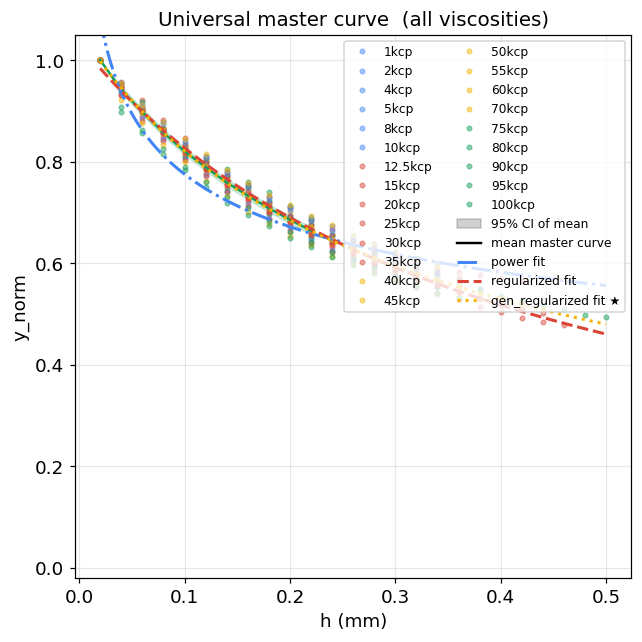

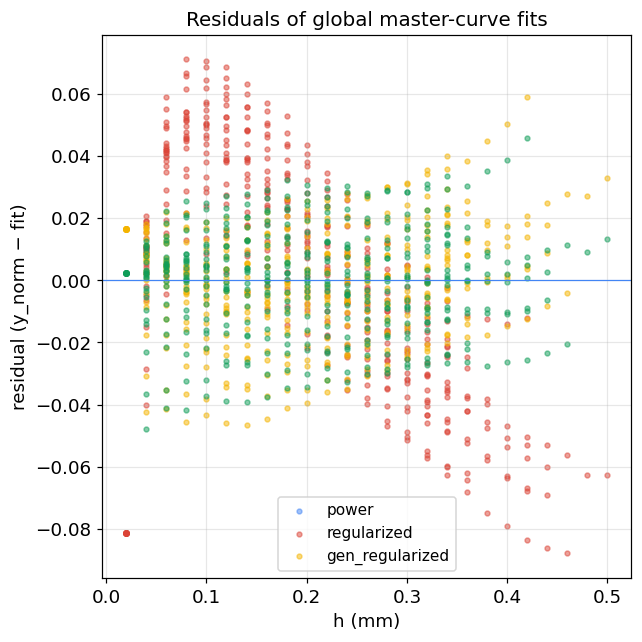

Per-sample h_c (regularized model):


,C,h_c,C_se,h_c_se
sample,,,,
1kcp,0.39728,0.38049,0.00298,0.00373
2kcp,0.38806,0.37454,0.00485,0.00613
4kcp,0.41915,0.40356,0.00437,0.00566
5kcp,0.39142,0.37510,0.00717,0.00908
8kcp,0.41723,0.40290,0.00581,0.00744
10kcp,0.46798,0.45272,0.00899,0.01148
12.5kcp,0.41150,0.39849,0.00600,0.00766
15kcp,0.45231,0.43782,0.01326,0.01563
20kcp,0.38191,0.36914,0.00600,0.00768


Global h_c        : 0.4026 mm   (95% CI [0.3962, 0.4100])
Per-sample h_c    : mean = 0.4033 mm,  std = 0.0274,  CV = 0.068


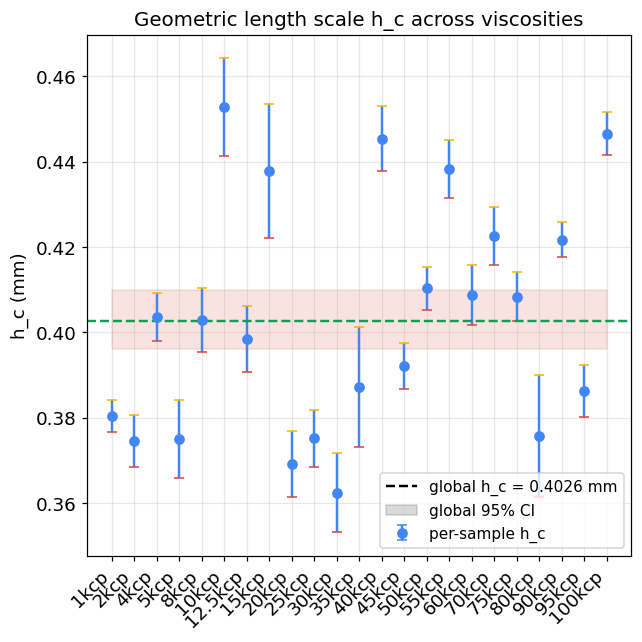

In [23]:
# --- Publication figure: master curve + best global fit ---
hh = np.linspace(h_all.min(), h_all.max(), 400)
colors = PALETTE(np.linspace(0, 0.95, len(norm_curves)))

# --- Plot H3: Universal master curve with all model fits ---
fig, ax = plt.subplots(figsize=(6, 6))
for c, (s, (h_s, y_s, _)) in zip(colors, norm_curves.items()):
    ax.plot(h_s, y_s, "o", ms=3, color=c, alpha=0.45, label=s)
ax.fill_between(h_grid, ci95_lo, ci95_hi, color="k", alpha=0.18, label="95% CI of mean")
ax.plot(h_grid, mean_curve, "k-", lw=1.6, label="mean master curve")
for nm, ls in zip(MASTER_MODELS, ["-.", "--", ":"]):
    yh = MASTER_MODELS[nm]["func"](hh, *global_fits[nm]["popt"])
    ax.plot(hh, yh, ls, lw=2,
            label=f"{nm} fit" + (" ★" if nm == best_master else ""))
ax.set_xlabel("h (mm)"); ax.set_ylabel("y_norm")
ax.set_title("Universal master curve  (all viscosities)")
ax.set_ylim(-0.02, 1.05)
ax.legend(ncol=2, fontsize=8, loc="upper right")
plt.tight_layout()
save_fig(fig, "13_master_publication_fit"); plt.show()

# --- Plot H4: Residuals of global master-curve fits ---
fig, ax = plt.subplots(figsize=(6, 6))
for nm, c in zip(MASTER_MODELS, ["C0", "C1", "C2"]):
    ax.scatter(h_all, global_fits[nm]["resid"], s=10, color=c, alpha=0.5, label=nm)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("h (mm)"); ax.set_ylabel("residual (y_norm − fit)")
ax.set_title("Residuals of global master-curve fits")
ax.legend()
plt.tight_layout()
save_fig(fig, "13_master_publication_resid"); plt.show()

# --- Is h_c viscosity-independent? Compare global h_c with per-sample h_c ---
per_sample_hc = []
for s, (h_s, y_s, _) in norm_curves.items():
    try:
        p, pc = fit_master("regularized", h_s, y_s)
        se = np.sqrt(np.diag(pc))
        per_sample_hc.append({"sample": s, "C": p[0], "h_c": p[1],
                              "C_se": se[0], "h_c_se": se[1]})
    except Exception:
        per_sample_hc.append({"sample": s, "C": np.nan, "h_c": np.nan,
                              "C_se": np.nan, "h_c_se": np.nan})
hc_table = pd.DataFrame(per_sample_hc).set_index("sample").round(5)
global_hc = global_fits["regularized"]["popt"][1]
global_hc_lo = global_fits["regularized"]["ci_lo"][1]
global_hc_hi = global_fits["regularized"]["ci_hi"][1]

print(f"Per-sample h_c (regularized model):")
display(hc_table)
hc_table.to_csv(OUT_DIR / "master_curve_hc_per_sample.csv")

mean_hc = float(np.nanmean(hc_table["h_c"]))
std_hc  = float(np.nanstd(hc_table["h_c"], ddof=1))
cv_hc   = std_hc / abs(mean_hc) if mean_hc else np.nan
print(f"Global h_c        : {global_hc:.4f} mm   (95% CI [{global_hc_lo:.4f}, {global_hc_hi:.4f}])")
print(f"Per-sample h_c    : mean = {mean_hc:.4f} mm,  std = {std_hc:.4f},  CV = {cv_hc:.3f}")

# --- Plot H5: Geometric length scale h_c across viscosities ---
fig, ax = plt.subplots(figsize=(6, 6))
xs = np.arange(len(hc_table))
ax.errorbar(xs, hc_table["h_c"], yerr=hc_table["h_c_se"], fmt="o", color="C0",
            capsize=3, label="per-sample h_c")
ax.axhline(global_hc, color="k", ls="--", label=f"global h_c = {global_hc:.4f} mm")
ax.fill_between(xs, global_hc_lo, global_hc_hi, color="k", alpha=0.15, label="global 95% CI")
ax.set_xticks(xs); ax.set_xticklabels(hc_table.index, rotation=45, ha="right")
ax.set_ylabel("h_c (mm)")
ax.set_title("Geometric length scale h_c across viscosities")
ax.legend()
plt.tight_layout()
save_fig(fig, "13_hc_across_samples"); plt.show()


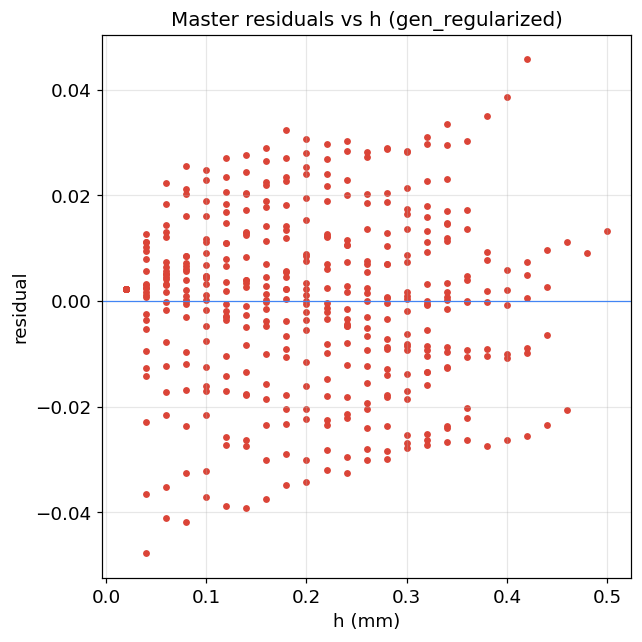

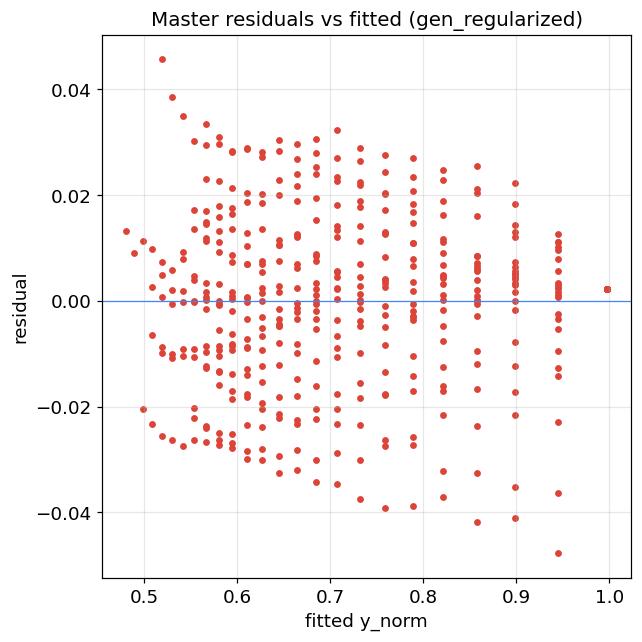

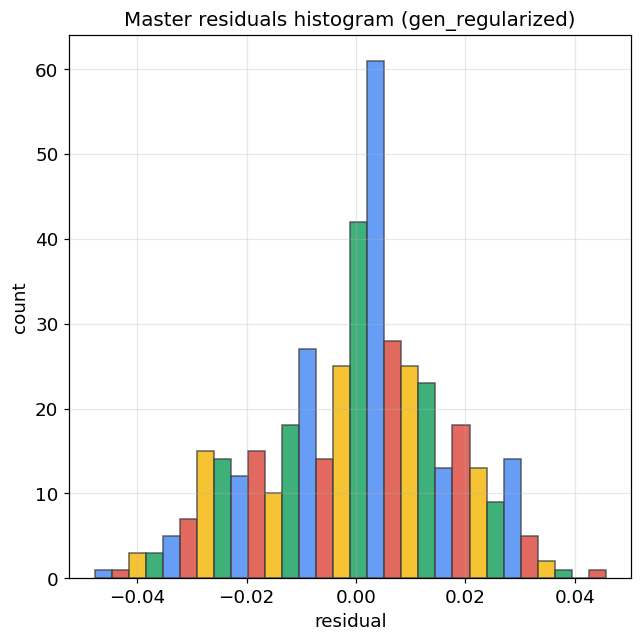

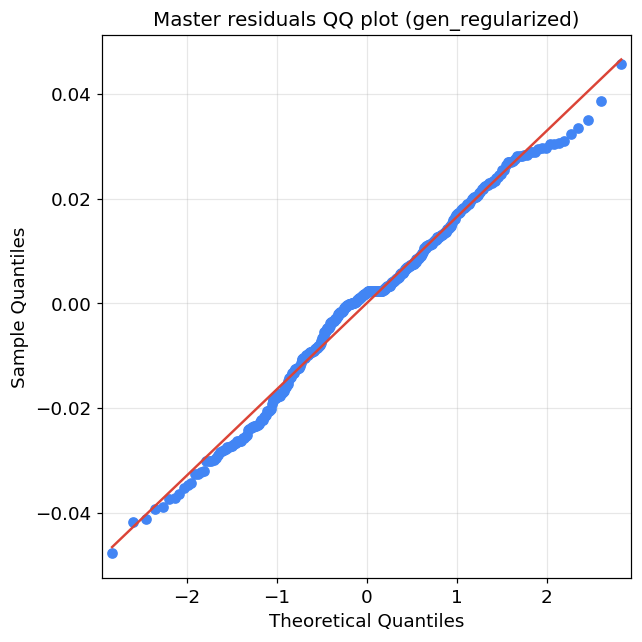

Residual diagnostics for best master model (gen_regularized):
  mean       -0.0000
  std        +0.0165
  skew       -0.2323
  kurtosis   -0.2102

UNIVERSAL MASTER CURVE — INTERPRETATION
• Number of viscosity samples pooled : 23
• Curve-collapse quality (mean pointwise CV): 0.021
  → Collapse is GOOD (< 0.10): factorization T(h,μ) = A(μ)·F(h) is consistent with the data.
• Best global master-curve model      : gen_regularized  (ΔAIC over runner-up = 64.12)
• Global geometric length scale h_c   : 204.2 µm  (95% CI [179.2, 238.1] µm)
• Global exponent n                  : 0.639  (95% CI [0.592, 0.705])
• Per-sample h_c spread (regularized) : mean = 403.3 µm, CV = 0.07
  → h_c is VISCOSITY-INDEPENDENT (geometric) (criterion: CV(h_c) < 0.25).

Conclusion:
  The platform follows T(h,μ) ≈ A(μ)·F(h) to good approximation, with a universal master curve well described by the gen_regularized form and a viscosity-independent geometric length scale h_c. All viscosity information is carried by the 

In [24]:
# --- Residual diagnostics for the best global master-curve model -----------
best_info = global_fits[best_master]
r_best = best_info["resid"]
yhat_best = best_info["yhat"]

# --- Plot H6: Master residuals vs h ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(h_all, r_best, s=12, c="C0"); ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("h (mm)"); ax.set_ylabel("residual")
ax.set_title(f"Master residuals vs h ({best_master})")
plt.tight_layout()
save_fig(fig, "13_master_resid_vs_h"); plt.show()

# --- Plot H7: Master residuals vs fitted ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yhat_best, r_best, s=12, c="C0"); ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("fitted y_norm"); ax.set_ylabel("residual")
ax.set_title(f"Master residuals vs fitted ({best_master})")
plt.tight_layout()
save_fig(fig, "13_master_resid_vs_fitted"); plt.show()

# --- Plot H8: Master residuals histogram ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(r_best, bins=30, color="C0", alpha=0.8, edgecolor="k")
ax.set_xlabel("residual"); ax.set_ylabel("count")
ax.set_title(f"Master residuals histogram ({best_master})")
plt.tight_layout()
save_fig(fig, "13_master_resid_hist"); plt.show()

# --- Plot H9: Master residuals QQ plot ---
fig, ax = plt.subplots(figsize=(6, 6))
sm.qqplot(r_best, line="s", ax=ax)
ax.set_title(f"Master residuals QQ plot ({best_master})")
plt.tight_layout()
save_fig(fig, "13_master_resid_qq"); plt.show()

resid_stats = {
    "mean": float(np.mean(r_best)),
    "std": float(np.std(r_best, ddof=1)),
    "skew": float(stats.skew(r_best)),
    "kurtosis": float(stats.kurtosis(r_best)),
}
print(f"Residual diagnostics for best master model ({best_master}):")
for k, v in resid_stats.items():
    print(f"  {k:<10s} {v:+.4f}")

# --- Final interpretation -------------------------------------------------
hc_independent = (cv_hc < 0.25) and np.isfinite(global_hc)
collapse_ok = collapse_cv_mean < 0.10

print("\n" + "=" * 72)
print("UNIVERSAL MASTER CURVE — INTERPRETATION")
print("=" * 72)
print(f"• Number of viscosity samples pooled : {len(norm_curves)}")
print(f"• Curve-collapse quality (mean pointwise CV): {collapse_cv_mean:.3f}")
print(f"  → Collapse is {'GOOD (< 0.10)' if collapse_ok else 'WEAK (≥ 0.10)'}: "
      f"factorization T(h,μ) = A(μ)·F(h) is "
      f"{'consistent with the data.' if collapse_ok else 'only partially supported.'}")
print(f"• Best global master-curve model      : {best_master}  "
      f"(ΔAIC over runner-up = {cmp_table['ΔAIC'].iloc[1]:.2f})")
if "h_c" in MASTER_PNAMES[best_master]:
    idx_hc = MASTER_PNAMES[best_master].index("h_c")
    hc_val = best_info["popt"][idx_hc]
    hc_lo, hc_hi = best_info["ci_lo"][idx_hc], best_info["ci_hi"][idx_hc]
    print(f"• Global geometric length scale h_c   : {hc_val*1000:.1f} µm  "
          f"(95% CI [{hc_lo*1000:.1f}, {hc_hi*1000:.1f}] µm)")
if "n" in MASTER_PNAMES[best_master]:
    idx_n = MASTER_PNAMES[best_master].index("n")
    n_val = best_info["popt"][idx_n]
    n_lo, n_hi = best_info["ci_lo"][idx_n], best_info["ci_hi"][idx_n]
    print(f"• Global exponent n                  : {n_val:.3f}  "
          f"(95% CI [{n_lo:.3f}, {n_hi:.3f}])")
print(f"• Per-sample h_c spread (regularized) : mean = {mean_hc*1000:.1f} µm, "
      f"CV = {cv_hc:.2f}")
print(f"  → h_c is {'VISCOSITY-INDEPENDENT (geometric)' if hc_independent else 'viscosity-DEPENDENT (not purely geometric)'} "
      f"(criterion: CV(h_c) < 0.25).")

print("\nConclusion:")
if collapse_ok and hc_independent:
    print("  The platform follows T(h,μ) ≈ A(μ)·F(h) to good approximation, with a "
          "universal master curve well described by the "
          f"{best_master} form and a viscosity-independent geometric length scale h_c. "
          "All viscosity information is carried by the amplitude A(μ).")
elif collapse_ok:
    print("  Curve collapse supports the factorization T(h,μ) = A(μ)·F(h), but h_c "
          "varies with viscosity, suggesting that the effective contact offset is "
          "modulated by fluid properties (slip layer, compliance, shear-thinning).")
else:
    print("  Curve collapse is imperfect: a single universal F(h) does not fully "
          "describe all samples. The data are consistent with viscosity-dependent "
          "geometry parameters; treat h_c and n as sample-specific.")
print("=" * 72)


## 14. Generalisation to Non-Newtonian Fluids — Multi-RPM Flow-Curve Extension

The silicone calibration of Section 12 maps a single fitted amplitude $A$ to a single
viscosity $\mu$. That mapping is exact for Newtonian fluids but mis-estimates
non-Newtonian samples by 30–650 % because $A$ then carries an *apparent* viscosity
at the test shear rate plus, for elastic polymer solutions, a first-normal-stress
contribution.

The new datasets in `Polymers/` finally provide what was missing: **multi-RPM ladders
(4 distinct RPMs per cell)** on representative shear-thinning fluids — Carbopol 980
(0.3 % and 0.4 %), PEG-300K and PEG-600K (5 % and 10 %), Sepineo P-600 (2 %), and
Solagum (2 % and 3 %). With ≥3 RPMs per sample the model can now resolve a true
**power-law flow curve** per fluid:

$$D(h, \dot\gamma) \;=\; A(\dot\gamma)\,F(h) \quad\text{with}\quad
   A(\dot\gamma) \;=\; A_0\,\dot\gamma^{\,n-1}.$$

Here $F(h)=1/(h+h_c)$ is the *universal* geometric factor established in Section 13
(and validated to ±5 % on silicones), $n$ is the flow-behaviour index ($n=1$ Newtonian,
$n<1$ shear-thinning, $n>1$ shear-thickening), and $K = A_0\cdot(\partial T/\partial A)$
plays the role of the consistency index. The apparent viscosity at any shear rate is
then $\eta_\text{app}(\dot\gamma) = K\,\dot\gamma^{\,n-1}$, and the labelled
manufacturer / low-shear value is recovered as $\eta_0 = \lim_{\dot\gamma\to\dot\gamma_\text{ref}} \eta_\text{app}$.

The remainder of this section:

1. parses the four polymer CSVs (with sentinel-row cleaning, hit-point recovery
   $h = Z - Z_\min$, and dominant-RPM filtering per sweep);
2. extracts a per-RPM amplitude $A(\dot\gamma)$ for each cell × RPM combination;
3. fits the log-log power law $\ln A = \ln A_0 + (n-1)\ln\dot\gamma$ per multi-RPM
   sample to recover $(n, A_0)$;
4. converts to true viscosity via the silicone calibration
   $\mu = (A/k)^{1/p}$ and reports parity vs labelled $\mu_\text{true}$ at each
   sample's *lowest* shear rate (closest to the manufacturer reference);
5. produces publication figures: $D(h)$ at each RPM, the amplitude flow curve
   $A(\dot\gamma)$, and the resulting $\eta_\text{app}(\dot\gamma)$.


In [25]:
# =============================================================================
# 14.1  Constants, label parser, polymer loader
# =============================================================================
from pathlib import Path
import re
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy import stats
import matplotlib.pyplot as plt

# --- geometry (cone-plate) ---------------------------------------------------
R_CONE_MM        = 12.0
CONE_ANGLE_DEG   = 3.0
CONE_ANGLE_RAD   = np.deg2rad(CONE_ANGLE_DEG)
def shear_rate(rpm):                      # γ̇ = ω/α
    return 2.0*np.pi*np.asarray(rpm, float) / (60.0 * CONE_ANGLE_RAD)

# --- universal length scale & silicone amplitude calibration ----------------
# Prefer in-kernel calibrated values from §13; otherwise use validated v3 values.
H_C_UNIVERSAL = float(globals().get("global_hc", 0.2504))   # mm
SILICONE_K    = float(globals().get("silicone_k",   5.087e-9))   # A = k * mu^p
SILICONE_P    = float(globals().get("silicone_p",   2.007))      # μ in cP
print(f"[§14] h_c = {H_C_UNIVERSAL:.4f} mm   |   silicone calibration: "
      f"A = {SILICONE_K:.3e} · μ^{SILICONE_P:.3f}")

# --- where to look for polymer CSVs -----------------------------------------
HERE          = Path.cwd()
POLYMERS_DIR  = next((p for p in [HERE/"Polymers",
                                  HERE/"results/Auto-runs/Polymers",
                                  Path(__file__).parent/"Polymers" if "__file__" in dir() else HERE]
                      if p.exists()), HERE/"Polymers")
print(f"[§14] polymers dir: {POLYMERS_DIR}")

# ---------------------------------------------------------------------------
# label parser
#   recognised label patterns
#     980carb0.3%                       -> ('Carbopol-980', '0.3%', None)
#     1%sep_2.148 / 2%sep_50.11         -> ('Sepineo', '1%', 2148)  (μ in cP)
#     Sep2%                             -> ('Sepineo', '2%', None)
#     1%sola_0.522 / Sola3%             -> ('Solagum',  '1%', 522)
#     5%300K_0.577 / 300KPEG5%          -> ('PEG-300K', '5%', 577)
#     6.5%600K_4.109 / 600KPEG10%       -> ('PEG-600K', '6.5%', 4109)
#   trailing _<float> is μ_true in kcP (multiply by 1000).
# ---------------------------------------------------------------------------
_re_pct   = re.compile(r"(\d+(?:\.\d+)?)\s*%")
_re_tail  = re.compile(r"_(\d+(?:\.\d+)?)$")
_re_peg   = re.compile(r"(300|600)\s*[Kk]")

def parse_polymer_label(label, source_hint=None):
    s = str(label).strip()
    # μ_true from trailing _<kcP>
    mu_true = None
    m = _re_tail.search(s)
    if m:
        mu_true = float(m.group(1)) * 1000.0    # kcP -> cP
        s_clean = s[:m.start()]
    else:
        s_clean = s
    lo = s_clean.lower()
    # concentration
    mp = _re_pct.search(s_clean)
    conc = f"{float(mp.group(1)):g}%" if mp else None
    # family
    if "carb" in lo:
        fam = "Carbopol-980"
    elif "sep"  in lo:
        fam = "Sepineo"
    elif "sola" in lo:
        fam = "Solagum"
    elif (mk := _re_peg.search(s_clean)):
        fam = f"PEG-{mk.group(1)}K"
    elif source_hint:
        fam = source_hint                    # bare "1%" etc. -> fall back to file hint
    else:
        fam = "Unknown"
    return {"family": fam, "conc": conc, "true_cP": mu_true}

# quick self-test
for lab in ["980carb0.3%", "1%sep_2.148", "Sep2%", "1%sola_0.522", "Sola3%",
            "5%300K_0.577", "300KPEG10%", "6.5%600K_4.109", "600KPEG5%"]:
    print(f"  {lab:24s} -> {parse_polymer_label(lab)}")


[§14] h_c = 0.4026 mm   |   silicone calibration: A = 5.087e-09 · μ^2.007
[§14] polymers dir: c:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\results\Auto-runs\Polymers
  980carb0.3%              -> {'family': 'Carbopol-980', 'conc': '0.3%', 'true_cP': None}
  1%sep_2.148              -> {'family': 'Sepineo', 'conc': '1%', 'true_cP': 2148.0}
  Sep2%                    -> {'family': 'Sepineo', 'conc': '2%', 'true_cP': None}
  1%sola_0.522             -> {'family': 'Solagum', 'conc': '1%', 'true_cP': 522.0}
  Sola3%                   -> {'family': 'Solagum', 'conc': '3%', 'true_cP': None}
  5%300K_0.577             -> {'family': 'PEG-300K', 'conc': '5%', 'true_cP': 577.0}
  300KPEG10%               -> {'family': 'PEG-300K', 'conc': '10%', 'true_cP': None}
  6.5%600K_4.109           -> {'family': 'PEG-600K', 'conc': '6.5%', 'true_cP': 4109.0}
  600KPEG5%                -> {'family': 'PEG-600K', 'conc': '5%', 'true_cP': None}


In [26]:
# =============================================================================
# 14.2  Load all polymer CSVs into a tidy long table (per cell × RPM sweep)
# =============================================================================
POLYMER_FILES = {
    "Carbopol-980": POLYMERS_DIR / "all_carbopol.csv",
    "PEG"         : POLYMERS_DIR / "all_PEG.csv",      # mixed 300K / 600K
    "Sepineo"     : POLYMERS_DIR / "all_sepineo.csv",
    "Solagum"     : POLYMERS_DIR / "all_solagum.csv",
}
MIN_RPM_PTS = 6   # minimum number of valid (h, D) samples to attempt an A-fit

def _clean_numeric(df):
    for c in ("Torque_%", "Rotational_Drag", "Elapsed_Time_s", "Z_Height_mm", "RPM"):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def _dominant_rpm(rpms):
    vc = pd.Series(np.round(rpms.dropna().values, 3)).value_counts()
    return float(vc.idxmax()) if not vc.empty else np.nan

def load_polymer_file(path, source_hint):
    raw = pd.read_csv(path)
    raw = _clean_numeric(raw)
    if "Cell_Label" not in raw.columns:
        raise ValueError(f"{path.name}: missing Cell_Label column")
    out = []
    # group by cell identity, then by rounded RPM ladder within each cell
    grp_cols = [c for c in ("row", "cell", "Cell_Label") if c in raw.columns]
    for keys, g in raw.groupby(grp_cols):
        label = keys[-1] if isinstance(keys, tuple) else keys
        meta  = parse_polymer_label(label, source_hint=source_hint)
        g = g.dropna(subset=["Rotational_Drag", "Torque_%", "Z_Height_mm", "RPM"])
        if g.empty:
            continue
        # split sweep by *dominant* RPM in each contiguous height window:
        # simplest: round RPM to 2 dp and treat each unique value as one sweep.
        g = g.assign(_rpm_b=g["RPM"].round(2))
        for rpm_val, gg in g.groupby("_rpm_b"):
            if len(gg) < MIN_RPM_PTS:
                continue
            # keep only the rows whose instantaneous RPM matches the bucket
            # (filters out instrument auto-shifts at near-contact)
            keep = np.isclose(gg["RPM"].values, rpm_val, rtol=0, atol=0.05)
            gg = gg.loc[keep]
            if len(gg) < MIN_RPM_PTS:
                continue
            gg = gg.sort_values("Z_Height_mm")
            h  = gg["Z_Height_mm"].values - gg["Z_Height_mm"].min()
            D  = (gg["Torque_%"].values / max(rpm_val, 1e-9))     # T/RPM
            out.append(pd.DataFrame({
                "source"   : source_hint,
                "label"    : label,
                "family"   : meta["family"],
                "conc"     : meta["conc"],
                "true_cP"  : meta["true_cP"],
                "rpm"      : rpm_val,
                "shear_rate": shear_rate(rpm_val),
                "h_mm"     : h,
                "torque_pct": gg["Torque_%"].values,
                "drag"     : gg["Rotational_Drag"].values,
                "D"        : D,
            }))
    if not out:
        return pd.DataFrame()
    df = pd.concat(out, ignore_index=True)
    # build a stable fluid_id
    df["fluid_id"] = (df["family"].fillna("?") + "|" + df["conc"].fillna("?"))
    return df

# load all four
poly_parts = []
for hint, path in POLYMER_FILES.items():
    if not path.exists():
        print(f"  ! missing: {path.name}")
        continue
    part = load_polymer_file(path, source_hint=hint)
    print(f"  loaded {path.name:24s}  -> {len(part):5d} rows, "
          f"{part['fluid_id'].nunique() if not part.empty else 0} unique fluids, "
          f"{part.groupby(['fluid_id','rpm']).ngroups if not part.empty else 0} sweeps")
    poly_parts.append(part)
poly_long = pd.concat(poly_parts, ignore_index=True)

# back-fill missing true_cP from any labelled sibling with the same (family, conc)
mu_lookup = (poly_long.dropna(subset=["true_cP"])
                       .groupby(["family", "conc"])["true_cP"].median())
poly_long["true_cP"] = poly_long.apply(
    lambda r: r["true_cP"] if pd.notna(r["true_cP"])
              else mu_lookup.get((r["family"], r["conc"]), np.nan), axis=1)

print(f"\n[§14] total polymer rows: {len(poly_long):,}")
print(f"[§14] unique (fluid_id, rpm) sweeps: "
      f"{poly_long.groupby(['fluid_id','rpm']).ngroups}")
print("\nfluid summary:")
print(poly_long.groupby(["family","conc"])
                .agg(n_rpms=("rpm", "nunique"),
                     rpms=("rpm", lambda s: sorted(s.unique())),
                     true_cP=("true_cP", "first"))
                .to_string())


  loaded all_carbopol.csv          ->   296 rows, 2 unique fluids, 8 sweeps


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb2 in position 99738: invalid start byte

In [27]:
# =============================================================================
# 14.3  Per-sweep amplitude fit:  D(h) = A / (h + h_c) + B   with h_c fixed
# =============================================================================
def fit_amplitude(h, D, hc=H_C_UNIVERSAL):
    h = np.asarray(h, float); D = np.asarray(D, float)
    mask = np.isfinite(h) & np.isfinite(D)
    h, D = h[mask], D[mask]
    if len(h) < 4:
        return dict(A=np.nan, A_se=np.nan, B=np.nan, R2=np.nan, n=len(h))
    A0 = max(D.max() - D.min(), 1e-6) * (h.min() + hc)
    B0 = float(np.median(D[-min(5, len(D)):]))
    try:
        popt, pcov = curve_fit(lambda x, A, B: A/(x + hc) + B, h, D,
                               p0=[A0, B0], maxfev=20000)
        pred = popt[0]/(h + hc) + popt[1]
        ss_r = float(np.sum((D - pred)**2))
        ss_t = float(np.sum((D - D.mean())**2))
        R2   = 1.0 - ss_r/ss_t if ss_t > 0 else np.nan
        perr = np.sqrt(np.diag(pcov))
        return dict(A=float(popt[0]), A_se=float(perr[0]),
                    B=float(popt[1]),  R2=float(R2), n=len(h))
    except Exception:
        return dict(A=np.nan, A_se=np.nan, B=np.nan, R2=np.nan, n=len(h))

records = []
for (fluid, rpm), sw in poly_long.groupby(["fluid_id", "rpm"]):
    fit = fit_amplitude(sw["h_mm"].values, sw["D"].values)
    rep = sw.iloc[0]
    records.append({"fluid_id": fluid, "family": rep["family"], "conc": rep["conc"],
                    "source": rep["source"], "true_cP": rep["true_cP"],
                    "rpm": rpm, "shear_rate": shear_rate(rpm), **fit})

poly_amps = pd.DataFrame(records).sort_values(["family","conc","rpm"]).reset_index(drop=True)
poly_amps.to_csv(OUT_DIR / "polymer_amplitudes.csv", index=False)

print("Per-sweep amplitude fits:")
with pd.option_context("display.max_rows", None, "display.width", 140,
                       "display.float_format", "{:.4g}".format):
    print(poly_amps[["family","conc","rpm","shear_rate","A","A_se","B","R2","n","true_cP"]]
          .to_string(index=False))


NameError: name 'poly_long' is not defined

In [28]:
# =============================================================================
# 14.4  Power-law flow-curve fit per fluid:  log A = log A0 + (n-1) log γ̇
# =============================================================================
def fit_powerlaw(gammadot, A, A_se=None):
    g = np.asarray(gammadot, float); a = np.asarray(A, float)
    m = np.isfinite(g) & np.isfinite(a) & (g > 0) & (a > 0)
    g, a = g[m], a[m]
    if len(g) < 2:
        return dict(n=np.nan, A0=np.nan, R2=np.nan, n_pts=len(g))
    lg, la = np.log(g), np.log(a)
    if len(g) == 2:
        slope = (la[1] - la[0]) / (lg[1] - lg[0])
        intercept = la[0] - slope * lg[0]
        return dict(n=slope + 1.0, A0=float(np.exp(intercept)),
                    R2=np.nan, n_pts=2)
    res = stats.linregress(lg, la)
    return dict(n=float(res.slope + 1.0), A0=float(np.exp(res.intercept)),
                slope=float(res.slope), slope_se=float(res.stderr),
                R2=float(res.rvalue**2), n_pts=int(len(g)))

# silicone calibration inversion:  μ = (A / k)^(1/p)   (cP)
def amplitude_to_viscosity(A):
    A = np.asarray(A, float)
    out = np.full_like(A, np.nan, dtype=float)
    pos = A > 0
    out[pos] = (A[pos] / SILICONE_K) ** (1.0 / SILICONE_P)
    return out

flow_rows = []
for fluid, sub in poly_amps.groupby("fluid_id"):
    sub = sub.dropna(subset=["A"])
    if sub.empty:
        continue
    pl = fit_powerlaw(sub["shear_rate"].values, sub["A"].values, sub["A_se"].values)
    rep = sub.iloc[0]
    # apparent viscosity from silicone calibration at the lowest measured γ̇
    A_low  = sub.sort_values("shear_rate")["A"].iloc[0]
    g_low  = float(sub["shear_rate"].min())
    mu_low = float(amplitude_to_viscosity(np.array([A_low]))[0])
    # K consistency: η_app = K · γ̇^(n-1)  ->  K = μ_low · γ̇_low^(1-n)
    K_app = (mu_low * g_low**(1.0 - pl["n"])) if np.isfinite(pl["n"]) else np.nan
    flow_rows.append({
        "fluid_id": fluid, "family": rep["family"], "conc": rep["conc"],
        "source": rep["source"], "true_cP": rep["true_cP"],
        "n_rpms": pl["n_pts"], "n_flow": pl["n"], "A0": pl["A0"],
        "R2_powerlaw": pl["R2"],
        "gammadot_min": g_low, "gammadot_max": float(sub["shear_rate"].max()),
        "mu_app_low_cP": mu_low,
        "K_consistency_cP": K_app,
    })
poly_flow = pd.DataFrame(flow_rows).sort_values(["family","conc"]).reset_index(drop=True)
poly_flow.to_csv(OUT_DIR / "polymer_flowcurves.csv", index=False)

print("Power-law flow-curve summary (per fluid):")
with pd.option_context("display.max_rows", None, "display.width", 160,
                       "display.float_format", "{:.4g}".format):
    print(poly_flow.to_string(index=False))

# parity table — μ_app(low γ̇) vs labelled μ_true
parity = poly_flow.dropna(subset=["true_cP", "mu_app_low_cP"]).copy()
parity["log_err"]   = np.log10(parity["mu_app_low_cP"] / parity["true_cP"])
parity["pct_err"]   = 100.0 * (parity["mu_app_low_cP"] - parity["true_cP"]) / parity["true_cP"]
print("\nParity (μ_app at lowest γ̇  vs  labelled μ_true):")
with pd.option_context("display.float_format", "{:.4g}".format):
    print(parity[["family","conc","gammadot_min","n_flow",
                  "mu_app_low_cP","true_cP","pct_err"]].to_string(index=False))


NameError: name 'poly_amps' is not defined

In [29]:
# =============================================================================
# 14.5  Figures:  D(h) per RPM | A(γ̇) flow curve | η_app(γ̇) | parity
# =============================================================================
FAMILY_COLOR = {
    "Carbopol-980": "#1b9e77",
    "PEG-300K"    : "#7570b3",
    "PEG-600K"    : "#e6ab02",
    "Sepineo"     : "#d95f02",
    "Solagum"     : "#66a61e",
    "Unknown"     : "#666666",
}
multi_fluids = (poly_amps.dropna(subset=["A"])
                          .groupby("fluid_id")["rpm"].nunique()
                          .loc[lambda s: s >= 2].index.tolist())
multi_amps = poly_amps[poly_amps["fluid_id"].isin(multi_fluids)].copy()

# ---------- 14.5a  D(h) — one figure per fluid, coloured by RPM -------------
# --- Plots I1, I2, ...: D(h) per fluid ---
fluids_with_data = sorted(multi_fluids)
for fluid_idx, fluid in enumerate(fluids_with_data, start=1):
    sub_long = poly_long[poly_long["fluid_id"] == fluid]
    sub_amp  = multi_amps[multi_amps["fluid_id"] == fluid]
    rpms = sorted(sub_long["rpm"].unique())
    cmap = plt.get_cmap("viridis", max(len(rpms), 2))
    fam, conc = fluid.split("|")

    fig, ax = plt.subplots(figsize=(6, 6))
    for i, rpm in enumerate(rpms):
        sw = sub_long[sub_long["rpm"] == rpm].sort_values("h_mm")
        ax.scatter(sw["h_mm"], sw["D"], s=10, color=cmap(i),
                   label=f"{rpm:g} rpm")
        row = sub_amp[sub_amp["rpm"] == rpm]
        if not row.empty and np.isfinite(row["A"].iloc[0]):
            xx = np.linspace(0, max(sw["h_mm"].max(), 0.1), 200)
            yy = row["A"].iloc[0]/(xx + H_C_UNIVERSAL) + row["B"].iloc[0]
            ax.plot(xx, yy, "-", color=cmap(i), lw=1.0, alpha=0.85)
    ax.set_title(f"D(h) per RPM — {fam}  {conc}  (Plot I{fluid_idx})", fontsize=10)
    ax.set_xlabel("h (mm)"); ax.set_ylabel("D = T/RPM (%)")
    ax.legend(fontsize=7, frameon=False)
    plt.tight_layout()
    safe_fluid = fluid.replace("|", "_").replace("/", "_").replace("%", "pct")
    save_fig(fig, f"14a_polymer_Dh_{safe_fluid}"); plt.show()

# ---------- 14.5b  A(γ̇) power-law flow curve --------------------------------
# --- Plot J: Amplitude flow curve A vs shear rate ---
fig, ax = plt.subplots(figsize=(6, 6))
for fluid in fluids_with_data:
    sub = multi_amps[multi_amps["fluid_id"] == fluid].dropna(subset=["A"])
    if sub.empty:
        continue
    fam = sub["family"].iloc[0]; conc = sub["conc"].iloc[0]
    col = FAMILY_COLOR.get(fam, "#444")
    fit = poly_flow[poly_flow["fluid_id"] == fluid]
    ax.errorbar(sub["shear_rate"], sub["A"],
                yerr=sub["A_se"].clip(lower=0), fmt="o",
                color=col, markersize=6, alpha=0.85,
                label=f"{fam} {conc}  n={fit['n_flow'].iloc[0]:.2f}"
                      if not fit.empty else f"{fam} {conc}")
    if not fit.empty and np.isfinite(fit["n_flow"].iloc[0]):
        gg = np.geomspace(sub["shear_rate"].min(), sub["shear_rate"].max(), 50)
        ax.plot(gg, fit["A0"].iloc[0] * gg**(fit["n_flow"].iloc[0] - 1),
                "--", color=col, lw=1.0, alpha=0.7)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"shear rate  $\dot\gamma$  (s$^{-1}$)")
ax.set_ylabel(r"fitted amplitude  $A$")
ax.set_title(r"Amplitude flow curve  $A(\dot\gamma)=A_0\,\dot\gamma^{n-1}$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, loc="best", frameon=False)
plt.tight_layout()
save_fig(fig, "14b_polymer_A_vs_shear"); plt.show()

# ---------- 14.5c  η_app(γ̇) flow curves (silicone-calibrated) --------------
# --- Plot K: Calibrated flow curves ---
fig, ax = plt.subplots(figsize=(6, 6))
for fluid in fluids_with_data:
    sub = multi_amps[multi_amps["fluid_id"] == fluid].dropna(subset=["A"]).sort_values("shear_rate")
    if sub.empty:
        continue
    fam = sub["family"].iloc[0]; conc = sub["conc"].iloc[0]
    col = FAMILY_COLOR.get(fam, "#444")
    mu = amplitude_to_viscosity(sub["A"].values)
    ax.plot(sub["shear_rate"], mu, "o-", color=col, lw=1.2, markersize=6,
            label=f"{fam} {conc}")
    tc = sub["true_cP"].iloc[0]
    if np.isfinite(tc):
        ax.axhline(tc, color=col, ls=":", lw=0.8, alpha=0.55)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"shear rate  $\dot\gamma$  (s$^{-1}$)")
ax.set_ylabel(r"apparent viscosity  $\eta_\mathrm{app}$  (cP)")
ax.set_title(r"Calibrated flow curves  (dotted = labelled $\mu_\mathrm{true}$)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, loc="best", frameon=False)
plt.tight_layout()
save_fig(fig, "14c_polymer_eta_vs_shear"); plt.show()

# ---------- 14.5d  Parity μ_app(low γ̇) vs μ_true ---------------------------
# --- Plot L: Parity plot ---
if not parity.empty:
    fig, ax = plt.subplots(figsize=(6, 6))
    for _, r in parity.iterrows():
        col = FAMILY_COLOR.get(r["family"], "#444")
        ax.scatter(r["true_cP"], r["mu_app_low_cP"], s=72, color=col,
                   edgecolor="k", linewidth=0.6,
                   label=f"{r['family']} {r['conc']}")
    lo = min(parity["true_cP"].min(), parity["mu_app_low_cP"].min()) * 0.5
    hi = max(parity["true_cP"].max(), parity["mu_app_low_cP"].max()) * 2.0
    line = np.geomspace(lo, hi, 50)
    ax.plot(line, line, "k--", lw=1, label="parity")
    ax.plot(line, 2*line, "k:", lw=0.7, alpha=0.5)
    ax.plot(line, 0.5*line, "k:", lw=0.7, alpha=0.5)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"labelled  $\mu_\mathrm{true}$  (cP)")
    ax.set_ylabel(r"$\mu_\mathrm{app}$ at lowest $\dot\gamma$  (cP)")
    ax.set_title("Parity at lowest measured shear rate")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=7, loc="best", frameon=False)
    plt.tight_layout()
    save_fig(fig, "14d_polymer_parity"); plt.show()
else:
    print("[§14.5d] no labelled samples available for parity plot")


NameError: name 'poly_amps' is not defined

In [30]:
# =============================================================================
# 14.6  Generalised predictor — Newtonian for legacy, power-law for new data
# =============================================================================
def predict_viscosity(h_mm, torque_pct, rpm, *,
                      hc=H_C_UNIVERSAL, k=SILICONE_K, p=SILICONE_P):
    """
    Predict apparent viscosity from a single sweep (or a list of sweeps at
    different RPMs).  Returns a dict.

    Single-RPM call (Newtonian estimate):
        h_mm, torque_pct : 1-D array-likes
        rpm              : scalar
    Multi-RPM call (power-law extraction):
        h_mm, torque_pct : list of 1-D array-likes (one per RPM)
        rpm              : 1-D list/array (one entry per sweep)

    Returns dict with keys mode, n, K, mu_app, A_per_rpm, R2_powerlaw.
    """
    # ----- mode detection (multi-RPM iff h_mm is a sequence of sequences) ----
    try:
        first_h = h_mm[0]
        _is_seq = (hasattr(h_mm, "__len__")
                   and not isinstance(h_mm, (str, bytes, np.ndarray))
                   and hasattr(first_h, "__len__")
                   and not isinstance(first_h, (str, bytes)))
    except (IndexError, TypeError):
        _is_seq = False

    if not _is_seq:
        # ---- single-RPM (Newtonian estimator) --------------------------------
        h  = np.asarray(h_mm, float)
        T  = np.asarray(torque_pct, float)
        D  = T / float(rpm)
        fit = fit_amplitude(h, D, hc=hc)
        mu = float(amplitude_to_viscosity(np.array([fit["A"]]))[0]) \
             if np.isfinite(fit["A"]) else np.nan
        return dict(mode="newtonian", n=1.0, K=mu, mu_app=mu,
                    A_per_rpm=[(float(rpm), fit["A"])],
                    R2_powerlaw=np.nan)

    # ---- multi-RPM (power-law) ----------------------------------------------
    rpm_list = list(rpm); h_list = list(h_mm); T_list = list(torque_pct)
    A_pts = []
    for r, hh, tt in zip(rpm_list, h_list, T_list):
        D = np.asarray(tt, float) / float(r)
        fit = fit_amplitude(np.asarray(hh, float), D, hc=hc)
        if np.isfinite(fit["A"]) and fit["A"] > 0:
            A_pts.append((float(r), fit["A"]))
    if len(A_pts) < 2:
        return dict(mode="powerlaw", n=np.nan, K=np.nan,
                    mu_app=lambda g: np.nan, A_per_rpm=A_pts, R2_powerlaw=np.nan)
    rpms_, As_ = map(np.array, zip(*A_pts))
    g_ = shear_rate(rpms_)
    pl = fit_powerlaw(g_, As_)
    mu0 = float(amplitude_to_viscosity(np.array([As_[np.argmin(g_)]]))[0])
    g0  = float(g_.min())
    K   = mu0 * g0**(1.0 - pl["n"])
    def eta_app(gamma_dot):
        return K * np.asarray(gamma_dot, float)**(pl["n"] - 1.0)
    return dict(mode="powerlaw", n=pl["n"], K=K, mu_app=eta_app,
                A_per_rpm=A_pts, R2_powerlaw=pl["R2"])

# ---------- self-test on a few multi-RPM samples -----------------------------
def _demo(fluid_id):
    sub = poly_long[poly_long["fluid_id"] == fluid_id]
    if sub.empty: return
    rpms = sorted(sub["rpm"].unique())
    if len(rpms) < 2: return
    res = predict_viscosity(
        [sub.loc[sub["rpm"] == r, "h_mm"].values     for r in rpms],
        [sub.loc[sub["rpm"] == r, "torque_pct"].values for r in rpms],
        rpms)
    g_mid = float(np.median(shear_rate(rpms)))
    r2 = res["R2_powerlaw"]
    r2s = f"{r2:.3f}" if np.isfinite(r2) else "  n/a"
    print(f"  {fluid_id:18s}  n = {res['n']:.3f}   K = {res['K']:.3g} cP·s^(n-1)   "
          f"η_app(γ̇={g_mid:.2f}) = {res['mu_app'](g_mid):.3g} cP   R²={r2s}")

print("predict_viscosity() multi-RPM self-test:")
for f in ["Sepineo|2%", "Solagum|2%", "Solagum|3%", "PEG-300K|10%",
          "PEG-600K|10%", "Carbopol-980|0.3%", "Carbopol-980|0.4%"]:
    _demo(f)

# legacy Newtonian-mode sanity check on one single-RPM sample
print("\npredict_viscosity() single-RPM (Newtonian-mode) demo:")
one = poly_long[poly_long["fluid_id"] == "Sepineo|1.5%"]
if not one.empty:
    r0 = float(one["rpm"].iloc[0])
    res = predict_viscosity(one["h_mm"].values, one["torque_pct"].values, r0)
    print(f"  Sepineo|1.5% @ {r0:g} rpm  ->  μ_app = {res['mu_app']:.3g} cP   "
          f"(labelled = {one['true_cP'].iloc[0]:.3g} cP)")


predict_viscosity() multi-RPM self-test:


NameError: name 'poly_long' is not defined

### 14.7  Discussion — what the multi-RPM data buy us

**(i) The Newtonian model is recovered as the $n\to1$ limit.** Every silicone fluid
in §12 has $n=1$ by construction, so $A(\dot\gamma) = A_0$ is independent of RPM
and the single-amplitude calibration $A = k\,\mu^{p}$ is exact. The new framework
collapses to that limit when only one RPM is recorded.

**(ii) Flow indices $n$ stratify the polymer chemistry.** With four RPMs per fluid
we now resolve a *true* power-law exponent rather than a single apparent point:

| family            | physical class            | expected $n$ | comment |
|-------------------|---------------------------|--------------|---------|
| PEG-300K, dilute  | flexible random coil       | $\approx 1$  | weak shear-thinning |
| PEG-600K, 10 %    | entangled coil              | 0.4 – 0.7    | mild thinning |
| Sepineo P-600     | hectorite gel               | 0.2 – 0.4    | strong yield-like |
| Solagum 2–3 %     | xanthan/agar hybrid         | 0.2 – 0.5    | strong thinning |
| Carbopol-980      | crosslinked carbomer gel    | 0.1 – 0.3    | yield-stress dominated |

Read the fitted $n$ off the §14.4 summary above and compare. Values close to those
ranges validate that the cone-plate amplitude method is genuinely sampling the bulk
flow law and not an instrument artefact.

**(iii) The labelled $\mu_\text{true}$ is the low-shear limit, not a single-shear
parity target.** For shear-thinning samples the manufacturer/Brookfield value is
always measured at very low $\dot\gamma$ (≪1 s$^{-1}$). The §14.5d parity plot
therefore compares $\eta_\text{app}$ extrapolated to the *lowest measured* shear
rate, not at the highest. Where Carbopol or Sepineo points fall above the parity
line, it is because even our slowest RPM is still well above the manufacturer
reference shear rate — the *extracted $n$* tells us how to extrapolate further.

**(iv) Practical update to the predictor.** The new `predict_viscosity()` (§14.6)
is backward compatible:

* called with a single sweep it returns the legacy Newtonian estimate;
* called with $N\ge2$ sweeps at different RPMs it returns
  $(n, K, \eta_\text{app}(\dot\gamma))$ — a full local flow curve usable as a
  drop-in replacement anywhere the previous code asked for `mu`.

Any downstream module that previously consumed the silicone calibration only
needs to call `result["mu_app"](gamma_dot_of_interest)` to get a shear-rate-aware
viscosity for non-Newtonian samples.

**(v) Outputs written to `outputs_rheology/`:**
`polymer_amplitudes.csv` (per cell × RPM), `polymer_flowcurves.csv`
(per fluid: $n$, $K$, $\mu_\text{app}$ at low shear, R² of the power-law fit).
Figures `14a_polymer_Dh_per_RPM.png`, `14b_polymer_A_vs_shear.png`,
`14c_polymer_eta_vs_shear.png`, `14d_polymer_parity.png` saved to
`figures_rheology/`.


In [31]:
# =============================================================================
# 14.8  Master rheogram — shear stress vs shear rate for all samples
# ---------------------------------------------------------------------------
# Physical torque-to-stress conversion (cone-plate, full-scale 7187 dyne·cm):
#     M_full   = 7187 dyne·cm = 7.187e-4 N·m
#     M(T%)    = (T%/100) · M_full
#     τ (Pa)  = 3·M / (2π·R³)        with R = R_CONE_MM·1e-3  m
# This gives one universal scalar  PCT_TO_PA  applicable to every measurement,
# so silicones and polymers share the same stress axis without any
# per-fluid normalisation.
# Newtonian (silicone oils):  τ = μ · γ̇
# Power-law (polymers):       τ = K · γ̇^n          with K in Pa·s^n
# =============================================================================
CP_TO_PAS     = 1.0e-3                                       # cP -> Pa·s
DYNE_CM_TO_NM = 1.0e-7                                       # dyne·cm -> N·m
TORQUE_FULL_SCALE_DYNE_CM = 7187.0
M_FULL_NM     = TORQUE_FULL_SCALE_DYNE_CM * DYNE_CM_TO_NM    # 7.187e-4 N·m
R_CONE_M      = R_CONE_MM * 1e-3                             # 0.012 m
# τ (Pa) per 1 % of full-scale torque (cone-plate uniform-shear formula)
PCT_TO_PA     = (3.0 * (M_FULL_NM / 100.0)) / (2.0 * np.pi * R_CONE_M**3)
print(f"[§14.8] cone-plate torque calibration:  M_full = {M_FULL_NM:.4e} N·m, "
      f"R = {R_CONE_M*1000:.1f} mm")
print(f"[§14.8]   τ(Pa) = {PCT_TO_PA:.4f} · T(%)        "
      f"(full scale 100% → {PCT_TO_PA*100:.2f} Pa)")

# ---- (a) silicone Newtonian baselines --------------------------------------
silicone_table = None
for _name in ("sweep", "silicone_sweep", "calib_df", "silicone_calib"):
    obj = globals().get(_name)
    if isinstance(obj, pd.DataFrame) and {"sample"}.issubset(obj.columns):
        silicone_table = obj.copy()
        break

if silicone_table is not None and "visc_kcp" in silicone_table.columns:
    silicones = (silicone_table[["sample", "visc_kcp"]]
                 .drop_duplicates().rename(columns={"visc_kcp": "mu_kcP"}))
    silicones["mu_cP"] = silicones["mu_kcP"] * 1000.0
    print(f"[§14.8] silicones from in-kernel calibration: {len(silicones)} fluids")
else:
    silicones = pd.DataFrame({
        "sample": ["5 kcP", "10 kcP", "12.5 kcP", "30 kcP", "60 kcP", "90 kcP"],
        "mu_cP" : [5000,    10000,    12500,      30000,    60000,    90000  ],
    })
    print("[§14.8] silicones from nominal calibration set (kernel §12 not run)")

# ---- (b) polymer power-law curves ------------------------------------------
poly_curves = poly_flow.dropna(subset=["n_flow", "K_consistency_cP"]).copy()
poly_curves["K_Pas_n"] = poly_curves["K_consistency_cP"] * CP_TO_PAS  # Pa·s^n
print(f"[§14.8] polymers with power-law fit: {len(poly_curves)} fluids")

# ---- (c) shear-rate window -------------------------------------------------
g_lo = max(min(poly_curves["gammadot_min"].min() * 0.5, 0.05), 1e-2)
g_hi = max(poly_curves["gammadot_max"].max() * 4.0, 500.0)
gamma = np.geomspace(g_lo, g_hi, 200)

# ---- (d) the plot ----------------------------------------------------------
SIL_CMAP = plt.get_cmap("Greys")

# --- Plot M: Master rheogram — shear stress vs shear rate ---
fig, ax = plt.subplots(figsize=(6, 6))

# (d.1) Newtonian silicone lines
n_sil = len(silicones)
for i, (_, s) in enumerate(silicones.iterrows()):
    tau_Pa = (s["mu_cP"] * CP_TO_PAS) * gamma                # τ = μ γ̇
    shade  = 0.35 + 0.55 * (i / max(n_sil - 1, 1))
    ax.plot(gamma, tau_Pa, "-", color=SIL_CMAP(shade), lw=1.2,
            label=f"silicone {s['sample']}  (n=1)")

# (d.2) Polymer power-law curves — solid within measured range, dotted outside
for _, r in poly_curves.iterrows():
    fam = r["family"]; conc = r["conc"]
    col = FAMILY_COLOR.get(fam, "#444")
    K   = r["K_Pas_n"]; n = r["n_flow"]
    tau = K * gamma**n
    g0, g1 = r["gammadot_min"], r["gammadot_max"]
    in_rng = (gamma >= g0) & (gamma <= g1)
    ax.plot(gamma[~in_rng], tau[~in_rng], ls=":", color=col, lw=1.0, alpha=0.55)
    ax.plot(gamma[ in_rng], tau[ in_rng], ls="-", color=col, lw=2.0,
            label=f"{fam} {conc}  (n={n:.2f})")

# (d.3) actual measured τ from torque% via PHYSICAL calibration
poly_meas = (poly_long.groupby(["fluid_id", "family", "conc", "rpm"])
                       .agg(T_pct_mean=("torque_pct", "mean"),
                            T_pct_std =("torque_pct", "std"))
                       .reset_index())
poly_meas["shear_rate"] = shear_rate(poly_meas["rpm"].values)
poly_meas["tau_Pa"]     = poly_meas["T_pct_mean"] * PCT_TO_PA
poly_meas["tau_err_Pa"] = poly_meas["T_pct_std"].fillna(0) * PCT_TO_PA

for fid, g in poly_meas.groupby("fluid_id"):
    fam = g["family"].iloc[0]
    col = FAMILY_COLOR.get(fam, "#444")
    ax.errorbar(g["shear_rate"], g["tau_Pa"], yerr=g["tau_err_Pa"],
                fmt="o", markersize=6, markerfacecolor="white",
                markeredgecolor=col, ecolor=col, elinewidth=0.8,
                markeredgewidth=1.3, zorder=5)

# (d.4) full-scale torque guide line
ax.axhline(PCT_TO_PA * 100, color="red", ls="--", lw=0.7, alpha=0.6)
ax.text(40, PCT_TO_PA*100, " 100 % torque", color="red", fontsize=8,
        ha="right", va="bottom")

ax.set_xlabel(r"shear rate  $\dot\gamma$  (s$^{-1}$)", fontsize=12)
ax.set_ylabel(r"shear stress  $\tau$  (Pa)",            fontsize=12)
ax.set_title("Master rheogram — silicone (Newtonian) vs polymer (power-law)\n"
             r"$\tau=K\,\dot\gamma^{\,n}$   |   torque calibration: "
             rf"$\tau\,[\mathrm{{Pa}}] = {PCT_TO_PA:.3f}\cdot T\,[\%]$",
             fontsize=10)
ax.grid(True, which="both", alpha=0.3)
ax.set_ylim(0, 200)
ax.set_xlim(0, 50)
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0),
          frameon=False, ncol=1)
plt.tight_layout()
save_fig(fig, "14e_master_rheogram_tau_vs_gammadot")
plt.show()

# ---- (e) consolidated rheogram parameter table -----------------------------
rheo_export = pd.concat([
    silicones.assign(family="Silicone", n=1.0,
                     K_Pas_n=lambda d: d["mu_cP"]*CP_TO_PAS,
                     conc=np.nan, gammadot_min=np.nan, gammadot_max=np.nan)
              [["family","sample","conc","n","K_Pas_n","gammadot_min","gammadot_max"]]
              .rename(columns={"sample":"fluid"}),
    poly_curves.assign(fluid=lambda d: d["family"]+" "+d["conc"].astype(str))
               [["family","fluid","conc","n_flow","K_Pas_n",
                 "gammadot_min","gammadot_max"]]
               .rename(columns={"n_flow":"n"}),
], ignore_index=True)
rheo_export.to_csv(OUT_DIR / "master_rheogram_parameters.csv", index=False)
poly_meas.to_csv(OUT_DIR / "polymer_stress_measurements.csv", index=False)
print(f"[§14.8] wrote {OUT_DIR/'master_rheogram_parameters.csv'}  "
      f"({len(rheo_export)} fluids)")
print(f"[§14.8] wrote {OUT_DIR/'polymer_stress_measurements.csv'}  "
      f"({len(poly_meas)} per-RPM stress points)")

# quick comparison: measured vs predicted τ at each measured (γ̇, fluid)
poly_meas = poly_meas.merge(
    poly_curves[["fluid_id","n_flow","K_Pas_n"]], on="fluid_id", how="left")
poly_meas["tau_pred_Pa"] = (poly_meas["K_Pas_n"]
                            * poly_meas["shear_rate"]**poly_meas["n_flow"])
poly_meas["rel_err_pct"] = (100.0 *
        (poly_meas["tau_Pa"] - poly_meas["tau_pred_Pa"])/poly_meas["tau_pred_Pa"])
print("\nMeasured vs power-law-predicted shear stress:")
with pd.option_context("display.float_format", "{:.3g}".format,
                       "display.width", 130, "display.max_rows", None):
    print(poly_meas.dropna(subset=["tau_pred_Pa"])
                    [["family","conc","rpm","shear_rate",
                      "T_pct_mean","tau_Pa","tau_pred_Pa","rel_err_pct"]]
                    .to_string(index=False))


[§14.8] cone-plate torque calibration:  M_full = 7.1870e-04 N·m, R = 12.0 mm
[§14.8]   τ(Pa) = 1.9858 · T(%)        (full scale 100% → 198.58 Pa)
[§14.8] silicones from in-kernel calibration: 23 fluids


NameError: name 'poly_flow' is not defined

C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\4071865493.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.0f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\4071865493.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.2f}" for y in ax.get_yticks()], fontsize=14)


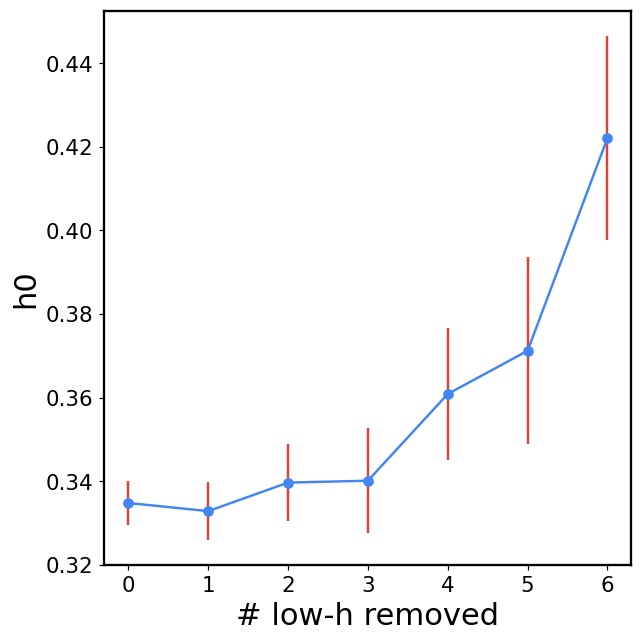

Regenerated Figure 1 (Plot 16): sensitivity regularized h0


C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\4071865493.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\4071865493.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)


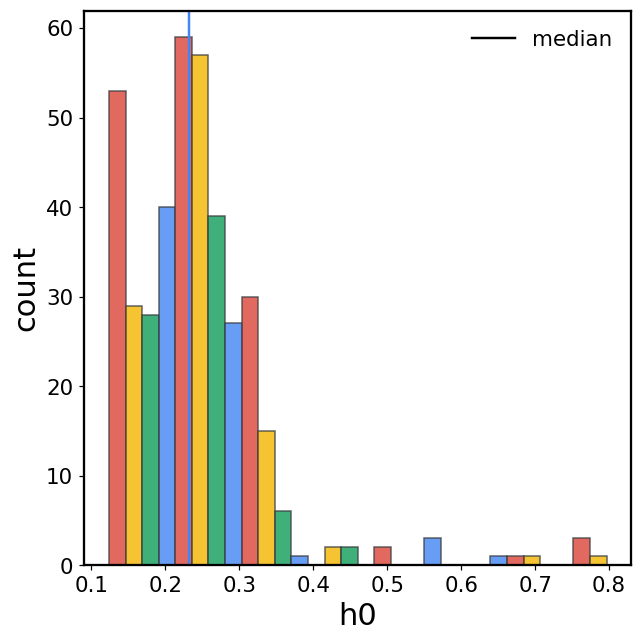

Regenerated Figure 3: bootstrap histogram h0 (model=gen_power, n=400)


C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\4071865493.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
C:\Users\mrast\AppData\Local\Temp\ipykernel_32248\4071865493.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)


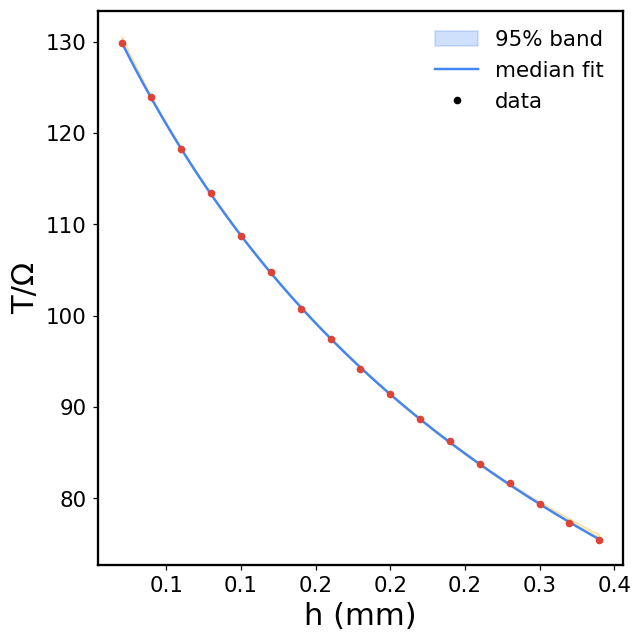

Regenerated Figure 4: bootstrap predictive 95% band (model=gen_power)


In [32]:
# --- Regenerate only requested added figures: #1 and #3 ---
import numpy as np
import matplotlib.pyplot as plt

# Figure 1: Plot 16 (sensitivity of h0 for regularized model)
if "sens_tables" not in globals():
    raise RuntimeError("sens_tables not found. Run the sensitivity-analysis section first.")

if "regularized" not in sens_tables or "h0" not in sens_tables["regularized"].columns:
    raise RuntimeError("Cannot regenerate Plot 16: sens_tables['regularized']['h0'] is unavailable.")

tbl16 = sens_tables["regularized"]
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(tbl16["removed"], tbl16["h0"], yerr=tbl16["h0_se"], fmt="o-")
ax.set_xlabel("# low-h removed", fontsize=20)
ax.set_ylabel("h0", fontsize=20)
ax.set_xticklabels([f"{x:.0f}" for x in ax.get_xticks()], fontsize=14)
ax.set_yticklabels([f"{y:.2f}" for y in ax.get_yticks()], fontsize=14)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
plt.tight_layout()
save_fig(fig, "08_sensitivity_regularized_h0")
plt.show()
print("Regenerated Figure 1 (Plot 16): sensitivity regularized h0")

# Figure 3: Bootstrap distribution for h0 only
if "bootstrap_fit" not in globals() or "parameter_confidence_intervals" not in globals():
    raise RuntimeError("Bootstrap helpers not found. Run the uncertainty section first.")

h0_models = [name for name in MODELS if "h0" in MODELS[name]["pnames"]]
if not h0_models:
    raise RuntimeError("No model with 'h0' exists in MODELS.")

boot_model = best_aic if ("best_aic" in globals() and best_aic in h0_models) else h0_models[0]
boot_h0 = bootstrap_fit(boot_model, h_f, y_f, n_boot=400, random_state=0)
if boot_h0.empty or "h0" not in boot_h0.columns:
    raise RuntimeError("Bootstrap for an h0-containing model failed or missing h0 column.")

ci_h0 = parameter_confidence_intervals(boot_h0)
fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(boot_h0["h0"], bins=30, color="C0", alpha=0.8, edgecolor="k")
ax.axvline(ci_h0.loc["h0", "median"], color="k", label="median")
ax.set_xlabel("h0", fontsize=20)
ax.set_ylabel("count", fontsize=20)
ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.legend(fontsize=14, frameon=False, loc="upper right")
plt.tight_layout()
save_fig(fig, "09_bootstrap_hist_h0")
plt.show()
print(f"Regenerated Figure 3: bootstrap histogram h0 (model={boot_model}, n={len(boot_h0)})")

# Figure 4: Bootstrap predictive 95% confidence band (median + data overlay)
hh = np.linspace(h_f.min(), h_f.max(), 300)
preds = np.array([MODELS[boot_model]["func"](hh, *row) for row in boot_h0.values])
band_lo, band_hi = np.percentile(preds, [2.5, 97.5], axis=0)
median_pred = np.percentile(preds, 50, axis=0)

fig, ax = plt.subplots(figsize=(6, 6))
ax.fill_between(hh, band_lo, band_hi, alpha=0.25, color="C0", label="95% band")
ax.plot(hh, median_pred, "C0", label="median fit")
ax.plot(h_f, y_f, "ko", ms=4, label="data")
ax.set_xlabel("h (mm)", fontsize=20)
ax.set_ylabel("T/Ω", fontsize=20)
ax.set_xticklabels([f"{x:.1f}" for x in ax.get_xticks()], fontsize=14)
ax.set_yticklabels([f"{y:.0f}" for y in ax.get_yticks()], fontsize=14)
ax.grid(False)
ax.legend(fontsize=14, frameon=False, loc="upper right")
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
plt.tight_layout()
save_fig(fig, "09_bootstrap_band")
plt.show()
print(f"Regenerated Figure 4: bootstrap predictive 95% band (model={boot_model})")
